##Objective:

###To introduce the Time series analysis and Forecasting for improvement in logistic operations and introducing time and date factors for predicting shipments within a day with several dates.

In [ ]:
import pandas as pd
import numpy as np
import scipy as sc
import math
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import sklearn as skl
import tensorflow as tf
from tensorflow.keras import models, layers

In [ ]:
sent= pd.read_csv("/content/sentiment_complete.csv")

In [ ]:
ts = pd.read_csv("/content/DIC-Outward MIS Report A+B+C (2024 TO 2025) New -   18_03_2025.csv")

In [ ]:
ts1= pd.read_csv("/content/DIC-Outward MIS Report A+B+C (2024 TO 2025) New - 19_03_2025.csv")

In [ ]:
ts= pd.concat([ts, ts1])

In [ ]:
sent.head()

,OrderID,Date_x,Country_x,City_x,Latitude_x,Longtitude_x,ProductCategoryName_x,ProductID_x,Product_x,Quantity_x,...,year,Month,Day,Year_Month,Location_ID,Sentiment,Class,Product_detail_y,Revenue_y,Price
0,order-00e5d11e-2c62-4f24-8a36-b5a9a7f89181,NaT,3,0,0.0000,0.0000,4,0,12,NaN,...,NaN,NaN,NaN,NaT,NaN,86.0,3,NaN,NaN,NaN
1,order-0124ec8d-2fa3-432e-802c-15cf09e66f2f,NaT,3,5,NaN,NaN,4,0,12,NaN,...,2021.0,1.0,Mon,2021-01-01,"United States, San Diego",40.0,0,Stilettos (product-7bef3e02-033c-4259-93da-a25...,203.68,NaN
2,order-02d3f33b-cf80-4c77-97dc-9c0997d93958,NaT,3,5,NaN,NaN,4,0,12,NaN,...,2021.0,1.0,Mon,2021-01-01,"Portugal, Lisbon",86.0,2,Brogues (product-124ef52a-c7c3-48af-b315-33a14...,370.50,NaN
3,order-0320c249-8c62-4018-b23b-31e2a46858c4,2020-01-22,2,4,40.6943,-73.9249,0,3,2,7.0,...,NaN,NaN,NaN,NaT,NaN,86.0,3,NaN,NaN,NaN
4,order-03b78162-aa02-40aa-bb5d-8978e7e57f5e,NaT,3,5,NaN,NaN,4,0,12,NaN,...,2021.0,1.0,Sat,2021-01-01,"Portugal, Lisbon",87.0,2,Flats (product-f709c12a-ffe5-48b1-a3d2-f247acf...,254.21,NaN


In [ ]:
ts.head()

,S.R NO.,Lane,DISPATCHED FROM,SHIFT,GATE PASS NO.,GATE IN DATE,GATE IN TIME,DOCK IN DATE,DOCK IN TIME,DOCK OUT DATE,...,Description,SIZE,KILO METER,Adhoc/Regular,DRIVER NAME,Contact No.,Seal No.,Prealert Status,VEHICLE LOAD BY,Report Created By
0,1,LOCAL,DEL/DIC-DEL/SRF-DEL/NDP-Phase3NoidaHub_DEL_PL-...,A,8813527.0,18-Mar-2025,8:20,18-Mar-2025,8:35,18-Mar-2025,...,DIC,22 FT,93056,REGULAR,PUNIT,8.920699e+09,WE 15006107/15006101,DONE,ANUJ,SAURABH SAINI
1,2,LOCAL,DEL/DIC-DEL/SRF-DEL/NDP-Phase3NoidaHub_DEL_PL-...,A,8813527.0,18-Mar-2025,8:20,18-Mar-2025,8:35,18-Mar-2025,...,DIC,22 FT,93056,REGULAR,PUNIT,8.920699e+09,WE 15006107/15006101,DONE,ANUJ,SAURABH SAINI
2,3,LOCAL,DEL/DIC-DEL/SRF-DEL/NDP-Phase3NoidaHub_DEL_PL-...,A,8813527.0,18-Mar-2025,8:20,18-Mar-2025,8:35,18-Mar-2025,...,DIC,22 FT,93056,REGULAR,PUNIT,8.920699e+09,WE 15006107/15006101,DONE,ANUJ,SAURABH SAINI
3,4,LOCAL,DEL/DIC-DEL/SRF-DEL/NDP-Phase3NoidaHub_DEL_PL-...,A,8813527.0,18-Mar-2025,8:20,18-Mar-2025,8:35,18-Mar-2025,...,DIC,22 FT,93056,REGULAR,PUNIT,8.920699e+09,WE 15006107/15006101,DONE,ANUJ,SAURABH SAINI
4,5,LOCAL,DEL/DIC-DEL/SRF-DEL/NDP-Phase3NoidaHub_DEL_PL-...,A,8813527.0,18-Mar-2025,8:20,18-Mar-2025,8:35,18-Mar-2025,...,DIC,22 FT,93056,REGULAR,PUNIT,8.920699e+09,WE 15006107/15006101,DONE,ANUJ,SAURABH SAINI


In [ ]:
ts.columns

Index(['S.R  NO.', 'Lane', 'DISPATCHED FROM', 'SHIFT', 'GATE PASS NO.',
       'GATE IN DATE', 'GATE IN TIME', 'DOCK IN DATE', 'DOCK IN TIME',
       'DOCK OUT DATE', 'DOCK OUT TIME', 'GATE OUT DATE', 'GATE OUT TIME',
       'CUT OFF TIME', 'COC', 'CM', 'Bag Qty\n(As Per ERP)',
       'Large Shipment \nBag(QTY)', 'IT & STOCK & EKL BAG', 'TOTAL BAGS',
       'SHIPMENT', 'WT.', 'Trip ID', 'SPILL OVER BAG DETAIL', 'Vendor Name',
       'Vehicle No', 'DOCK NO', 'Description', 'SIZE', 'KILO METER',
       'Adhoc/Regular', 'DRIVER NAME', 'Contact No.', 'Seal No.',
       'Prealert Status', 'VEHICLE LOAD BY', 'Report Created By'],
      dtype='object')

In [ ]:
ts_ = ts.sort_values(by=["CUT OFF TIME","DOCK IN TIME"],ascending= True).reset_index(drop=True)

In [ ]:
ts_["CUT OFF TIME"].head()

,CUT OFF TIME
0,10:00
1,10:00
2,10:00
3,10:00
4,10:00


In [ ]:
import plotly.express as px
# Create a line chart
fig = px.line(ts, y="CUT OFF TIME", x="KILO METER", title='CUT OFF TIME vs KILO METER')
# Display the chart
fig.show()

In [ ]:
import plotly.express as px
# Create a line chart
fig = px.line(ts, y="DOCK IN TIME", x="SIZE", title='DOCK IN TIME vs SIZE')
# Display the chart
fig.show()

In [ ]:
import plotly.express as px
# Create a line chart
fig = px.line(ts, y="DOCK IN TIME", x="SIZE", title='Bag Qty\n(As Per ERP)')
# Display the chart
fig.show()

In [ ]:
import plotly.express as px
# Create a line chart
fig = px.line(ts_, x="DOCK IN TIME", y="TOTAL BAGS", title='DOCK IN TIME vs SIZE')
# Display the chart
fig.show()

In [ ]:

#changing the format of time into proper format
ts_["CUT_OFF_TIME"]= pd.to_datetime(ts_["CUT OFF TIME"], format='mixed').dt.time

In [ ]:


# Removed problematic independent sorting of CUT_OFF_TIME column
# ts_["CUT_OFF_TIME"]= ts_["CUT_OFF_TIME"].sort_values(ascending= True)

In [ ]:
#Replacing special character
ts["CUT OFF TIME_"]= ts["CUT OFF TIME"].str.replace(";",":")

In [ ]:
import plotly.express as px
# Create a line chart
fig = px.line(ts_, x="CUT_OFF_TIME", y="SHIPMENT", title='CUT OFF TIME vs SHIPMENT')
# Display the chart
fig.show()


As we see that data is non-stationary, to move ahead with calculations and analysis process and further modeling process, one need to convert it into stationary form.

In [ ]:
#Starting with first order differencing
ts_["Diff1"]= ts_["SHIPMENT"].diff()

In [ ]:
ts_[["SHIPMENT","Diff1"]]

,SHIPMENT,Diff1
0,653.0,NaN
1,53.0,-600.0
2,39.0,-14.0
3,554.0,515.0
4,120.0,-434.0
...,...,...
1992,NaN,NaN
1993,NaN,NaN
1994,NaN,NaN
1995,NaN,NaN


In [ ]:
ts_["SHIPMENT"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1997 entries, 0 to 1996
Series name: SHIPMENT
Non-Null Count  Dtype  
--------------  -----  
1949 non-null   float64
dtypes: float64(1)
memory usage: 15.7 KB


In [ ]:
#b= ts_["Diff1"].interpolate()
b=ts_["Diff1"].interpolate(method="linear")
b

,Diff1
0,NaN
1,-600.0
2,-14.0
3,515.0
4,-434.0
...,...
1992,3731.0
1993,3731.0
1994,3731.0
1995,3731.0


In [ ]:
ts_["Diff1"].fillna(0)

,Diff1
0,0.0
1,-600.0
2,-14.0
3,515.0
4,-434.0
...,...
1992,0.0
1993,0.0
1994,0.0
1995,0.0


In [ ]:
ts_[["SHIPMENT","Diff1"]]

,SHIPMENT,Diff1
0,653.0,NaN
1,53.0,-600.0
2,39.0,-14.0
3,554.0,515.0
4,120.0,-434.0
...,...,...
1992,NaN,NaN
1993,NaN,NaN
1994,NaN,NaN
1995,NaN,NaN


In [ ]:
#Performing Second order Differencing
ts_["Diff2"]= ts_["Diff1"].diff()

In [ ]:
#Second order Differencing
ts_["Diff2"].fillna(0)

,Diff2
0,0.0
1,0.0
2,586.0
3,529.0
4,-949.0
...,...
1992,0.0
1993,0.0
1994,0.0
1995,0.0


In [ ]:
import plotly.express as px
import plotly.express as px
# Create a line chart
fig = px.line(ts_, x="CUT_OFF_TIME", y="Diff1", title='CUT OFF TIME vs SHIPMENT')
# Display the chart
fig.show()

In [ ]:
import plotly.express as px
import plotly.express as px
# Create a line chart
fig = px.line(ts_, x="CUT_OFF_TIME", y="Diff2", title='CUT OFF TIME vs SHIPMENT')
# Display the chart
fig.show()

SECOND METHOD: Log order differencing to make data stationary

In [ ]:
#Implementing log differencing to make dataset stationary
ts["log"]=np.log(ts_["Diff1"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log



In [ ]:
#importing packages
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

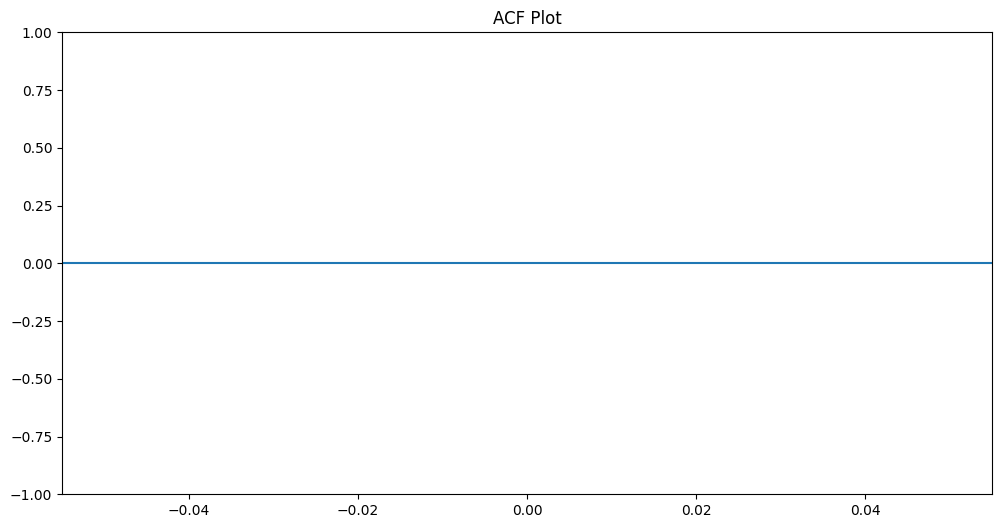

In [ ]:
# ACF and PACF plots for determining ARIMA orders
plt.figure(figsize=(12, 6))
plot_acf(ts_['SHIPMENT'], lags=5, ax=plt.gca())
plt.title('ACF Plot')
plt.show()

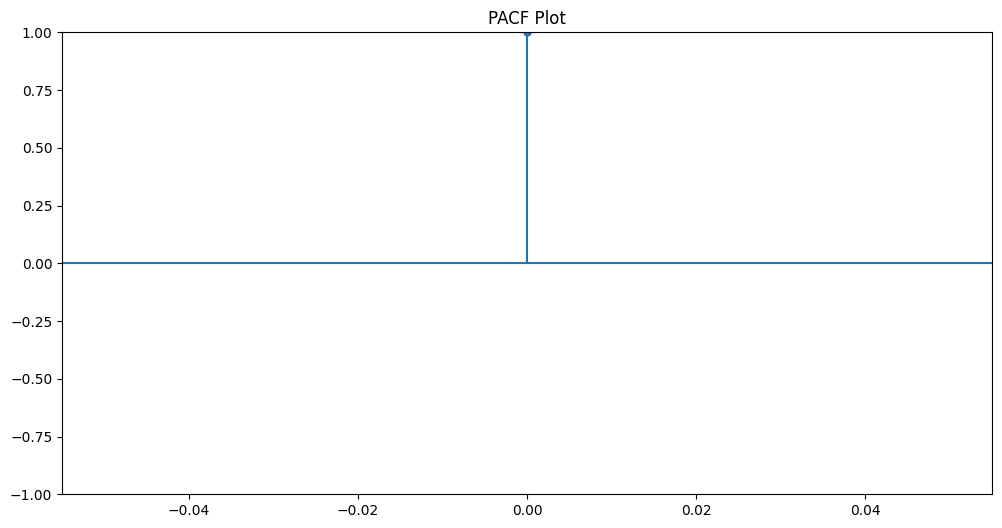

In [ ]:
plt.figure(figsize=(12, 6))
plot_pacf(ts_['Diff2'], lags=5, ax=plt.gca())
plt.title('PACF Plot')
plt.show()

In [ ]:
#Importing other packages
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

In [ ]:
ts_["SHIPMENT"].fillna(0).astype("int")

,SHIPMENT
0,653
1,53
2,39
3,554
4,120
...,...
1992,0
1993,0
1994,0
1995,0


As ETS doesn't consist 0 or negative values, so one need to use imputation techniques based on the variation in the dataset.

Here, I'm using AutoEncoder to fill missing values and other non-linear methods to fill the missing values present in the dataset.

In [ ]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1997 entries, 0 to 1042
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   S.R  NO.                  1997 non-null   int64  
 1   Lane                      1951 non-null   object 
 2   DISPATCHED FROM           1950 non-null   object 
 3   SHIFT                     1950 non-null   object 
 4   GATE PASS NO.             1950 non-null   object 
 5   GATE IN DATE              1950 non-null   object 
 6   GATE IN TIME              1950 non-null   object 
 7   DOCK IN DATE              1950 non-null   object 
 8   DOCK IN TIME              1950 non-null   object 
 9   DOCK OUT DATE             1950 non-null   object 
 10  DOCK OUT TIME             1950 non-null   object 
 11  GATE OUT DATE             1950 non-null   object 
 12  GATE OUT TIME             1950 non-null   object 
 13  CUT OFF TIME              1918 non-null   object 
 14  COC          

In [ ]:
# Linear Regression imputation
from sklearn.linear_model import LinearRegression
import numpy as np
df_imputed = ts_.copy()

target_column = 'SHIPMENT'
predictor_column = 'TOTAL BAGS' # Using 'TOTAL BAGS' as a predictor for 'SHIPMENT'

# Ensure predictor column has no missing values for training/prediction in this simplified approach
# If 'TOTAL BAGS' has NaNs, a more complex imputation (e.g., iterative imputer) would be needed,
# or impute 'TOTAL BAGS' first. For now, we'll drop rows where the predictor is missing.
df_imputed = df_imputed.dropna(subset=[predictor_column])

# Separate the dataset into two parts:
# 1. `known_data`: rows where the target column ('SHIPMENT') is NOT null. This will be used for training.
# 2. `missing_data`: rows where the target column ('SHIPMENT') IS null. This is where we need to predict.
known_data = df_imputed[df_imputed[target_column].notna()]
missing_data = df_imputed[df_imputed[target_column].isna()]

# Proceed with imputation only if there are missing values to predict
if not missing_data.empty:
    # Prepare the training data
    # X_train should be a 2D array (features), y_train a 1D array (target)
    X_train = known_data[[predictor_column]]
    y_train = known_data[target_column]

    # Initialize and train the Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Prepare the data for prediction
    # X_predict should be a 2D array of features corresponding to the missing target values
    X_predict = missing_data[[predictor_column]]

    # Predict the missing 'SHIPMENT' values
    predicted_values = model.predict(X_predict)

    # Fill the missing 'SHIPMENT' values in the DataFrame copy
    df_imputed.loc[df_imputed[target_column].isna(), target_column] = predicted_values

    print("Dataset After Linear Regression Imputation on 'SHIPMENT' using 'TOTAL BAGS':")
    print(df_imputed[[target_column, predictor_column]].head())
    print("\nNumber of missing values in 'SHIPMENT' after imputation:", df_imputed['SHIPMENT'].isnull().sum())
else:
    print("No missing values found in 'SHIPMENT' after filtering for the predictor column. No imputation performed.")

# Update the original ts_ DataFrame with the imputed data
ts_ = df_imputed

Dataset After Linear Regression Imputation on 'SHIPMENT' using 'TOTAL BAGS':
   SHIPMENT  TOTAL BAGS
0     653.0        28.0
1      53.0         4.0
2      39.0        39.0
3     554.0        21.0
4     120.0         5.0

Number of missing values in 'SHIPMENT' after imputation: 0


##Imputation using AutoEncoders

In [ ]:
#Here we don't hae missing values,
#hence no need to perform non-linear encoding techniiques

### Applying ETS for Decomposition

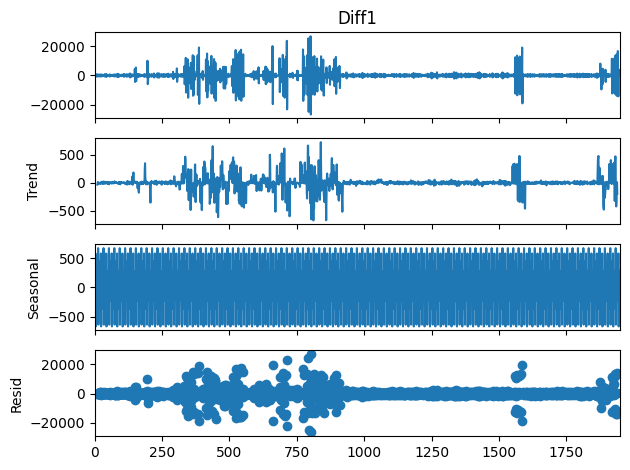

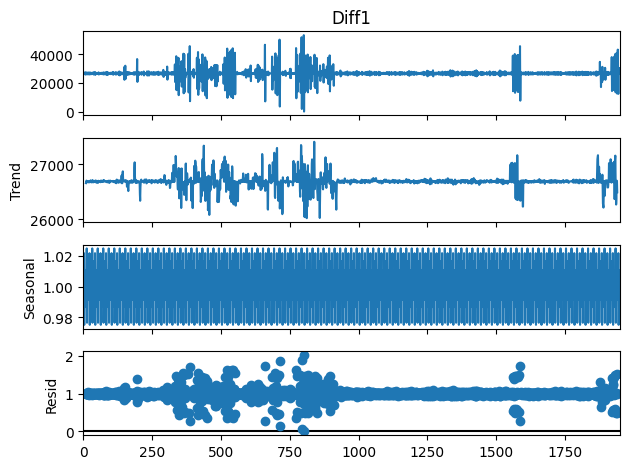

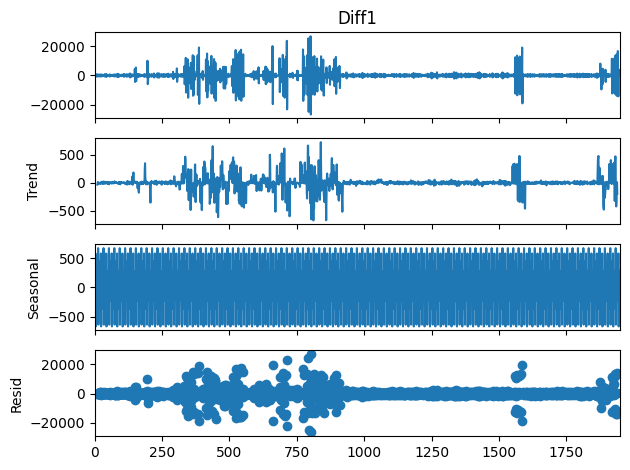

In [ ]:
#Decomposition of dataset into Error, Trend and Seasonality
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Fill NaN values in 'Diff1' before decomposition
diff1_series = ts_['Diff1'].fillna(0)

#As we are dealing with property of multiplicity due to presence of zero and negative values.
# Transforming those values by shifting with a constant number, say 1.
diff1_series_ = diff1_series + abs(diff1_series.min()) + 1

# ETS Decomposition
result = seasonal_decompose(diff1_series_, model ='multiplicative',period=20)
result_ = seasonal_decompose(diff1_series, model ='additive',period= 20)


# ETS plot
result.plot()
result_.plot()

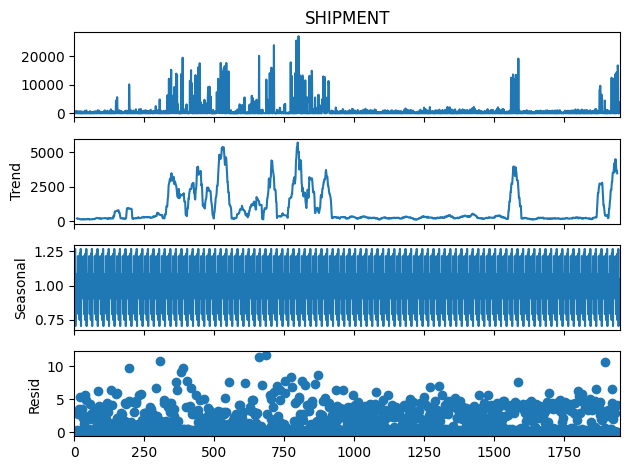

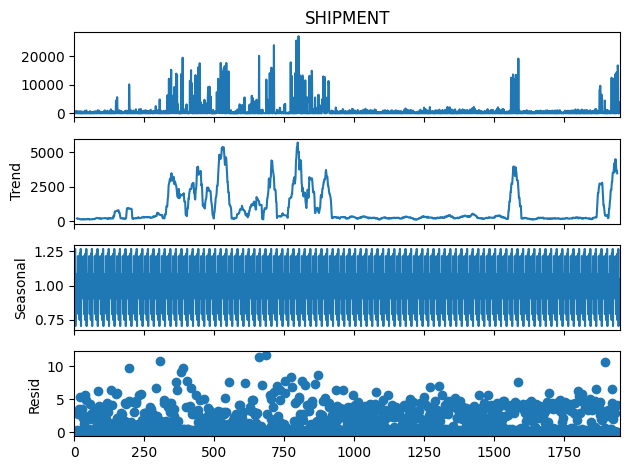

In [ ]:
# ETS Decomposition on SHIPMENT attribute when model is multiplicative
result1 = seasonal_decompose(ts_["SHIPMENT"], model ='multiplicative',period=20)

# ETS plot
result1.plot()
##result_.plot()

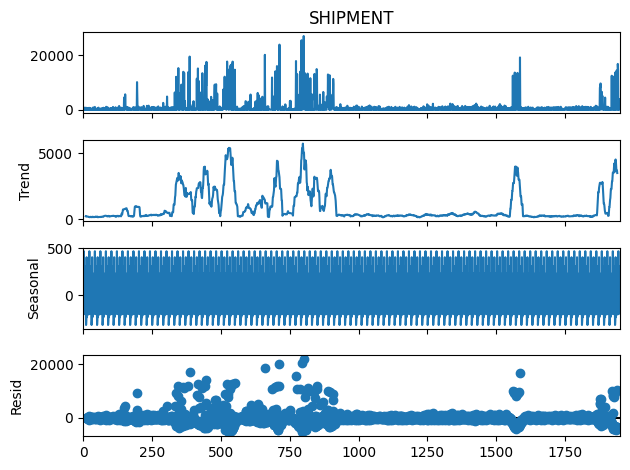

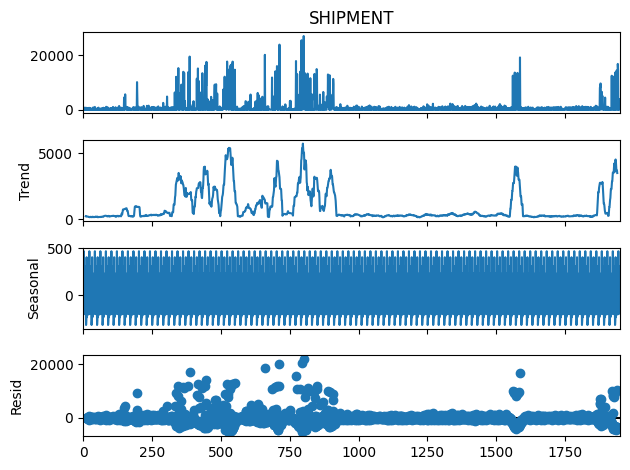

In [ ]:
result2 = seasonal_decompose(ts_["SHIPMENT"], model ='additive',period= 20)
result2.plot()

##MODEL IMPLEMENTATION

In [ ]:
pip install utilsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.4 MB/s eta 0:00:00


In [ ]:
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [ ]:
!pip install statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7aec147a7380>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/scipy.libs/libscipy_openblas-b75cc656.

In [ ]:
ts_.columns

Index(['S.R  NO.', 'Lane', 'DISPATCHED FROM', 'SHIFT', 'GATE PASS NO.',
       'GATE IN DATE', 'GATE IN TIME', 'DOCK IN DATE', 'DOCK IN TIME',
       'DOCK OUT DATE', 'DOCK OUT TIME', 'GATE OUT DATE', 'GATE OUT TIME',
       'CUT OFF TIME', 'COC', 'CM', 'Bag Qty\n(As Per ERP)',
       'Large Shipment \nBag(QTY)', 'IT & STOCK & EKL BAG', 'TOTAL BAGS',
       'SHIPMENT', 'WT.', 'Trip ID', 'SPILL OVER BAG DETAIL', 'Vendor Name',
       'Vehicle No', 'DOCK NO', 'Description', 'SIZE', 'KILO METER',
       'Adhoc/Regular', 'DRIVER NAME', 'Contact No.', 'Seal No.',
       'Prealert Status', 'VEHICLE LOAD BY', 'Report Created By',
       'CUT_OFF_TIME', 'Diff1', 'Diff2'],
      dtype='object')

In [ ]:
minute= 30

models=[
Naive(),
HistoricAverage(),
WindowAverage(window_size=30),
SeasonalNaive(season_length=30)]
# Removed freq="min" as timestamps are not consistently minute-frequency
stats= StatsForecast(models=models, freq=None)

In [ ]:
ts_.columns

Index(['S.R  NO.', 'Lane', 'DISPATCHED FROM', 'SHIFT', 'GATE PASS NO.',
       'GATE IN DATE', 'GATE IN TIME', 'DOCK IN DATE', 'DOCK IN TIME',
       'DOCK OUT DATE', 'DOCK OUT TIME', 'GATE OUT DATE', 'GATE OUT TIME',
       'CUT OFF TIME', 'COC', 'CM', 'Bag Qty\n(As Per ERP)',
       'Large Shipment \nBag(QTY)', 'IT & STOCK & EKL BAG', 'TOTAL BAGS',
       'SHIPMENT', 'WT.', 'Trip ID', 'SPILL OVER BAG DETAIL', 'Vendor Name',
       'Vehicle No', 'DOCK NO', 'Description', 'SIZE', 'KILO METER',
       'Adhoc/Regular', 'DRIVER NAME', 'Contact No.', 'Seal No.',
       'Prealert Status', 'VEHICLE LOAD BY', 'Report Created By',
       'CUT_OFF_TIME', 'Diff1', 'Diff2'],
      dtype='object')

In [ ]:
!pip install datetime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 6.6 MB/s eta 0:00:00


In [ ]:
!pip install timedelta

  Preparing metadata (setup.py) ... done
  Created wheel for timedelta: filename=timedelta-2020.12.3-py3-none-any.whl size=1555 sha256=6194445ed311586f0156232705f7bb7cf734eea4ca6de5b12ba63f4129f194fe
  Stored in directory: /root/.cache/pip/wheels/8d/fb/00/1ed61af72177d4c71909dc4ad90d4ce863e0aaed78e31206e0
Successfully built timedelta


In [ ]:
from datetime import datetime
import timedelta as td
import datetime as dt
ts_["ds"]= pd.to_datetime(ts_['CUT OFF TIME'], format="%H:%M:%S", errors="coerce").dt.strftime('%H:%M:%S')

In [ ]:
TS= ts_[["GATE IN DATE","CUT OFF TIME", "SHIPMENT", "CUT_OFF_TIME", 'Diff1', 'Diff2','ds']]

In [ ]:
TS.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1950 entries, 0 to 1949
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GATE IN DATE  1950 non-null   object 
 1   CUT OFF TIME  1918 non-null   object 
 2   SHIPMENT      1950 non-null   float64
 3   CUT_OFF_TIME  1918 non-null   object 
 4   Diff1         1947 non-null   float64
 5   Diff2         1945 non-null   float64
 6   ds            1260 non-null   object 
dtypes: float64(3), object(4)
memory usage: 121.9+ KB


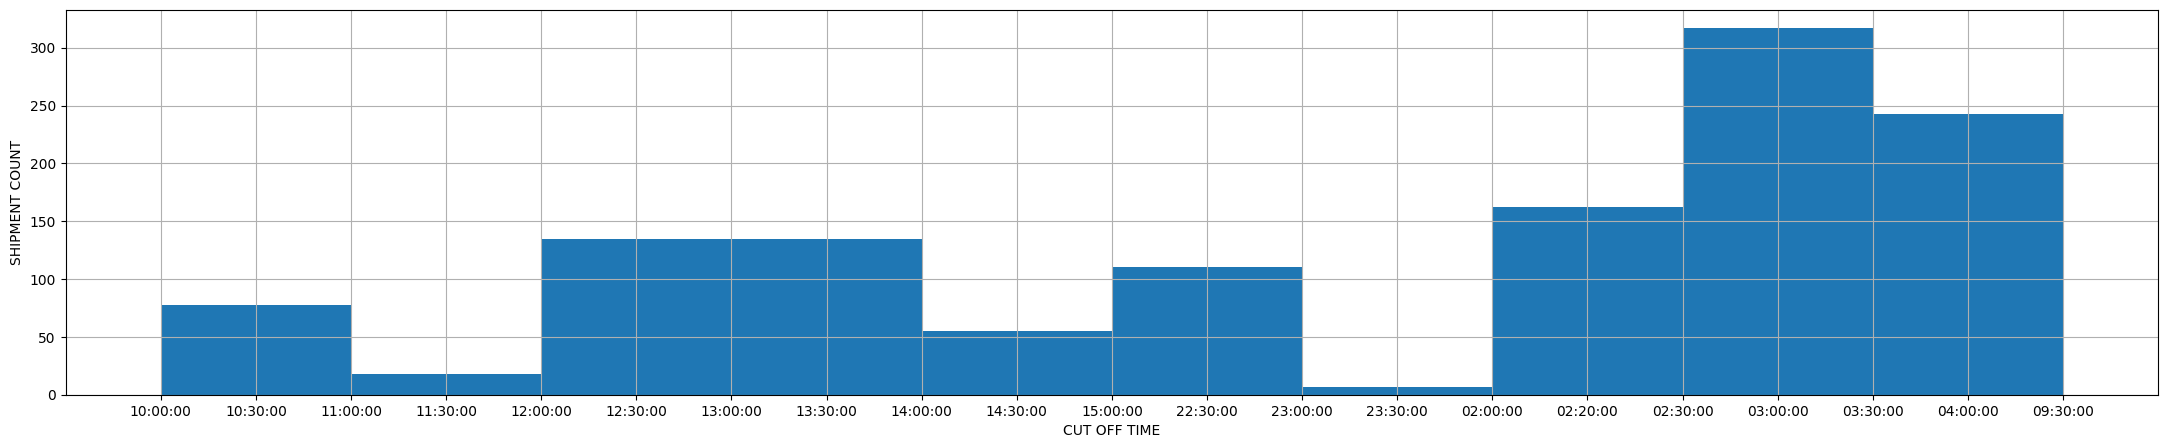

In [ ]:
fig,ax= plt.subplots(figsize=(27,5))
TS.ds.hist()
plt.xlabel("CUT OFF TIME")
plt.ylabel("SHIPMENT COUNT")
plt.show()

In [ ]:
# Ensure 'GATE IN DATE' is in datetime format
TS['GATE IN DATE'] = pd.to_datetime(TS['GATE IN DATE'], format='%d-%b-%Y', errors='coerce')

# Combine 'GATE IN DATE' with 'CUT_OFF_TIME' to create a proper datetime 'ds' column
# ts_['CUT_OFF_TIME'] is already a datetime.time object
TS['ds'] = TS.apply(lambda row: row['GATE IN DATE'].replace(
    hour=row['CUT_OFF_TIME'].hour,
    minute=row['CUT_OFF_TIME'].minute,
    second=row['CUT_OFF_TIME'].second
) if pd.notna(row['GATE IN DATE']) and pd.notna(row['CUT_OFF_TIME']) else pd.NaT, axis=1)

# Rename 'SHIPMENT' to 'y' for StatsForecast
TS['y'] = TS['SHIPMENT']

# Add a 'unique_id' column for StatsForecast as it expects this for panel data,
# even if it's a single series.
TS['unique_id'] = 'series_1'

# Drop rows where 'ds' or 'y' are NaN before aggregation and model fitting
TS = TS.dropna(subset=['ds', 'y'])

# Aggregate duplicate timestamps if they exist (multiple 'y' for same 'ds')
if TS[['unique_id', 'ds']].duplicated().any():
    print("Warning: Duplicate 'ds' values found for 'unique_id'. Aggregating 'y' by 'ds' (sum).")
    TS = TS.groupby(['unique_id', 'ds'], as_index=False)['y'].sum()
    # Re-assign 'unique_id' as groupby might change it if as_index was False, or for clarity.
    TS['unique_id'] = 'series_1'

# Sort by the new datetime index
TS = TS.sort_values(by='ds').reset_index(drop=True)

# Select only the required columns for StatsForecast: 'unique_id', 'ds', and 'y'
TS_final = TS[['unique_id', 'ds', 'y']]

# Fit the StatsForecast model
stats.fit(TS_final, id_col='unique_id', time_col='ds', target_col='y')

/tmp/ipykernel_5587/1810151404.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_5587/1810151404.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_5587/1810151404.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_558

StatsForecast(models=[Naive,HistoricAverage,WindowAverage,SeasonalNaive])

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA

models=[
Naive(),
HistoricAverage(),
WindowAverage(window_size=12),
SeasonalNaive(season_length=10),
AutoARIMA(seasonal= False, alias="ARIMA_no_Season"),
#AutoARIMA(season_length= 12, alias="ARIMA_Season")
]
stats = StatsForecast(models=models, freq='30min')

# Re-fitting the model with the correct frequency.
stats.fit(TS_final, id_col='unique_id', time_col='ds', target_col='y')

# predicting for the specified number of steps (minute)
future = stats.predict(h=minute)
future.columns

Index(['unique_id', 'ds', 'Naive', 'HistoricAverage', 'WindowAverage',
       'SeasonalNaive', 'ARIMA_no_Season'],
      dtype='object')

In [ ]:
future.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive,ARIMA_no_Season
0,series_1,2025-03-19 23:30:00,16070.0,42240.264327,52917.75,3179.0,28248.988627
1,series_1,2025-03-20 00:00:00,16070.0,42240.264327,52917.75,95103.0,41608.098134
2,series_1,2025-03-20 00:30:00,16070.0,42240.264327,52917.75,66168.0,41608.098134
3,series_1,2025-03-20 01:00:00,16070.0,42240.264327,52917.75,131850.0,41608.098134
4,series_1,2025-03-20 01:30:00,16070.0,42240.264327,52917.75,99417.0,41608.098134


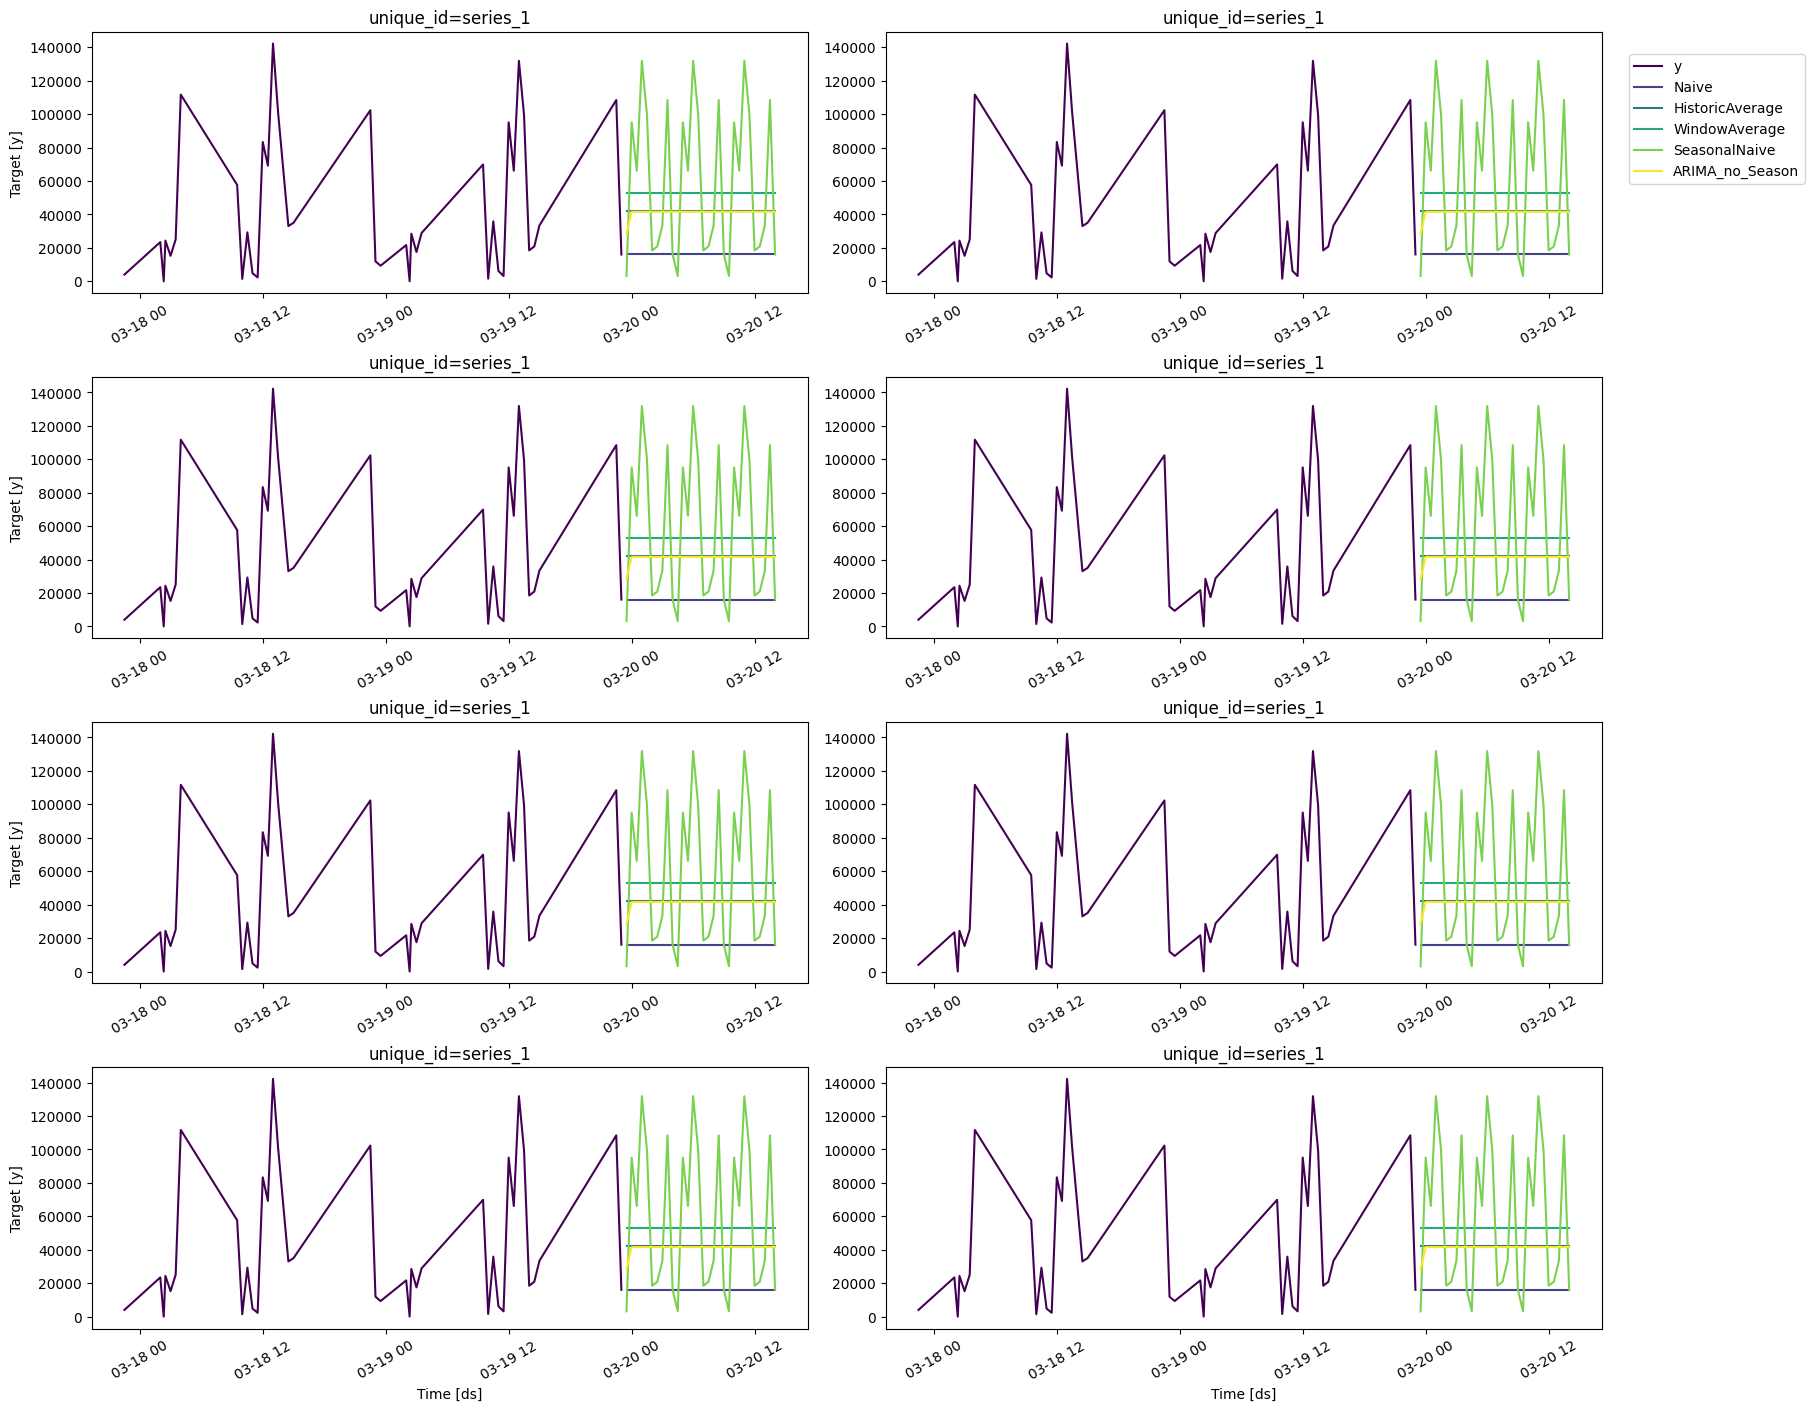

In [ ]:
plot_series(
    df=TS,
    forecasts_df= future,
    ids= TS["unique_id"],
    palette="viridis"

)

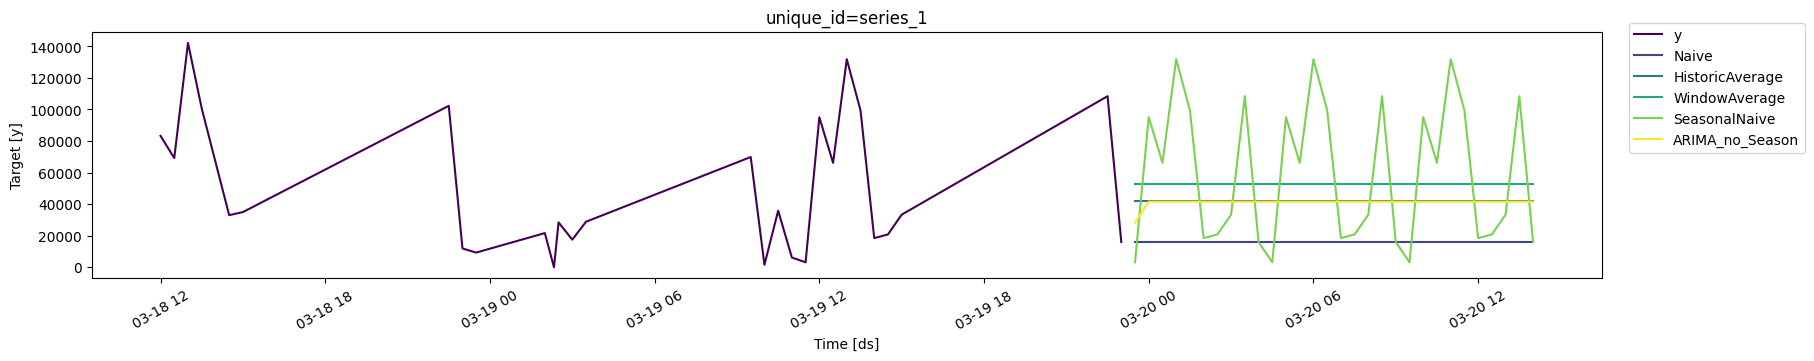

In [ ]:
#Broader view of above prediction
plot_series(
    df= TS,
    forecasts_df=future,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
TS.columns

Index(['unique_id', 'ds', 'y'], dtype='object')

##Forecast using ARIMA and its family

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA

models_arima=[
AutoARIMA(seasonal= False, alias="ARIMA_no_Season"),
AutoARIMA(season_length=24, alias="ARIMA_Season")
]
stats_arima = StatsForecast(models=models_arima, freq='30min')

# Re-fitting the model with the correct frequency.
stats_arima.fit(TS_final, id_col='unique_id', time_col='ds', target_col='y')

# predicting for the specified number of steps (minute)
future_arima = stats_arima.predict(h=minute)
future_arima.columns

Index(['unique_id', 'ds', 'ARIMA_no_Season', 'ARIMA_Season'], dtype='object')

In [ ]:
future_arima.head()

,unique_id,ds,ARIMA_no_Season,ARIMA_Season
0,series_1,2025-03-19 23:30:00,28248.988627,28248.988627
1,series_1,2025-03-20 00:00:00,41608.098134,41608.098134
2,series_1,2025-03-20 00:30:00,41608.098134,41608.098134
3,series_1,2025-03-20 01:00:00,41608.098134,41608.098134
4,series_1,2025-03-20 01:30:00,41608.098134,41608.098134


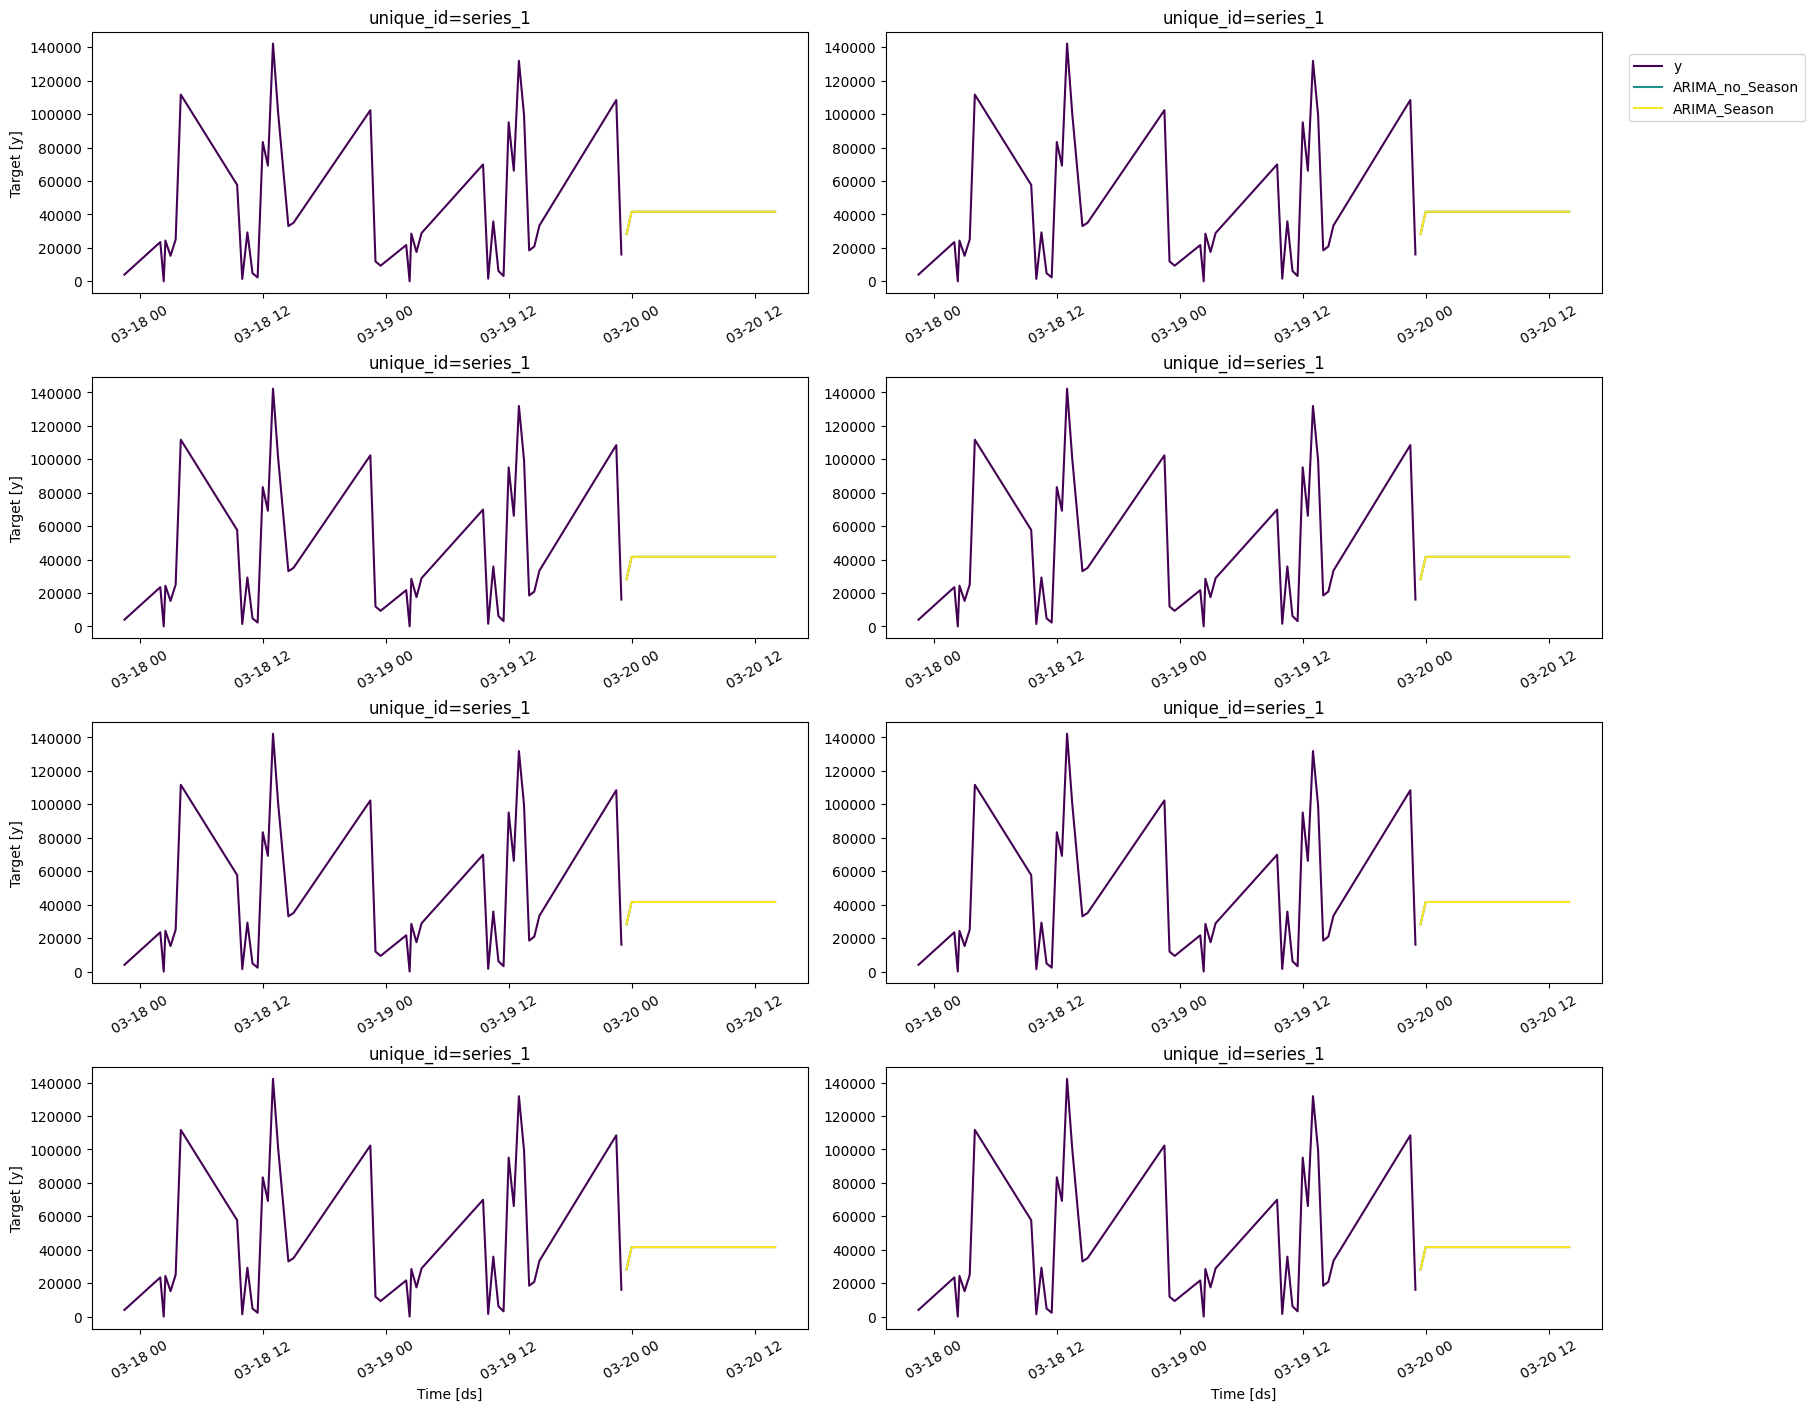

In [ ]:
TS["ds"]= pd.to_datetime(TS["ds"],errors="coerce")
plot_series(
    df=TS,
    forecasts_df= future_arima,
    ids= TS["unique_id"],
    palette="viridis"

)

##With multiple models of time series

In [ ]:
##Model 2 wth more specified models
from statsforecast import StatsForecast
from statsforecast.models import (
    HoltWinters,
    CrostonClassic as Croston,
    HistoricAverage,
    DynamicOptimizedTheta as DOT,
    SeasonalNaive
)

In [ ]:
# Create a list of models and instantiation parameters
models1 = [
    HoltWinters(),
    Croston(),
    SeasonalNaive(season_length=30),
    HistoricAverage(),
    DOT(season_length=12)
]

In [ ]:
# Instantiate StatsForecast class as sf
stat = StatsForecast(
    models=models1,
    freq="30min",
    fallback_model = SeasonalNaive(season_length=30),
    n_jobs=-1,
)

In [ ]:
!pip install statsmodels

In [ ]:
#!pip install SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsforecast.models import (
    HoltWinters,
    CrostonClassic as Croston,
    HistoricAverage,
    DynamicOptimizedTheta as DOT,
    SeasonalNaive,
    AutoARIMA,
)

models_for_stats1 = [
    HoltWinters(season_length=12), # Assuming daily seasonality with 2h frequency
    Croston(),
    SeasonalNaive(season_length=12),
    HistoricAverage(),
    DOT(season_length=12),
    AutoARIMA(season_length= 6),

]

stats1= StatsForecast(models=models_for_stats1, freq="2h")
stats1.fit(TS, id_col='unique_id', time_col='ds', target_col='y')

# predict for the specified number of steps (minute), including prediction intervals
future1 = stats1.predict(h=minute)
future1.columns

Index(['unique_id', 'ds', 'HoltWinters', 'CrostonClassic', 'SeasonalNaive',
       'HistoricAverage', 'DynamicOptimizedTheta', 'AutoARIMA'],
      dtype='object')

In [ ]:
future1.head()

,unique_id,ds,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,AutoARIMA
0,series_1,2025-03-20 01:00:00,38221.026223,47864.573561,35872.0,42240.264327,48610.398178,28248.988627
1,series_1,2025-03-20 03:00:00,31994.382132,47864.573561,6203.0,42240.264327,48610.398178,41608.098134
2,series_1,2025-03-20 05:00:00,86254.656676,47864.573561,3179.0,42240.264327,48610.398178,41608.098134
3,series_1,2025-03-20 07:00:00,74129.041807,47864.573561,95103.0,42240.264327,48610.398178,41608.098134
4,series_1,2025-03-20 09:00:00,33955.257469,47864.573561,66168.0,42240.264327,48610.398178,41608.098134


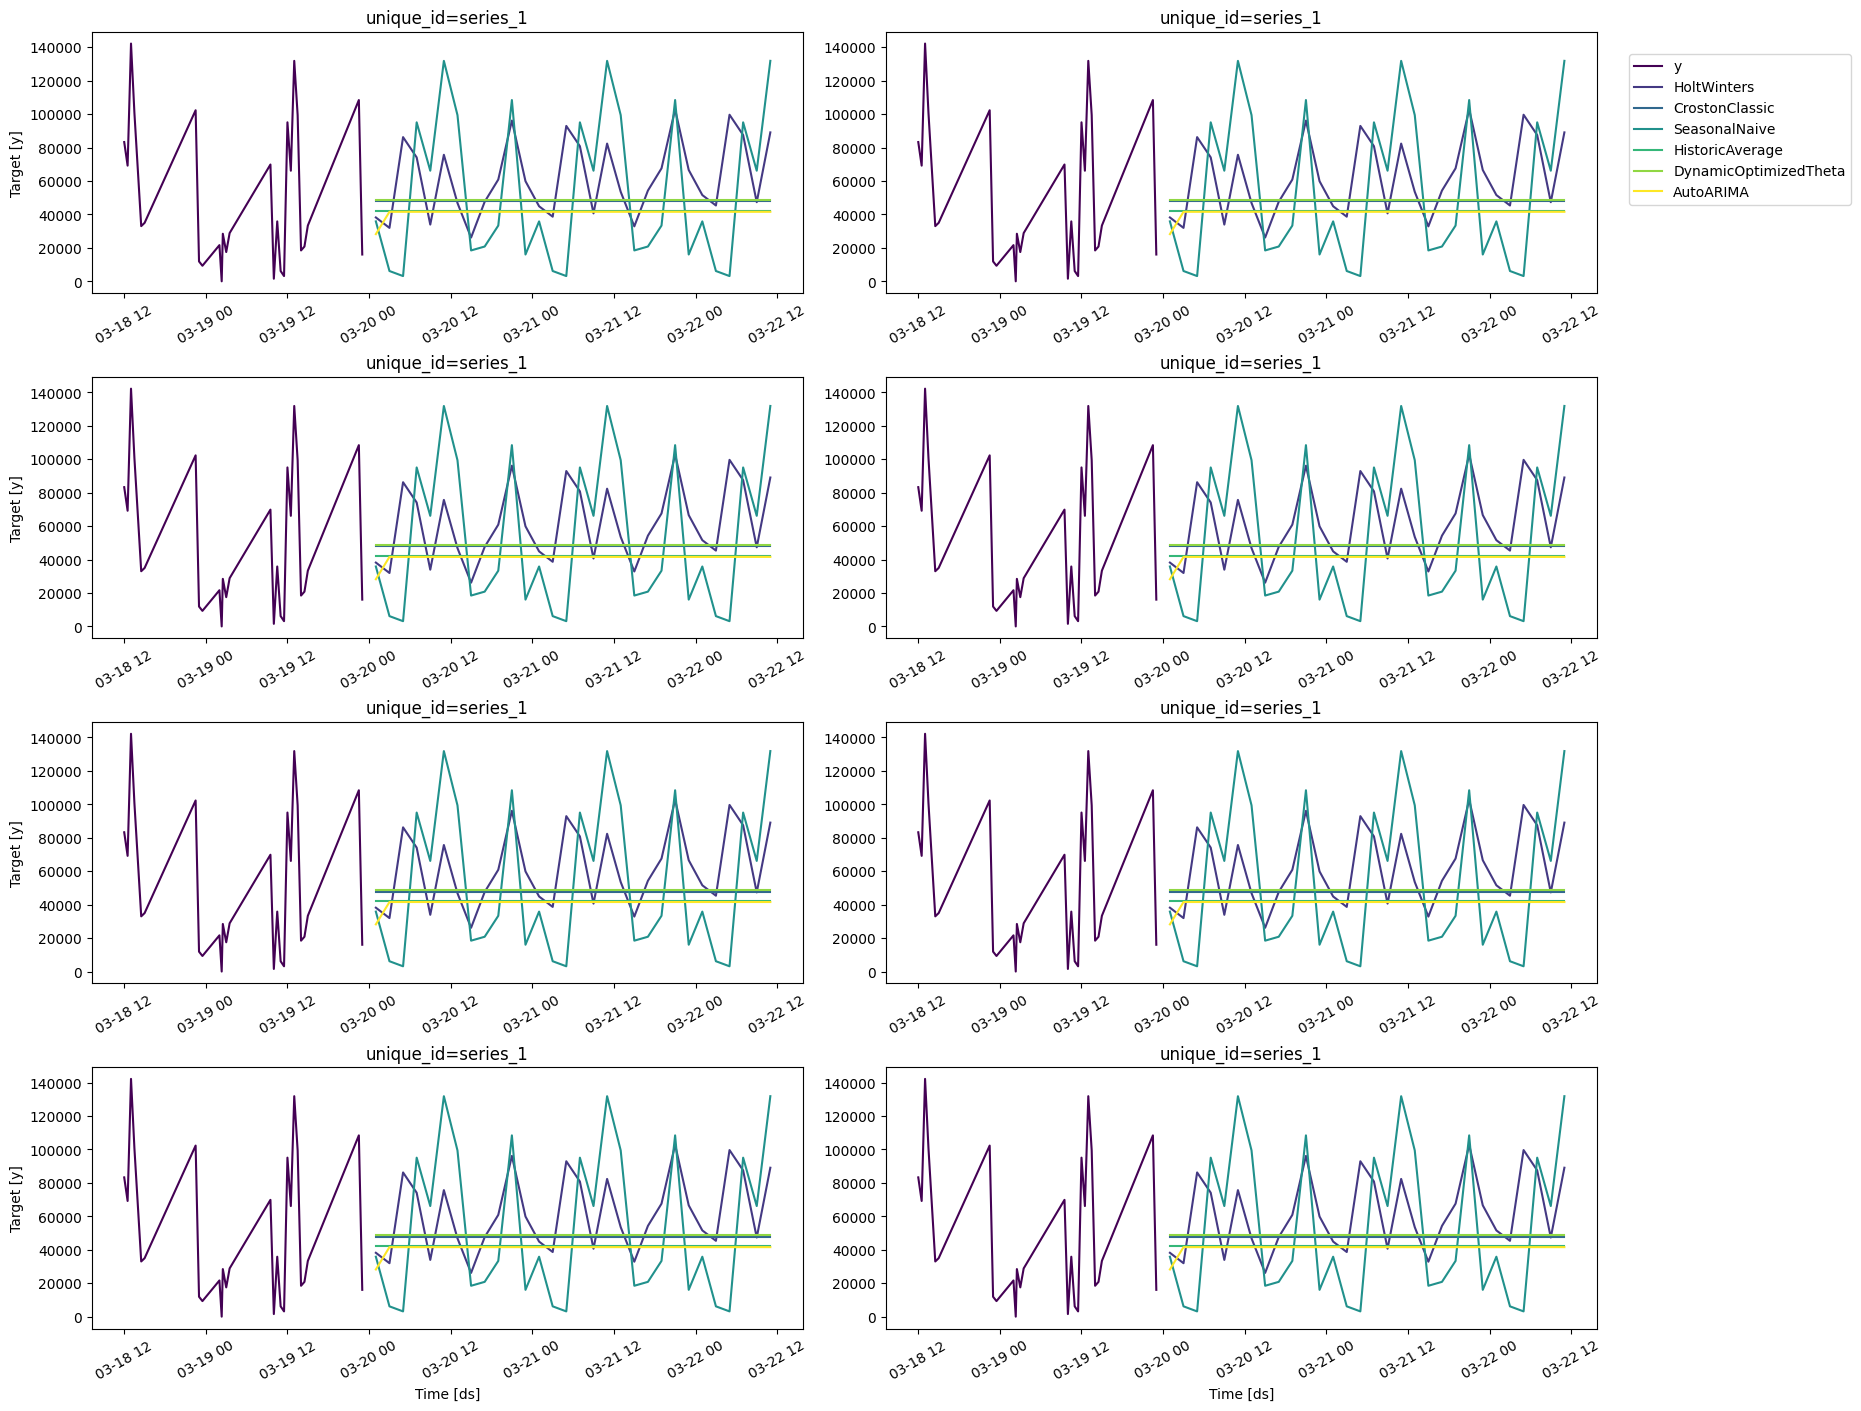

In [ ]:
#Visualizing above prediction with different models mentioned above
plot_series(
    df= TS,
    forecasts_df=future1,
    ids= TS["unique_id"],
    palette="viridis",
    max_insample_length= 28
)

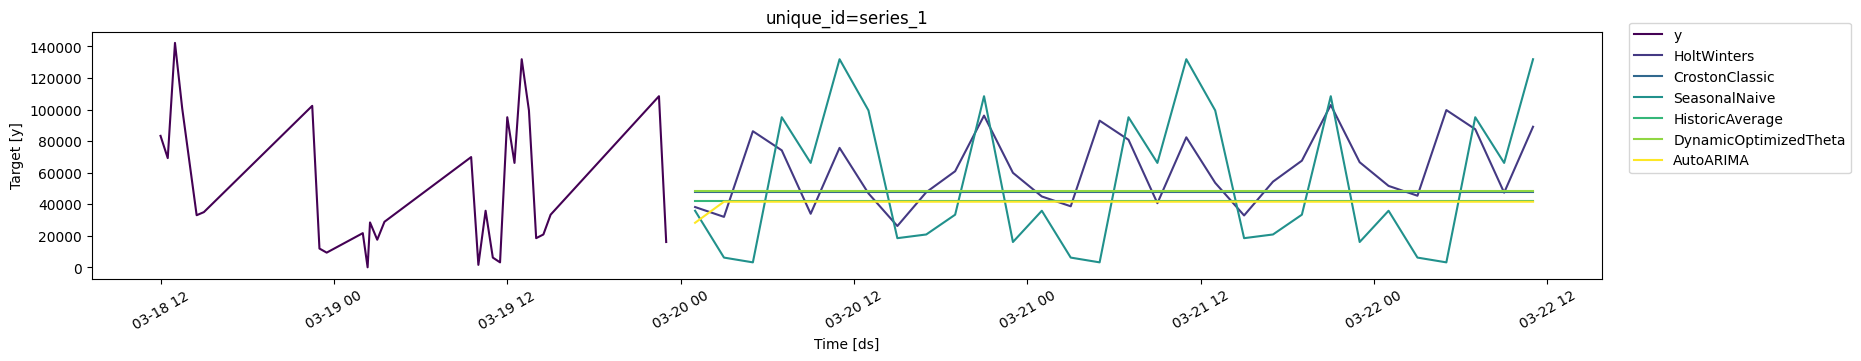

In [ ]:
#Broader view of above prediction
plot_series(
    df= TS,
    forecasts_df=future1,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
#Implementing Cross-Validation
TS= TS.astype("str")
TS["y"]= TS["y"].astype("float")
cv_df = stat.cross_validation(
    df=TS,
    h=6,
    step_size=10,
    n_windows=2
)
cv_df.tail()

,unique_id,ds,cutoff,y,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta
7,series_1,2025-03-19 14:00:00,2025-03-19 13:00:00,18505.0,25053.0,47402.557345,25053.0,40969.781561,80193.247485
8,series_1,2025-03-19 14:30:00,2025-03-19 13:00:00,20844.0,111665.0,47402.557345,111665.0,40969.781561,80193.247485
9,series_1,2025-03-19 15:00:00,2025-03-19 13:00:00,33376.0,57665.0,47402.557345,57665.0,40969.781561,80193.247485
10,series_1,2025-03-19 22:30:00,2025-03-19 13:00:00,108426.0,1448.0,47402.557345,1448.0,40969.781561,80193.247485
11,series_1,2025-03-19 23:00:00,2025-03-19 13:00:00,16070.0,29265.0,47402.557345,29265.0,40969.781561,80193.247485


In [ ]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mse

In [ ]:
#Specifying Evaluation metrics to come up with the best model for prediction
def evaluate_cv(df, metric):
    models = df.columns.drop(['unique_id', 'ds', 'y', 'cutoff']).tolist()
    evals = evaluate(df, metrics=[metric], models=models)
    evals = evals.drop(columns=['metric'])
    evals['best_model'] = evals[models].idxmin(axis=1)
    return evals

Applying mse over the dataframe to get to know the error in a wider manner

In [ ]:
#Describing models for evaluation
model_cv_df = ['HoltWinters', 'CrostonClassic', 'SeasonalNaive', 'HistoricAverage', 'DynamicOptimizedTheta']

# Defining evaluation with above model description
evaluation_cv_results = evaluate(
    cv_df, # Cross validation dataframe as an input for evaluation
    metrics=[mse],
    models=model_cv_df
)
evaluation_cv_results
#evaluation_cv_results["best_model"]= evaluation_cv_results[model_cv_df].idxmin(axis=1)
#evaluate(df=evaluation_cv_results, metrics=[mse], models= model_cv_df)

,unique_id,cutoff,metric,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta
0,series_1,2025-03-19 02:30:00,mse,1.065289e+09,5.965852e+08,1.065289e+09,6.676201e+08,6.846939e+08
1,series_1,2025-03-19 13:00:00,mse,4.596958e+09,1.524710e+09,4.596958e+09,1.592299e+09,2.466343e+09


In [ ]:
evaluation_cv_results["best_model"]= evaluation_cv_results[model_cv_df].idxmin(axis=1)
evaluation_cv_results

,unique_id,cutoff,metric,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,best_model
0,series_1,2025-03-19 02:30:00,mse,1.065289e+09,5.965852e+08,1.065289e+09,6.676201e+08,6.846939e+08,CrostonClassic
1,series_1,2025-03-19 13:00:00,mse,4.596958e+09,1.524710e+09,4.596958e+09,1.592299e+09,2.466343e+09,CrostonClassic


From above,

Seasonal Naive showed highest accurate result with respect to past intervals followed by Holt winters in this dataset while analysing the plot. Whereas, the least mean squared error was obtained in DynamicOptimizedTheta for index 0 and CrostonClassic for index 1, considering stepsize=10. Further, the results can be varied for other dates.

In [ ]:
#Prediction intervals on above models
future2=stat.forecast(df= TS,h=28, level=[90]).head()

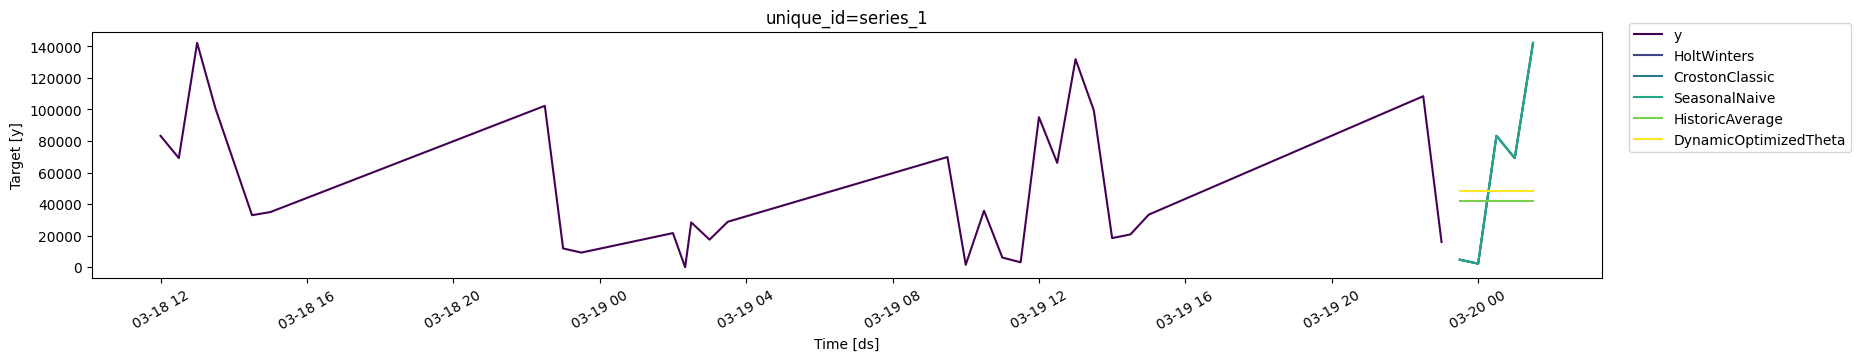

In [ ]:
#Broader view of above prediction
TS["ds"]= pd.to_datetime(TS["ds"], errors="coerce")
plot_series(
    df= TS,
    forecasts_df=future2,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
#stat.forecast(df= evaluation_cv_results,h= 28)

In [ ]:
# Dropping "Cutoff" column from cv_df column
cv_df1= cv_df.drop("cutoff",axis=1)

In [ ]:
##Plotting Model-"SeasonalNaive" with confidence interval=90%
cv_df1["ds"]=cv_df1["ds"].astype("str")
b=stat.forecast(df= cv_df1,h=minute, level=[90])
b.head()

,unique_id,ds,HoltWinters,HoltWinters-lo-90,HoltWinters-hi-90,CrostonClassic,CrostonClassic-lo-90,CrostonClassic-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90,HistoricAverage,HistoricAverage-lo-90,HistoricAverage-hi-90,DynamicOptimizedTheta,DynamicOptimizedTheta-lo-90,DynamicOptimizedTheta-hi-90
0,series_1,2025-03-19 23:30:00,17524.0,17524.0,17524.0,17524.0,17524.0,17524.0,17524.0,17524.0,17524.0,38049.75,-22518.302663,98617.802663,38843.597603,-22240.242188,115889.765625
1,series_1,2025-03-20 00:00:00,28886.0,28886.0,28886.0,28886.0,28886.0,28886.0,28886.0,28886.0,28886.0,38049.75,-22518.302663,98617.802663,38843.597603,-31517.666016,96638.617188
2,series_1,2025-03-20 00:30:00,69877.0,69877.0,69877.0,69877.0,69877.0,69877.0,69877.0,69877.0,69877.0,38049.75,-22518.302663,98617.802663,38843.597603,-45395.015625,103308.468750
3,series_1,2025-03-20 01:00:00,1597.0,1597.0,1597.0,1597.0,1597.0,1597.0,1597.0,1597.0,1597.0,38049.75,-22518.302663,98617.802663,38843.597603,-31104.962891,96486.070312
4,series_1,2025-03-20 01:30:00,35872.0,35872.0,35872.0,35872.0,35872.0,35872.0,35872.0,35872.0,35872.0,38049.75,-22518.302663,98617.802663,38843.597603,-19988.853516,110655.437500


In [ ]:
#Dropping "unique_id" column from cv_df
cv_df= cv_df.drop("unique_id", axis=1)

In [ ]:
##Extracting hour, minute and second from "ds" column
import datetime as dt
cv_df["hour"]= cv_df["ds"].dt.hour
cv_df["min"]= cv_df["ds"].dt.minute
#cv_df1["Day_of_week"]= cv_df["ds"].dt.dayofweek # for day of week
#cv_df1["Day_of_week"]= cv_df["ds"].dt.dayofmonth # for day of month

In [ ]:
cv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ds                     12 non-null     datetime64[ns]
 1   cutoff                 12 non-null     datetime64[ns]
 2   y                      12 non-null     float64       
 3   HoltWinters            12 non-null     float64       
 4   CrostonClassic         12 non-null     float64       
 5   SeasonalNaive          12 non-null     float64       
 6   HistoricAverage        12 non-null     float64       
 7   DynamicOptimizedTheta  12 non-null     float64       
 8   hour                   12 non-null     int32         
 9   min                    12 non-null     int32         
dtypes: datetime64[ns](2), float64(6), int32(2)
memory usage: 996.0 bytes


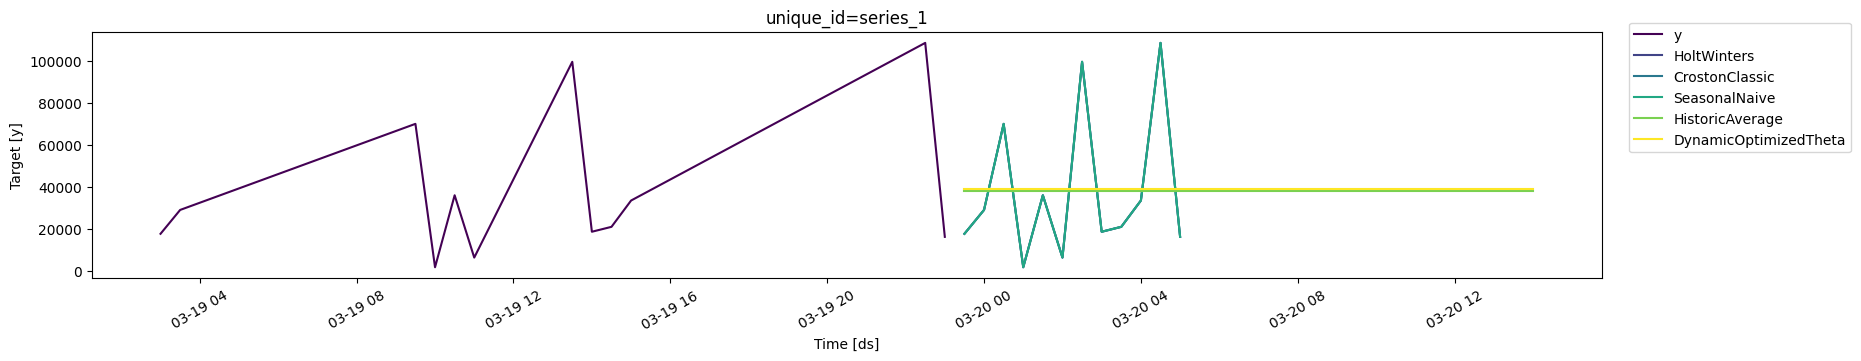

In [ ]:
#Broader view of above prediction
cv_df1["ds"]= pd.to_datetime(cv_df1["ds"],errors="coerce")
plot_series(
    df= cv_df1,
    forecasts_df=b,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
cv_df2= cv_df.drop(columns=["ds","cutoff"])

In [ ]:
#Scaling the data
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
cv_df_scaled= sc.fit_transform(cv_df2)
cv_df_scaled= pd.DataFrame(cv_df_scaled)

In [ ]:
b= b.astype("str")

In [ ]:
cv_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   unique_id              12 non-null     object        
 1   ds                     12 non-null     datetime64[ns]
 2   y                      12 non-null     float64       
 3   HoltWinters            12 non-null     float64       
 4   CrostonClassic         12 non-null     float64       
 5   SeasonalNaive          12 non-null     float64       
 6   HistoricAverage        12 non-null     float64       
 7   DynamicOptimizedTheta  12 non-null     float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 900.0+ bytes


Changing Datatype in order to concatenate

In [ ]:
b["unique_id"]= b["unique_id"].astype("str")
b["ds"]= b["ds"].astype("str")
cv_df1["HoltWinters"]= cv_df1["HoltWinters"].astype("float")
cv_df1["CrostonClassic"]= cv_df1["CrostonClassic"].astype("float")
cv_df1["SeasonalNaive"]= cv_df1["SeasonalNaive"].astype("float")
cv_df1["HistoricAverage"]= cv_df1["HistoricAverage"].astype("float")
cv_df1["DynamicOptimizedTheta"]= cv_df1["DynamicOptimizedTheta"].astype("float")

In [ ]:
b["ds"]= b["ds"].astype("str")
b["HoltWinters"]= b["HoltWinters"].astype("float")
b["HoltWinters-lo-90"]= b['HoltWinters-lo-90'].astype("float")
b["HoltWinters-hi-90"]= b['HoltWinters-hi-90'].astype("float")
b["CrostonClassic"]= b["CrostonClassic"].astype("float")
b["CrostonClassic-lo-90"]= b["CrostonClassic-lo-90"].astype("float")
b["CrostonClassic-hi-90"]= b["CrostonClassic-lo-90"].astype("float")
b["SeasonalNaive"]= b["SeasonalNaive"].astype("float")
b["SeasonalNaive-lo-90"]= b["SeasonalNaive-lo-90"].astype("float")
b["SeasonalNaive-hi-90"]= b["SeasonalNaive-hi-90"].astype("float")
b["HistoricAverage"]= b["HistoricAverage"].astype("float")
b["HistoricAverage-lo-90"]= b["HistoricAverage-lo-90"].astype("float")
b["HistoricAverage-hi-90"]=b["HistoricAverage-hi-90"].astype("float")
b["DynamicOptimizedTheta"]= b["DynamicOptimizedTheta"].astype("float")
b["DynamicOptimizedTheta-lo-90"]= b["DynamicOptimizedTheta-lo-90"].astype("float")
b["DynamicOptimizedTheta-hi-90"]= b["DynamicOptimizedTheta-hi-90"].astype("float")

In [ ]:
b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   unique_id                    30 non-null     object 
 1   ds                           30 non-null     object 
 2   HoltWinters                  12 non-null     float64
 3   HoltWinters-lo-90            12 non-null     float64
 4   HoltWinters-hi-90            12 non-null     float64
 5   CrostonClassic               12 non-null     float64
 6   CrostonClassic-lo-90         12 non-null     float64
 7   CrostonClassic-hi-90         12 non-null     float64
 8   SeasonalNaive                12 non-null     float64
 9   SeasonalNaive-lo-90          12 non-null     float64
 10  SeasonalNaive-hi-90          12 non-null     float64
 11  HistoricAverage              30 non-null     float64
 12  HistoricAverage-lo-90        30 non-null     float64
 13  HistoricAverage-hi-90 

In [ ]:
cv_df1["ds"]= cv_df1["ds"].astype("str")
cv_df_= cv_df1+b

In [ ]:
future3=stat.forecast(df=TS_final, h=minute, level=[90])
future3.head()

,unique_id,ds,HoltWinters,HoltWinters-lo-90,HoltWinters-hi-90,CrostonClassic,CrostonClassic-lo-90,CrostonClassic-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90,HistoricAverage,HistoricAverage-lo-90,HistoricAverage-hi-90,DynamicOptimizedTheta,DynamicOptimizedTheta-lo-90,DynamicOptimizedTheta-hi-90
0,series_1,2025-03-19 23:30:00,4838.0,-109880.95405,119556.95405,4838.0,-109880.95405,119556.95405,4838.0,-109880.95405,119556.95405,42240.264327,-26103.56762,110584.096274,48610.398178,-15500.059570,129474.093750
1,series_1,2025-03-20 00:00:00,2330.0,-112388.95405,117048.95405,2330.0,-112388.95405,117048.95405,2330.0,-112388.95405,117048.95405,42240.264327,-26103.56762,110584.096274,48610.398178,-25237.167969,109269.085938
2,series_1,2025-03-20 00:30:00,83306.0,-31412.95405,198024.95405,83306.0,-31412.95405,198024.95405,83306.0,-31412.95405,198024.95405,42240.264327,-26103.56762,110584.096274,48610.398178,-39802.121094,116269.421875
3,series_1,2025-03-20 01:00:00,69208.0,-45510.95405,183926.95405,69208.0,-45510.95405,183926.95405,69208.0,-45510.95405,183926.95405,42240.264327,-26103.56762,110584.096274,48610.398178,-24804.015625,109108.968750
4,series_1,2025-03-20 01:30:00,142194.0,27475.04595,256912.95405,142194.0,27475.04595,256912.95405,142194.0,27475.04595,256912.95405,42240.264327,-26103.56762,110584.096274,48610.398178,-13137.117188,123980.414062


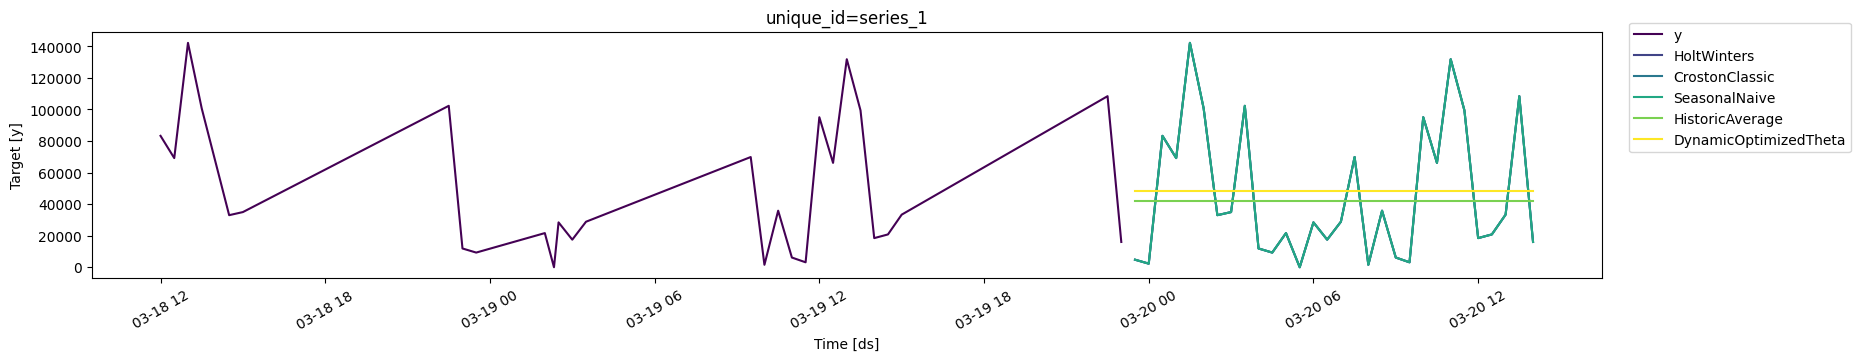

In [ ]:
#Broader view of above prediction
plot_series(
    df= TS_final,
    forecasts_df=future3,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
ts["CUT OFF TIME"].describe()

,CUT OFF TIME
count,1918
unique,31
top,9:30
freq,286


In [ ]:
ts_.columns

Index(['S.R  NO.', 'Lane', 'DISPATCHED FROM', 'SHIFT', 'GATE PASS NO.',
       'GATE IN DATE', 'GATE IN TIME', 'DOCK IN DATE', 'DOCK IN TIME',
       'DOCK OUT DATE', 'DOCK OUT TIME', 'GATE OUT DATE', 'GATE OUT TIME',
       'CUT OFF TIME', 'COC', 'CM', 'Bag Qty\n(As Per ERP)',
       'Large Shipment \nBag(QTY)', 'IT & STOCK & EKL BAG', 'TOTAL BAGS',
       'SHIPMENT', 'WT.', 'Trip ID', 'SPILL OVER BAG DETAIL', 'Vendor Name',
       'Vehicle No', 'DOCK NO', 'Description', 'SIZE', 'KILO METER',
       'Adhoc/Regular', 'DRIVER NAME', 'Contact No.', 'Seal No.',
       'Prealert Status', 'VEHICLE LOAD BY', 'Report Created By',
       'CUT_OFF_TIME', 'Diff1', 'Diff2', 'ds'],
      dtype='object')

In [ ]:
a= ts_[ts_["CUT OFF TIME"]!= ts_["CUT_OFF_TIME"]]
a.describe()

,S.R NO.,CM,Bag Qty\n(As Per ERP),Large Shipment \nBag(QTY),TOTAL BAGS,SHIPMENT,SPILL OVER BAG DETAIL,DOCK NO,Contact No.,Diff1,Diff2
count,1950.000000,1.950000e+03,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000,1950.000000,1.950000e+03,1947.000000,1945.000000
mean,485.280000,2.227152e+08,29.476923,33.556923,63.017436,928.662858,0.097436,32.690769,8.591774e+09,2.023112,1.817481
std,280.428384,1.375631e+05,87.264401,117.735211,139.646088,2769.283014,3.041654,7.709667,2.416036e+09,3773.257506,6574.853140
min,1.000000,2.224701e+08,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,7.484974e+08,-26684.000000,-53493.000000
25%,244.250000,2.225656e+08,0.000000,0.000000,4.000000,16.000000,0.000000,29.000000,7.895495e+09,-417.500000,-748.000000
50%,483.000000,2.227364e+08,2.000000,0.000000,17.000000,57.500000,0.000000,33.000000,8.826480e+09,-12.000000,250.000000
75%,727.000000,2.227939e+08,17.000000,16.000000,40.000000,571.000000,0.000000,38.000000,9.518272e+09,408.500000,901.000000
max,997.000000,2.229430e+08,786.000000,1001.000000,1001.000000,26964.000000,95.000000,60.000000,7.066518e+10,26809.000000,34513.000000


In [ ]:
#Overlapping columns between two dataframe
ol= set(TS.columns)and set(future.columns)
ol

{'ARIMA_no_Season',
 'HistoricAverage',
 'Naive',
 'SeasonalNaive',
 'WindowAverage',
 'ds',
 'unique_id'}

In [ ]:
complete= pd.concat([TS, future1],join="outer", keys=["unique_id","ds"])
complete.columns
complete_= complete[complete[['unique_id','ds','y','HoltWinters', 'CrostonClassic','SeasonalNaive','HistoricAverage', 'DynamicOptimizedTheta','AutoARIMA']].notnull()]
complete_.fillna(0)
complete_.head()

unique_id                  ds        y  HoltWinters  \
unique_id 0  series_1 2025-03-17 22:30:00   4034.0          NaN   
          1  series_1 2025-03-18 02:00:00  23475.0          NaN   
          2  series_1 2025-03-18 02:20:00      7.0          NaN   
          3  series_1 2025-03-18 02:30:00  24369.0          NaN   
          4  series_1 2025-03-18 03:00:00  15262.0          NaN   

             CrostonClassic  SeasonalNaive  HistoricAverage  \
unique_id 0             NaN            NaN              NaN   
          1             NaN            NaN              NaN   
          2             NaN            NaN              NaN   
          3             NaN            NaN              NaN   
          4             NaN            NaN              NaN   

             DynamicOptimizedTheta  AutoARIMA  
unique_id 0                    NaN        NaN  
          1                    NaN        NaN  
          2                    NaN        NaN  
          3                    NaN        NaN  
          4                    NaN        NaN

In [ ]:
complete.columns

Index(['unique_id', 'ds', 'y', 'HoltWinters', 'CrostonClassic',
       'SeasonalNaive', 'HistoricAverage', 'DynamicOptimizedTheta',
       'AutoARIMA'],
      dtype='object')

In [ ]:
"""complete["GATE IN DATE"]= complete["GATE IN DATE"].to_numpy()
complete["ds"]= complete["ds"].to_numpy()"""

'complete["GATE IN DATE"]= complete["GATE IN DATE"].to_numpy()\ncomplete["ds"]= complete["ds"].to_numpy()'

In [ ]:
complete.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 70 entries, ('unique_id', np.int64(0)) to ('ds', np.int64(29))
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   unique_id              70 non-null     object        
 1   ds                     70 non-null     datetime64[ns]
 2   y                      40 non-null     float64       
 3   HoltWinters            30 non-null     float64       
 4   CrostonClassic         30 non-null     float64       
 5   SeasonalNaive          30 non-null     float64       
 6   HistoricAverage        30 non-null     float64       
 7   DynamicOptimizedTheta  30 non-null     float64       
 8   AutoARIMA              30 non-null     float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 6.6+ KB


In [ ]:
for col in complete.columns:
  print(col)
##complete[["Naive"]]= complete["Naive"].copy()

unique_id
ds
y
HoltWinters
CrostonClassic
SeasonalNaive
HistoricAverage
DynamicOptimizedTheta
AutoARIMA


In [ ]:
#Defining columns according to evaluation metrics
def evaluate_cv(complete_, metric):
    Models = complete_.columns.drop(['unique_id', 'ds', 'y']).tolist()
    Evals = evaluate(complete_, metrics=[metric], models=Models)
    Evals = Evals.drop(columns=['metric'])
    Evals['best_model'] = Evals[Models].idxmin(axis=1)
    return Evals

In [ ]:
from utilsforecast.losses import mse
evaluation_df = evaluate_cv(complete_, mae)
evaluation_df.head()

/tmp/ipykernel_5587/2480173871.py:6: FutureWarning:

The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError



,unique_id,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,AutoARIMA,best_model
0,series_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Let's evaluate above while splitting the dataset into train and test data

In [ ]:
# Splitting the data into training and testing sets
# The last 'minute' (30) observations will be used for testing
n_test_points = minute
train_df = TS_final.iloc[:-n_test_points].copy()
test_df = TS_final.iloc[-n_test_points:].copy()
print(train_df)

"""# Fit the StatsForecast model on the training data
stat.fit(df=train_df)

# Generate forecasts for the test period
forecast_test = stat.predict(h=n_test_points)

# Merge the actual test values with the forecasts for evaluation
# The 'evaluate' function expects a DataFrame containing 'ds', 'unique_id', 'y' (actuals), and model predictions
evaluation_df = pd.merge(test_df, forecast_test, on=['unique_id', 'ds'], how='left')

# Print head of evaluation_df to inspect (optional)
# print("Evaluation DataFrame Head:")
# print(evaluation_df.head())
# print("\nNumber of missing values in evaluation_df after merge:")
# print(evaluation_df.isnull().sum())
"""

  unique_id                  ds         y
0  series_1 2025-03-17 22:30:00    4034.0
1  series_1 2025-03-18 02:00:00   23475.0
2  series_1 2025-03-18 02:20:00       7.0
3  series_1 2025-03-18 02:30:00   24369.0
4  series_1 2025-03-18 03:00:00   15262.0
5  series_1 2025-03-18 03:30:00   25053.0
6  series_1 2025-03-18 04:00:00  111665.0
7  series_1 2025-03-18 09:30:00   57665.0
8  series_1 2025-03-18 10:00:00    1448.0
9  series_1 2025-03-18 10:30:00   29265.0


'# Fit the StatsForecast model on the training data\nstat.fit(df=train_df)\n\n# Generate forecasts for the test period\nforecast_test = stat.predict(h=n_test_points)\n\n# Merge the actual test values with the forecasts for evaluation\n# The \'evaluate\' function expects a DataFrame containing \'ds\', \'unique_id\', \'y\' (actuals), and model predictions\nevaluation_df = pd.merge(test_df, forecast_test, on=[\'unique_id\', \'ds\'], how=\'left\')\n\n# Print head of evaluation_df to inspect (optional)\n# print("Evaluation DataFrame Head:")\n# print(evaluation_df.head())\n# print("\nNumber of missing values in evaluation_df after merge:")\n# print(evaluation_df.isnull().sum())\n'

In [ ]:
#Removing "unique_id" from index
complete= complete.reset_index(drop=True)
complete.tail()

,unique_id,ds,y,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,AutoARIMA
65,series_1,2025-03-22 03:00:00,NaN,45379.695354,47864.573561,6203.0,42240.264327,48610.398178,41608.098134
66,series_1,2025-03-22 05:00:00,NaN,99639.969898,47864.573561,3179.0,42240.264327,48610.398178,41608.098134
67,series_1,2025-03-22 07:00:00,NaN,87514.355029,47864.573561,95103.0,42240.264327,48610.398178,41608.098134
68,series_1,2025-03-22 09:00:00,NaN,47340.570691,47864.573561,66168.0,42240.264327,48610.398178,41608.098134
69,series_1,2025-03-22 11:00:00,NaN,89081.872991,47864.573561,131850.0,42240.264327,48610.398178,41608.098134


In [ ]:
X= cv_df[["cutoff","y"]]
Y= cv_df["SeasonalNaive"]
# The 'complete' DataFrame is empty due to non-overlapping time ranges in the merge.
final= evaluate(
    complete,
    #complete.drop(["GATE IN DATE", "ds"],axis=1),
    metrics=[mae],
)
final.tail()
#X_train.tail()

,unique_id,metric,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,AutoARIMA
0,series_1,mae,NaN,NaN,NaN,NaN,NaN,NaN


1.

In [ ]:
X= cv_df[["cutoff","y"]]
Y= cv_df["SeasonalNaive"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size= 0.3, random_state= 42)

<Axes: >

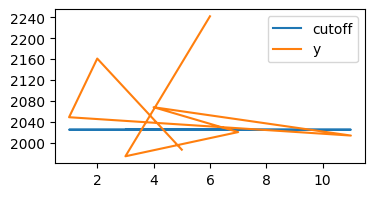

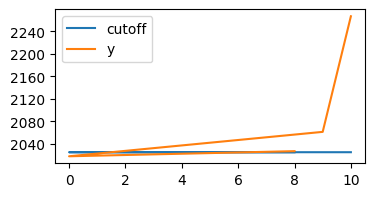

In [ ]:
#Plotting the X_train, X_test
X_train.plot(legend="train_X", figsize=(4,2))
X_test.plot(legend="test_X",figsize=(4,2))

<Axes: >

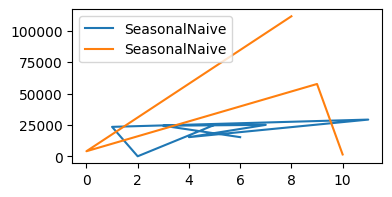

In [ ]:
#Plotting the X_train, X_test
Y_train.plot(legend="train_Y", figsize=(4,2))
Y_test.plot(legend="test_Y",figsize=(4,2))

##2. Parameters "ds" and "y as input and "Seasonal Naive" as output to get patterns for future forecasting.

Further could try with different models as output to get relevant pattern according to the dataset

In [ ]:
#Adding values with duplicate index values using groupby
cv_df['y_tot'] = cv_df.groupby('ds')['y'].transform('sum')

In [ ]:
#Adding values with duplicate index values using groupby
cv_df['SeasonalNaive_tot'] = cv_df.groupby('ds')['SeasonalNaive'].transform('sum')

#Hereby dropping duplicate values from "ds"
cv_df = cv_df.drop_duplicates(subset=['ds'])

In [ ]:
x= cv_df[["ds","y_tot"]]
y= cv_df["SeasonalNaive_tot"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size= 0.3, random_state= 42)

<Axes: >

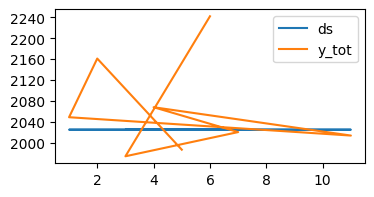

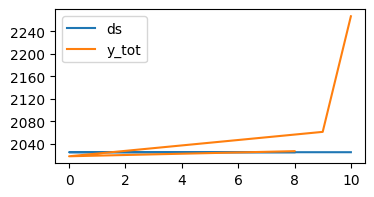

In [ ]:
#Plotting the X_train, X_test
x_train.plot(legend="train_x", figsize=(4,2))
x_test.plot(legend="test_x",figsize=(4,2))

<Axes: >

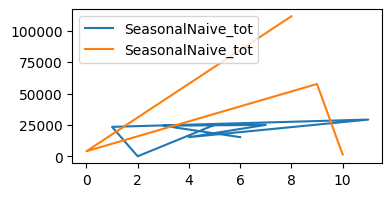

In [ ]:
#Plotting the X_train, X_test
y_train.plot(legend="train_y", figsize=(4,2))
y_test.plot(legend="test_y",figsize=(4,2))

##3. Parameters "cutoff" and "ds" as inputs and "y" as output to get patterns for future forecasting with respect to specific time for other factors like breach.

Further could try with different models as output to get relevant pattern according to the dataset

In [ ]:
X1= cv_df[["cutoff","ds"]]
Y1= cv_df["y"]

In [ ]:
from sklearn.model_selection import train_test_split
X1_train, X1_test, Y1_train, Y1_test= train_test_split(X1,Y1, test_size= 0.3, random_state= 42)

<Axes: >

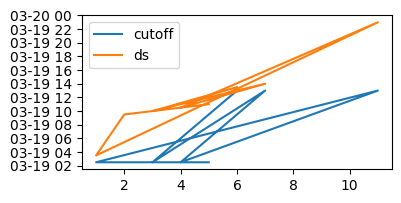

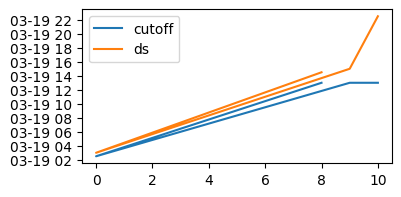

In [ ]:
#Plotting the X1_train, X1_test
X1_train.plot(legend="train_x", figsize=(4,2))
X1_test.plot(legend="test_x",figsize=(4,2))

<Axes: >

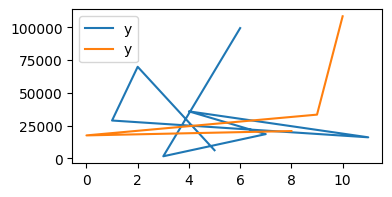

In [ ]:
#Plotting the Y1_train, Y1_test
Y1_train.plot(legend="train_Y1", figsize=(4,2))
#Y1_train.plot(label="train_Y1")
Y1_test.plot(legend="test_Y1",figsize=(4,2))
#Y1_test.plot(label="test_Y1")

##Model 3: AutoARIMA

In [ ]:
from statsforecast.models import AutoARIMA
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='ME',
)
sf.fit(TS_final)
sf.predict(h=12, level=[95])

,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-hi-95
0,series_1,2025-03-31 23:00:00,28248.988627,-49990.422085,106488.399338
1,series_1,2025-04-30 23:00:00,41608.098134,-39925.921424,123142.117693
2,series_1,2025-05-31 23:00:00,41608.098134,-39925.921424,123142.117693
3,series_1,2025-06-30 23:00:00,41608.098134,-39925.921424,123142.117693
4,series_1,2025-07-31 23:00:00,41608.098134,-39925.921424,123142.117693
5,series_1,2025-08-31 23:00:00,41608.098134,-39925.921424,123142.117693
6,series_1,2025-09-30 23:00:00,41608.098134,-39925.921424,123142.117693
7,series_1,2025-10-31 23:00:00,41608.098134,-39925.921424,123142.117693
8,series_1,2025-11-30 23:00:00,41608.098134,-39925.921424,123142.117693
9,series_1,2025-12-31 23:00:00,41608.098134,-39925.921424,123142.117693


## TRAJECTORY SIMULATION

In [ ]:
pip install simulate==0.1.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
  Using cached scikit_build-0.19.0-py3-none-any.whl.metadata (19 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 89.2 MB/s eta 0:00:00
Using cached scikit_build-0.19.0-py3-none-any.whl (85 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.2/221.2 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.9/272.9 kB 19.0 MB/s eta 0:00:00
  Created wheel for simulate: filename=simulate-0.1.2-py3-none-any.whl size=220779 sha256=9e217a9ee080cf8cf6b10bbec29628eb1f90ae3fe0c4142cdbc6

Trajectory simulation allows to generate multiple possible future realizations of a time series based on the fitted model’s error distribution.

This is particularly useful for: - Risk analysis and stress testing. - Scenario planning (e.g., “what if” analyses). - Calculating complex metrics based on future paths (e.g., probability of breach).

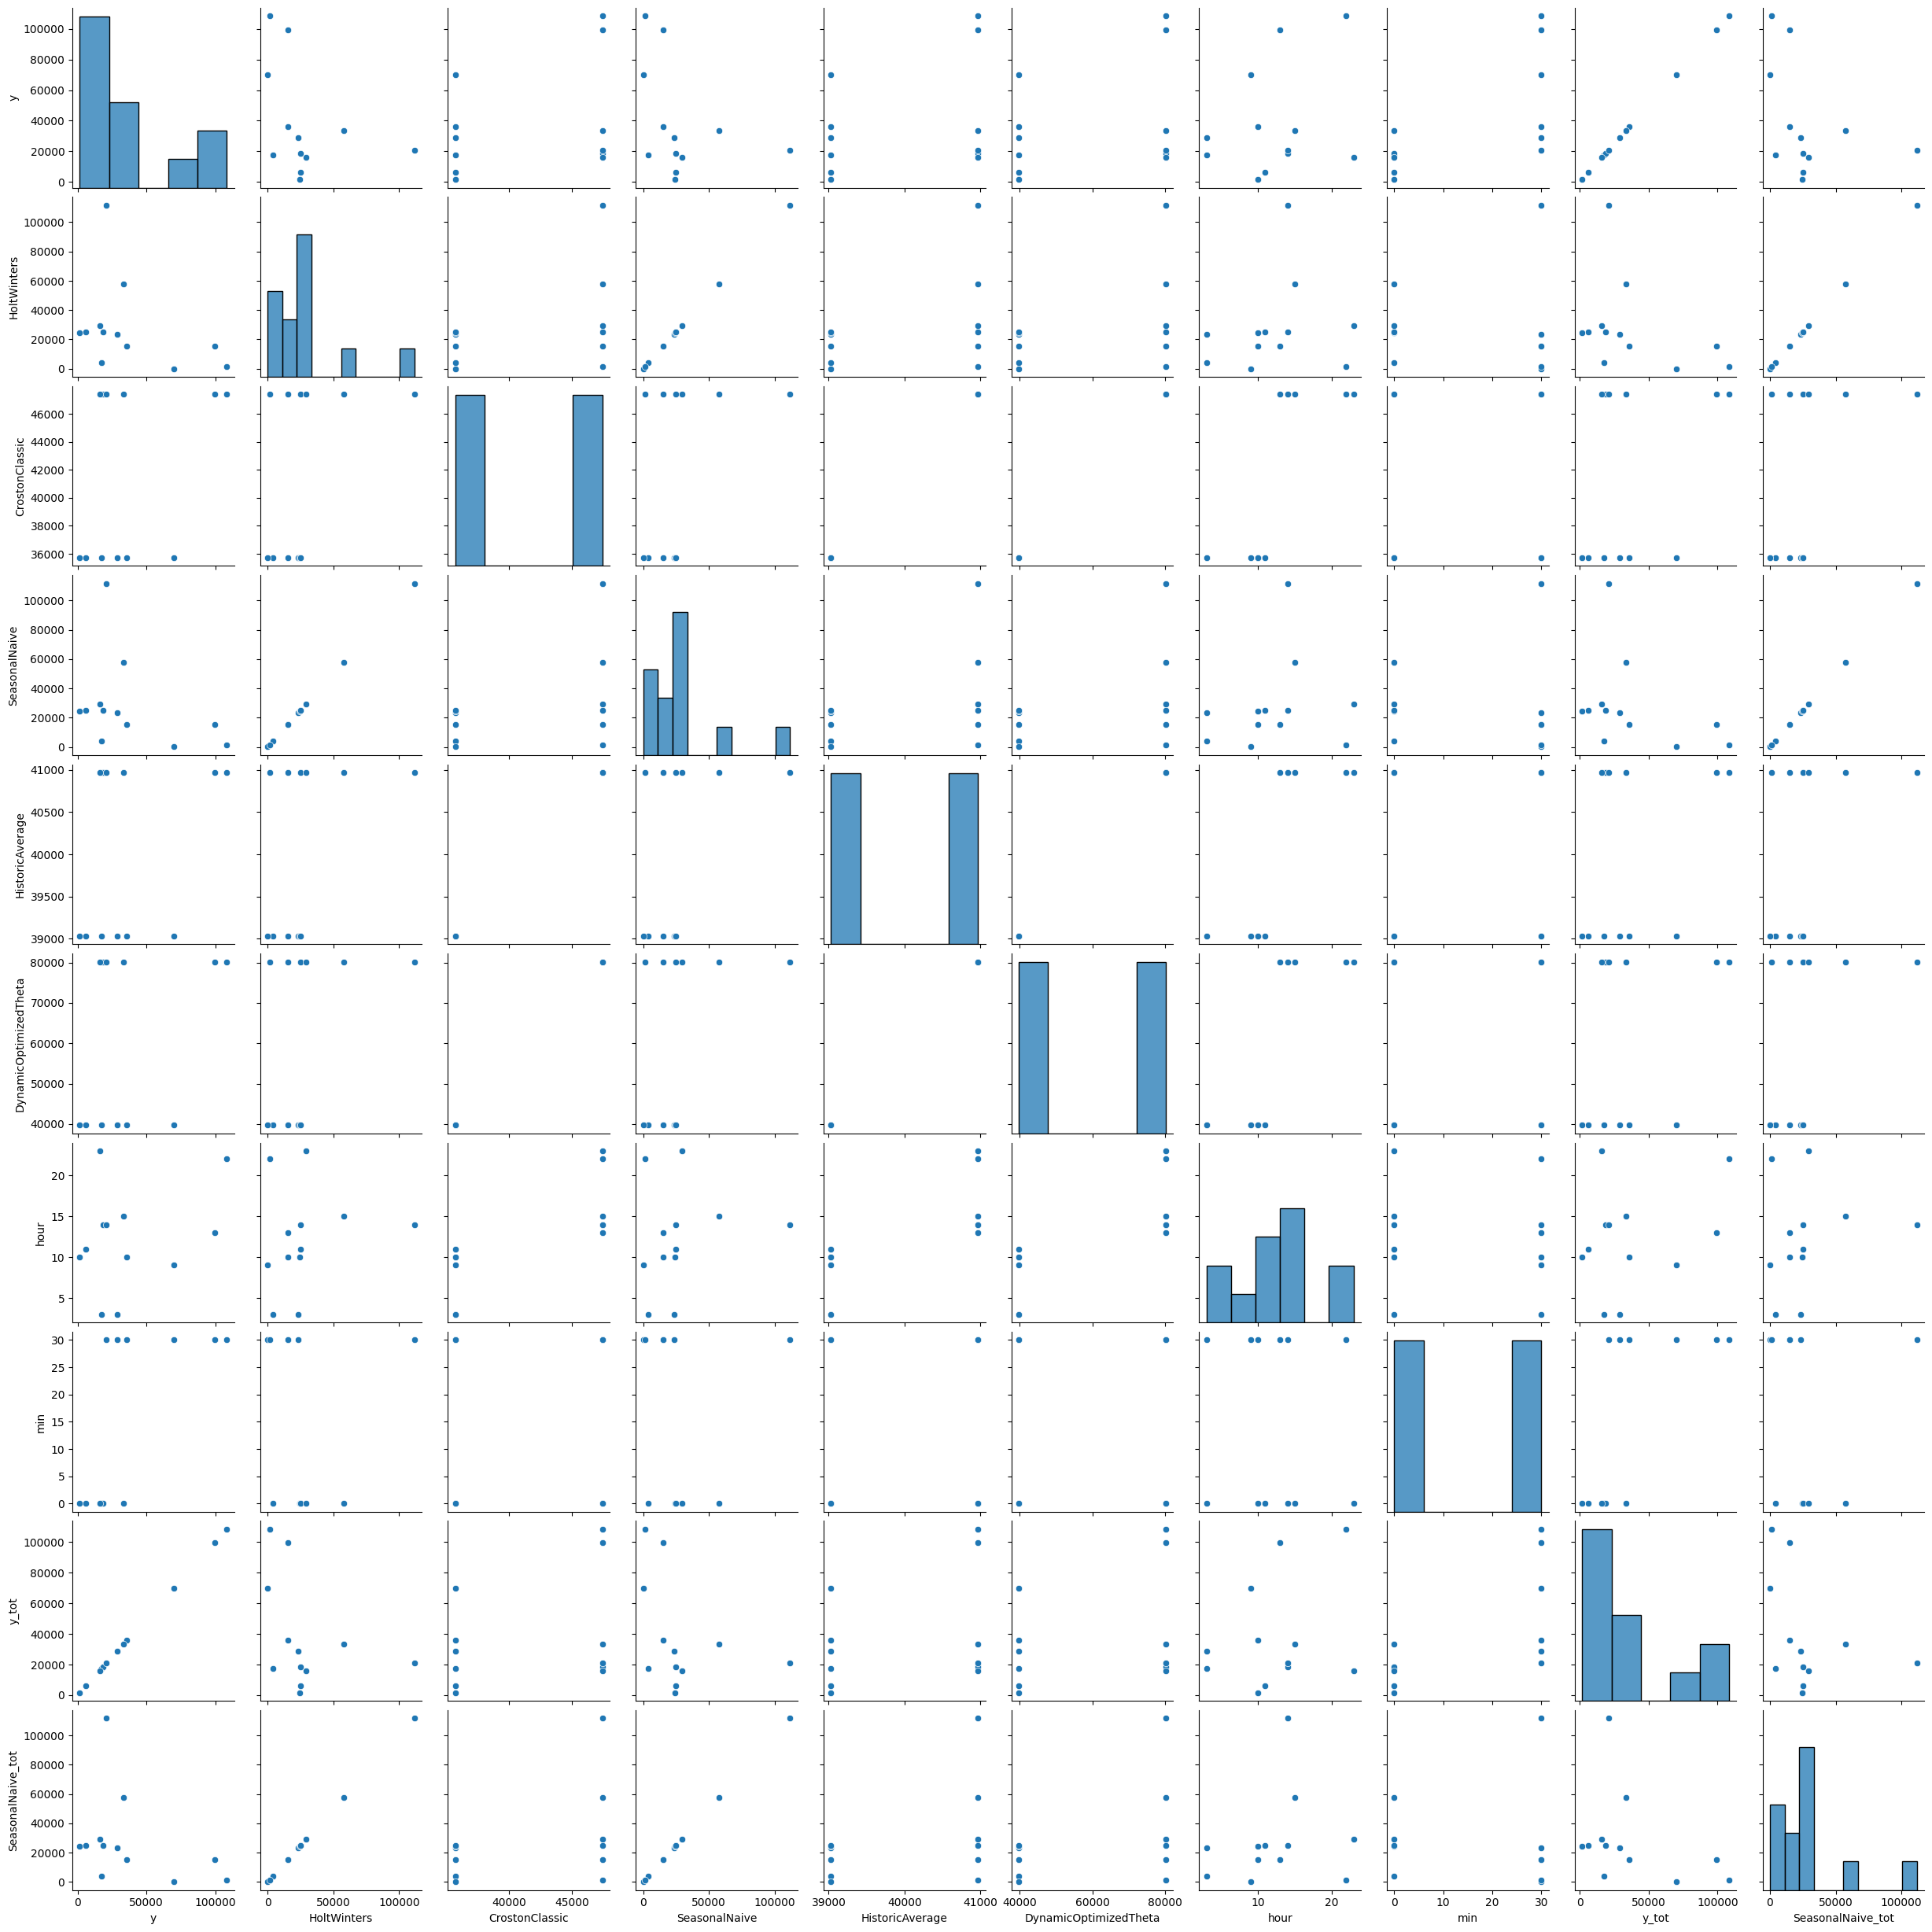

In [ ]:
#import scikit-learn as skl
import seaborn as sns
g = sns.pairplot(cv_df)
g

In [ ]:
pip install huggingface-hub==0.25.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.6/436.6 kB 11.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.18.0
    Uninstalling huggingface_hub-1.18.0:
      Successfully uninstalled huggingface_hub-1.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.25.2 which is incompatible.
diffusers 0.38.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.25.2 which is incompatible.
transformers 5.10.2 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.25.2 which is incompatible.


In [ ]:
import huggingface_hub
from huggingface_hub import hf_hub_download
from huggingface_hub import constants
from huggingface_hub.constants import HF_HUB_CACHE

In [ ]:
TS_final1= TS_final.reset_index()
TS_final1= TS_final1.drop(columns=["unique_id"])
TS_final1= TS_final1.to_numpy(dtype=float) # Ensures numeric dtype
TS_final1

array([[0.00000000e+00, 1.74225060e+18, 4.03400000e+03],
       [1.00000000e+00, 1.74226320e+18, 2.34750000e+04],
       [2.00000000e+00, 1.74226440e+18, 7.00000000e+00],
       [3.00000000e+00, 1.74226500e+18, 2.43690000e+04],
       [4.00000000e+00, 1.74226680e+18, 1.52620000e+04],
       [5.00000000e+00, 1.74226860e+18, 2.50530000e+04],
       [6.00000000e+00, 1.74227040e+18, 1.11665000e+05],
       [7.00000000e+00, 1.74229020e+18, 5.76650000e+04],
       [8.00000000e+00, 1.74229200e+18, 1.44800000e+03],
       [9.00000000e+00, 1.74229380e+18, 2.92650000e+04],
       [1.00000000e+01, 1.74229560e+18, 4.83800000e+03],
       [1.10000000e+01, 1.74229740e+18, 2.33000000e+03],
       [1.20000000e+01, 1.74229920e+18, 8.33060000e+04],
       [1.30000000e+01, 1.74230100e+18, 6.92080000e+04],
       [1.40000000e+01, 1.74230280e+18, 1.42194000e+05],
       [1.50000000e+01, 1.74230460e+18, 1.00742000e+05],
       [1.60000000e+01, 1.74230820e+18, 3.30420000e+04],
       [1.70000000e+01, 1.74231

In [ ]:
from scipy.stats import laplace
##Using laplace distribution for simulation and forecasting the future values
##Estimating location and scaling using Maximum likelihoof estimator(MLE) for laplace forecasting
location, scaling= laplace.fit(TS_final1)
print(location)
print(scaling)

26765.5
1.742335170000031e+18


## INCORPORATING LAPLACE SIMULATION IN ABOVE DATAFRAME:
Laplace simulation is basically use instead of normal distribution when heavy tails are present.
In addition to this, it is mainly used for anomaly detection, Shock modeling, differential privacy, etc.

Here Shock modeling behaves as cyclicity term from time series component, where Shock modeling in time series involves various techniques to account for unexpected events that can disrupt the behavior of a time series. These shocks can be economic downturns, natural disasters, policy changes, pandemics, or market crashes.

In [ ]:
#Feature creation "noise" for laplace simulation
n_points=120
noise = np.random.normal(loc=1, scale=1.0, size=n_points) # Hcan include eavy tails(due to laplace) for stress testing
noise= noise.flatten()
TS_final1= TS_final1.flatten()
TS_final1_series= pd.Series(TS_final1)
final_Series= TS_final1_series + noise
final_Series= pd.Series(final_Series)

In [ ]:
#Declaring Laplace_noise and converting the above df into a Series for Final Calculation
scale=1
#laplace_noise = np.random.laplace(loc=0, scale=scale, size=len(final_Series))
Total= final_Series
print(Total)

0      3.042536e+00
1      1.742251e+18
2      4.035115e+03
3      1.862576e+00
4      1.742263e+18
           ...     
115    1.742423e+18
116    1.084258e+05
117    4.169184e+01
118    1.742425e+18
119    1.607135e+04
Length: 120, dtype: float64


In [ ]:
#Fitting ARIMA model on above Laplace simulation
model = ARIMA(Total, order=(1,2,1),trend="n")
fitted_model = model.fit()
forecast = fitted_model.forecast(steps=48)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



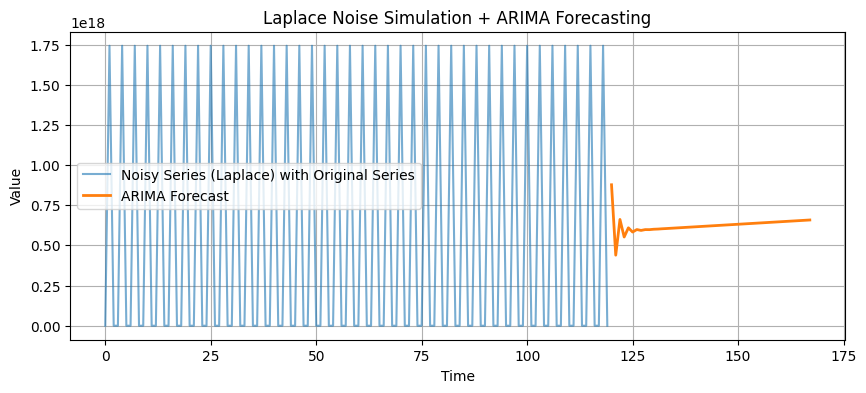

In [ ]:
#Plotting above forecasted model with noise
plt.figure(figsize=(10,4))
plt.plot(Total, label="Noisy Series (Laplace) with Original Series", alpha=0.6)
plt.plot(range(len(Total), len(Total) + len(forecast)), forecast, label="ARIMA Forecast", linewidth=2)
plt.legend()
plt.title("Laplace Noise Simulation + ARIMA Forecasting")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

Above plot shows:

Adding laplace simulation has given non-linear curve as comparison to prediction from ARIMA model that was showing mean or median value as prediction for future steps. Further, using best parameter from ARIMA model using cross-validation, can provide the better forecasting behaviour in addition of above technique.

In [ ]:
from huggingface_hub.constants import HF_HUB_CACHE
import simulate
#a= sf.fit(TS_final)
simulated = a.simulate(
    df=TS_final, # The input DataFrame is required for simulation
    h=12,         # Forecast horizon (from previous context, 12 steps)
    n_paths=56,   # Number of simulation paths (from previous context, 56 repetitions)
    seed=42       # Optional: for reproducibility, consistent with other simulation calls
)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



AttributeError: 'DataFrame' object has no attribute 'simulate'

In [ ]:
#Specifying the parameters require for simulation using AutoARIMA
#from huggingface_hub import constants
#from huggingface_hub.constants import hf_cache_home
from huggingface_hub.constants import hf_cache_home
import simulate as simulate
n=56
h=12
ar_sim= sf.simulate(df= cv_df, h= h, n_paths= n, seed= 42)
ar_sim.tail()

In [ ]:
##To see the unique values after above trajectory simulation


In [ ]:
#Using t-test for automatic simulation
sim_t_auto = sf.simulate(
    df=cv_df,
    h=h,
    n_paths=n,
    error_distribution='t',  # No error_params specified - parameters inferred automatically
    seed=42
)

In [ ]:
#Using laplace for automatic simulation
sim_laplace_auto = sf.simulate(
    df=cv_df,
    h=h,
    n_paths=n,
    error_distribution='laplace',  # No error_params specified - parameters inferred automatically
    seed=42
)

In [ ]:
#Using skew-normal for automatic simulation
sim_skewnormal_auto = sf.simulate(
    df=cv_df,
    h=h,
    n_paths=n,
    error_distribution='skew-normal',  # No error_params specified - parameters inferred automatically
    seed=42
)

## Trajectory simulation using User defined parameters

This is useful when:
 - There is domain knowledge about the error distribution
 - One wants to stress-test with extreme scenarios
 - One wants to ensure consistency across different datasets.

In [ ]:
# Student's t with very heavy tails (low df = more extreme values)
## Controls tail heaviness (lower = heavier tails)
simul_t_heavy = sf.simulate(
    df=cv_df,
    h=h,
    n_paths=n,
    error_distribution='t',
    error_params={'df': 3},  # Heavy tails for stress testing
    seed=42
)

In [ ]:
# Skew-normal with right skew (for positively skewed errors)
## Controls asymmetry (negative = left skew, positive = right skew)
simul_skewnorm_custom = sf.simulate(
    df=cv_df,
    h=h,
    n_paths=n,
    error_distribution='skew-normal',
    error_params={'skewness': 3},  # Positive skew
    seed=42
)

In [ ]:
## GED(Generalized error distribution) with Laplace-like behavior (shape=1)
## Controls tail behavior (1 = Laplace, 2 = Normal, higher = lighter tails)
simul_ged = sf.simulate(
    df=cv_df,
    h=h,
    n_paths=n,
    error_distribution='ged',
    error_params={'shape': 1},  # Laplace-like (sharper peak)
    seed=42
)

In [ ]:
# Bootstrap resampling from residuals (non-parametric)
simul_boot = sf.simulate(
    df=cv_df,
    h=h,
    n_paths=n,
    error_distribution='bootstrap',
    seed=42
)

Comparison of the result from automatic inference and user defined parameters in terms of various factors:
1. Normal - The baseline distribution
2. t-distribution (automatic) - Parameters estimated from residuals
3. t-distribution (df=3) - User-specified heavy tails for stress testing
4. Bootstrap - Non-parametric resampling from actual residuals


In [ ]:
def diff_simulation(cv_df, sims, title, color='blue'):
    fig, ax = plt.subplots(figsize=(10, 6))

    # plotting on Last 100 historical points
    #hist = df.tail(100)
    ax.plot(hist['ds'], hist['y'], color='black', label='Historical', linewidth=2)

    # Identifying model column
    for i in ar_sim:
      if i not in ["unique_id", "ds", "sample_id"]:
        simul_model_col=i[0]
    #model_col = [c for c in sims.columns if c not in ['unique_id', 'ds', 'sample_id']][0]

    # Plot first 50 simulation paths or distributions for clarity
    for x in range(50):
        distribution = ar_sim[ar_sim['sample_id'] == x]  #Sample id shows various trajectory numbers or values
        ax.plot(distribution['ds'], distribution[simul_model_col], color=color, alpha=0.1, linewidth=1)

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Comparing different approaches
print("1. Normal Distribution (Baseline)")
plot_sims(cv_df, ar_sim, 'Normal Distribution', color='steelblue')

print("\n2. t-Distribution with Automatic Parameter Inference")
plot_sims(cv_df, sim_t_auto, 't-Distribution (Automatic)', color='darkorange')

print("\n3. t-Distribution with Heavy Tails (df=3, User-Specified)")
plot_sims(cv_df, simul_t_heavy, 't-Distribution (df=3, Heavy Tails)', color='darkred')

print("\n4. Bootstrap (Non-parametric)")
plot_sims(cv_df, simul_boot, 'Bootstrap Resampling', color='forestgreen')

## Signature Transformation method:
Used for Data Augmention and to find more relevant patterns in new transformation even if the dataset is small.

In [ ]:
#To ensure maximum purity of information
#using log-signature
import iisignature

##Model 2. ARIMA and its family

In [ ]:
# Fit the ARIMA model
model = ARIMA(ts_['SHIPMENT'], order=(1, 1, 1))
model_fit = model.fit()

# Forecasting next steps
forecast = model_fit.forecast(steps=80)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



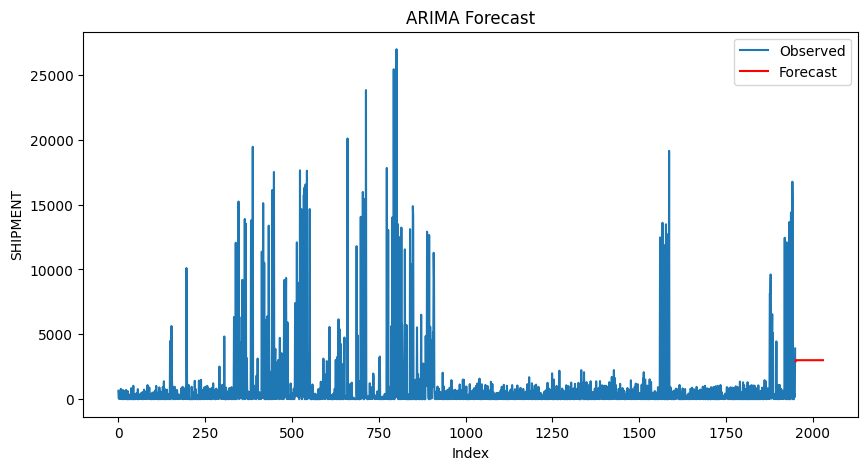

In [ ]:
# Plotting the results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
# Plot observed data
plt.plot(ts_['SHIPMENT'].index, ts_['SHIPMENT'], label='Observed')
# Plot forecasted data
plt.plot(forecast.index, forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast')
plt.xlabel('Index') # Assuming index is numerical, not date
plt.ylabel('SHIPMENT')
plt.legend()
plt.show()

##SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
sarimax= SARIMAX(endog=TS["y"],order=(1,0,0), seasonal_order=(0,0,0,12), simple_differencing= True, hamilton_representation= True)

In [ ]:
sarimax_model= sarimax.fit()
forecast_sarimax= sarimax_model.forecast(steps=30)
forecast_sarimax.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,predicted_mean
40,10345.121948
41,6659.710524
42,4287.213286
43,2759.909412
44,1776.701894


In [ ]:
#Confidence intervals of above forecasted model
sarimax_model.get_forecast(steps=len(TS)).conf_int(alpha=0.94).head()

,lower y,upper y
40,6989.429993,13700.813902
41,2668.808182,10650.612865
42,60.957014,8513.469557
43,-1560.125709,7079.944534
44,-2581.605591,6135.009379


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



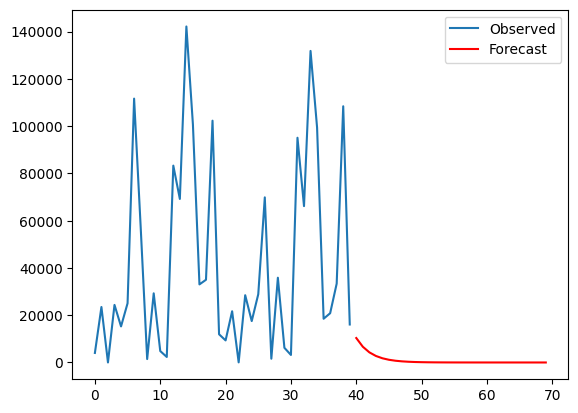

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
 TS["y"].plot(label="Observed")
 forecast_sarimax.plot(label="Forecast", color="red")
 plt.legend()
 plt.show()

## SARIMAX USING SKFORECAST

In [ ]:
pip install skforecast==0.13.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.5/670.5 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 30.0 MB/s eta 0:00:00


In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 32.2 MB/s eta 0:00:00


In [ ]:
from skforecast.Sarimax import Sarimax
from skforecast.ForecasterSarimax import ForecasterSarimax
from skforecast.model_selection_sarimax import backtesting_sarimax, grid_search_sarimax

In [ ]:
#X_train=X_train[~X_train.index.duplicated()]
#X_train
X_train.columns

Index(['cutoff', 'y'], dtype='object')

In [ ]:
#Setting index=cutoff and removing duplicate values
X_train= X_train.set_index("cutoff",drop= True)

In [ ]:
#Resetting index and removing duplicates by setting drop= True
X_train.index = pd.to_datetime(X_train.index,errors="coerce")
#X_train = X_train.set_index("cutoff",drop=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



#### Defining forecasterSarimax from Skforecast with variables to implement SARIMAX model

In [ ]:
forecast = ForecasterSarimax(transformer_exog= X_train.index,regressor=Sarimax(order=(2, 1, 1), seasonal_order=(2, 1, 1, 12)))
"""X_train_series= X_train['y']
#X_train_series= pd.Series(X_train)
forecast.fit(X_train_series, suppress_warnings=True)

# Prediction
predict = forecast.predict(steps=np.meshgrid(X_test))"""

"X_train_series= X_train['y']\n#X_train_series= pd.Series(X_train)\nforecast.fit(X_train_series, suppress_warnings=True)\n\n# Prediction\npredict = forecast.predict(steps=np.meshgrid(X_test))"

In [ ]:
#Fitting the data with mentioned model above
X_train["y"]= X_train["y"].fillna(0) #Imputation with 0
forecast.fit(y=X_train["y"])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for ARMA and tre

In [ ]:
#Removing the duplicate values from index and converting into a datetime format.
X_train = X_train[~X_train.index.duplicated(keep='first')]
X_train.index = pd.to_datetime(X_train.index,errors="coerce")

X_train= X_train.asfreq("30min") #here, set freq to 30 min, as cutoff has gap of 30 min
X_train["y"]= X_train["y"].fillna(0) #Imputation with 0

#Fit and prediction process using above model
forecast.fit(y=X_train["y"])
forecast.predict(steps= 12)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,pred
2025-03-19 13:30:00,759.284278
2025-03-19 14:00:00,15864.736901
2025-03-19 14:30:00,7132.362579
2025-03-19 15:00:00,15664.877584
2025-03-19 15:30:00,1152.418922
2025-03-19 16:00:00,15471.484598
2025-03-19 16:30:00,1343.584716
2025-03-19 17:00:00,15282.502042
2025-03-19 17:30:00,1530.422058
2025-03-19 18:00:00,15097.382320


#### Evaluating SARIMAX result using Backtesting, where Backtesting is use for evaluating the performance of the SARIMAX model

In [ ]:
#Forecaster sarimax with number of iterations defined
forecast= ForecasterSarimax(transformer_exog= X_train.index,regressor= Sarimax(order=(2,1,2), seasonal_order=(1,1,2,12), maxiter= 300, enforce_stationarity= False))

In [ ]:
#To identify missing values present in the Y_train dataset.
Y_train.info()

<class 'pandas.core.series.Series'>
Index: 8 entries, 5 to 6
Series name: SeasonalNaive
Non-Null Count  Dtype  
--------------  -----  
8 non-null      float64
dtypes: float64(1)
memory usage: 128.0 bytes


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
#Imputation of missing value with 0
Y_train= Y_train.fillna(0)

In [ ]:
cv_df.columns

Index(['ds', 'cutoff', 'y', 'HoltWinters', 'CrostonClassic', 'SeasonalNaive',
       'HistoricAverage', 'DynamicOptimizedTheta', 'hour', 'min', 'y_tot',
       'SeasonalNaive_tot'],
      dtype='object')

In [ ]:
cv_Df= cv_df[["y","SeasonalNaive"]]
#To flatten the above dataframe to make it possible
#to colnclude under y variable in grid search sarimax method
#cv_Df= pd.Series(cv_Df).flatten()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
#Metrics and backtesting description
TS_Series= pd.Series(TS["y"])
cv_df_Series= pd.Series(cv_df["y"])
#cv_df_Series= cv_df_Series.fillna(0)
X_test_Series= pd.Series(X_test["y"])
metric, predictions_backtest = backtesting_sarimax(
                               forecaster=forecast,
                               y=cv_df_Series,
                               initial_train_size=5,
                               fixed_train_size=False,
                               steps=12,
                               metric='mean_absolute_error',
                               refit=True,
                               n_jobs="auto",
                               suppress_warnings_fit=True,
                               verbose=True,
                               show_progress=True
                           )

print(f"Metric (mean absolute error): {metric}")

Information of backtesting process
----------------------------------
Number of observations used for initial training: 5
Number of observations used for backtesting: 7
    Number of folds: 1
    Number skipped folds: 0 
    Number of steps per fold: 12
    Number of steps to exclude from the end of each train set before test (gap): 0
    Last fold only includes 7 observations.

Fold: 0
    Training:   0 -- 4  (n=5)
    Validation: 5 -- 11  (n=7)



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



  0%|          | 0/1 [00:00<?, ?it/s]

Metric (mean absolute error):    mean_absolute_error
0         31494.428571


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



Here we got high MAE than previous ones that shows model is less likely to fit with the test data volatility, while considering steps= 12.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



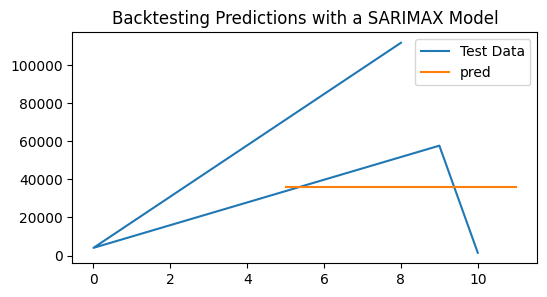

In [ ]:
# Backtesting Predictions on SARIMAX from skforecast
fig, ax = plt.subplots(figsize=(6, 3))
Y_test.plot(ax=ax, label='Test Data')
predictions_backtest.plot(ax=ax)
ax.set_title('Backtesting Predictions with a SARIMAX Model')
ax.legend()

As one can see from above, SARIMAX model is fail to capture seasonality as well as other factors.
Let's find the best hyperparameters for SARIMAX Model to best capture with the test data. For this:
1. One can go through with train-valid-test data to get more narrower view of data and further can know the optimal hyperparameters or patterns.
2. Here, I am using Grid Search for finding the most suitable hyperparameters from above model, as dataset is relatively small to implement above method.

In [ ]:
# Initialising Forecast for Grid Search
forecast = ForecasterSarimax(regressor=Sarimax(order=(1, 1, 1), maxiter=300, enforce_stationarity= False))

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22 entries, 2025-03-19 02:30:00 to 2025-03-19 13:00:00
Freq: 30min
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       22 non-null     float64
dtypes: float64(1)
memory usage: 352.0 bytes


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
# Describing different values or parameters for Grid search
parameter_grid = {
    'order': [(0, 1, 0), (0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1)],
    'seasonal_order': [(0, 0, 0, 0), (0, 1, 0, 12), (1, 1, 1, 12)],
    'trend': [None, 'n', 'c'],
    #"enforce_stationarity":False,
    #"initialization":"approximate_diffuse"
}


In [ ]:
cv_df.head(3)

,ds,cutoff,y,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,hour,min,y_tot,SeasonalNaive_tot
0,2025-03-19 03:00:00,2025-03-19 02:30:00,17524.0,4034.0,35714.083898,4034.0,39029.732212,39701.619435,3,0,17524.0,4034.0
1,2025-03-19 03:30:00,2025-03-19 02:30:00,28886.0,23475.0,35714.083898,23475.0,39029.732212,39701.619435,3,30,28886.0,23475.0
2,2025-03-19 09:30:00,2025-03-19 02:30:00,69877.0,7.0,35714.083898,7.0,39029.732212,39701.619435,9,30,69877.0,7.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
#cv_df_Series=cv_df_Series.astype("int")
cv_df_Series.dtypes
cv_df_Series= cv_df_Series.reset_index(drop= True)
cv_df_Series.index= pd.to_numeric(cv_df_Series.index, errors="coerce")
print(cv_df_Series.size)
#cv_df_Series.isna().any()

12


In [ ]:
cv_df_Series.head()
cv_df_Series= pd.DataFrame(cv_df_Series)
cv_df_Series.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       12 non-null     float64
dtypes: float64(1)
memory usage: 192.0 bytes


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



##GRID SEARCH IMPLEMENTATION

In [ ]:
for x in TS.columns:
  print(x)
TS["unique_id"]="Series1"
ts.shape
ts["unique_id"]="Series1"
for b in ts.columns:
  print(b)

unique_id
ds
y
S.R  NO.
Lane
DISPATCHED FROM
SHIFT
GATE PASS NO.
GATE IN DATE
GATE IN TIME
DOCK IN DATE
DOCK IN TIME
DOCK OUT DATE
DOCK OUT TIME
GATE OUT DATE
GATE OUT TIME
CUT OFF TIME
COC
CM
Bag Qty
(As Per ERP)
Large Shipment 
Bag(QTY)
IT & STOCK & EKL BAG
TOTAL BAGS
SHIPMENT
WT.
Trip ID
SPILL OVER BAG DETAIL
Vendor Name
Vehicle No
DOCK NO
Description
SIZE
KILO METER
Adhoc/Regular
DRIVER NAME
Contact No.
Seal No.
Prealert Status
VEHICLE LOAD BY
Report Created By
CUT OFF TIME_
log
unique_id


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
#1. Imputation using linear method of finding suitable parameters
'''cv_df_= TS.copy()
cv_df_= pd.DataFrame({"unique_id":ts["unique_id"], "ds": ts["CUT OFF TIME"], "y": ts["SHIPMENT"]})
#cv_df_= cv_df_.to_numpy().reshape(-1,1)
cv_df_= pd.DataFrame(cv_df_)
cv_df_linear= cv_df_.interpolate(method='linear', limit_direction='forward')
cv_df_linear[cv_df_linear.index.duplicated()]
cv_Df_linear= cv_df_linear.reset_index(drop=True)
cv_df_linear= cv_df_linear.asfreq("1min")
cv_df_linear.info()
ts["CUT OFF TIME"].head()'''

'cv_df_= TS.copy()\ncv_df_= pd.DataFrame({"unique_id":ts["unique_id"], "ds": ts["CUT OFF TIME"], "y": ts["SHIPMENT"]})\n#cv_df_= cv_df_.to_numpy().reshape(-1,1)\ncv_df_= pd.DataFrame(cv_df_)\ncv_df_linear= cv_df_.interpolate(method=\'linear\', limit_direction=\'forward\')\ncv_df_linear[cv_df_linear.index.duplicated()]\ncv_Df_linear= cv_df_linear.reset_index(drop=True)\ncv_df_linear= cv_df_linear.asfreq("1min")\ncv_df_linear.info()\nts["CUT OFF TIME"].head()'

In [ ]:
cv_df_raw = pd.DataFrame({
    "unique_id": ts["unique_id"],
    "date_part": ts["GATE IN DATE"],
    "time_part": ts["CUT OFF TIME_"] ,
    "y": ts["SHIPMENT"]
})
# Combine date and time parts into a single datetime column 'ds'
cv_df_raw["ds"] = pd.to_datetime(cv_df_raw["date_part"] + ' ' + cv_df_raw["time_part"], format='%d-%b-%Y %H:%M', errors="coerce")

# Drop rows where 'ds' could not be parsed (NaT) or 'y' is NaN initially
cv_df_raw = cv_df_raw.dropna(subset=['ds', 'y', 'unique_id'])

# Sort by unique_id and ds, then set ds as index
cv_df_raw = cv_df_raw.sort_values(by=['unique_id', 'ds'])

# If unique_id is constant, we can proceed with a single series.
# If there are multiple unique_ids, apply imputation and asfreq per group.
# For simplicity, assuming a single unique_id for now as implied by many subsequent steps.

# Create the final Series for linear interpolation
# We want 'y' to be the target for interpolation and 'ds' to be the index.
# First, ensure 'ds' is unique to avoid issues with asfreq. If there are duplicates, group and aggregate.
if cv_df_raw[['unique_id', 'ds']].duplicated().any():
    print("Warning: Duplicate 'ds' values found for 'unique_id'. Aggregating 'y' by 'ds' (sum).")
    cv_df_raw = cv_df_raw.groupby(['unique_id', 'ds'], as_index=False)['y'].sum()

# Set 'ds' as index for time series operations
cv_df_raw = cv_df_raw.set_index('ds')

# Resample to a 30-minute frequency. This might introduce NaNs for missing time steps.
# 'asfreq' fills missing datetime indices with NaNs for the value columns.
cv_df_linear_ = cv_df_raw.groupby('unique_id')['y'].resample('30min').mean()
cv_df_linear_ = cv_df_linear_.reset_index(level='unique_id', drop=True) # If we only need 'y' series

# Linearly interpolate missing values
cv_df_linear = cv_df_linear_.interpolate(method='linear', limit_direction='both')

print("Info of cv_df_linear after processing:")
cv_df_linear.info()
print("\nHead of cv_df_linear:")
cv_df_linear.head()

Info of cv_df_linear after processing:
<class 'pandas.core.series.Series'>
DatetimeIndex: 58 entries, 2025-03-18 09:30:00 to 2025-03-19 14:00:00
Freq: 30min
Series name: y
Non-Null Count  Dtype  
--------------  -----  
58 non-null     float64
dtypes: float64(1)
memory usage: 928.0 bytes

Head of cv_df_linear:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,y
ds,
2025-03-18 09:30:00,26618.0
2025-03-18 10:00:00,1448.0
2025-03-18 10:30:00,12475.0
2025-03-18 11:00:00,3967.0
2025-03-18 11:30:00,1150.0


In [ ]:
#cv_df_mean= pd.Series(cv_df_mean)
##Grid search on SARIMAX with above parameters defined
final_grid_result = grid_search_sarimax(
    forecaster=forecast,
    param_grid=parameter_grid,
    steps=24,
    metric='mean_absolute_error',
    y=cv_df_linear,
    initial_train_size=18,
    fixed_train_size=False,
    return_best=True,
    n_jobs='auto',
    suppress_warnings_fit=True,
    verbose=False,
    show_progress=True
)

Number of models compared: 45.


params grid:   0%|          | 0/45 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

`Forecaster` refitted using the best-found parameters, and the whole data set: 
  Parameters: {'order': (2, 1, 1), 'seasonal_order': (0, 0, 0, 0), 'trend': None}
  Backtesting metric: 5557.123034986284



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



`Forecaster` using SARIMAX Model refitted using the best-found parameters with the whole data set, where the best:
  1. order: (2, 1, 1)
  2. seasonal_order: (0, 0, 0, 0)
  3. trend: None
  4. Backtesting metric(mean absolute error): 5557.123034986284


In [ ]:
#Let's check the last rows of the above grid search model
final_grid_result.tail()

,params,mean_absolute_error,order,seasonal_order,trend
43,"{'order': (2, 1, 1), 'seasonal_order': (1, 1, ...",3.521390e+05,"(2, 1, 1)","(1, 1, 1, 12)",n
42,"{'order': (2, 1, 1), 'seasonal_order': (1, 1, ...",3.521390e+05,"(2, 1, 1)","(1, 1, 1, 12)",None
33,"{'order': (1, 1, 1), 'seasonal_order': (1, 1, ...",1.023232e+06,"(1, 1, 1)","(1, 1, 1, 12)",None
34,"{'order': (1, 1, 1), 'seasonal_order': (1, 1, ...",1.023232e+06,"(1, 1, 1)","(1, 1, 1, 12)",n
17,"{'order': (0, 1, 1), 'seasonal_order': (1, 1, ...",3.752839e+06,"(0, 1, 1)","(1, 1, 1, 12)",c


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
#Row with lowest mae for considering best parameters
#With above imputation technique
"""for i in final_grid_result["mae"]:
    best_parameters= final_grid_result["mae"].min
    best_parameters"""

'for i in final_grid_result["mae"]:\n    best_parameters= final_grid_result["mae"].min\n    best_parameters'

##2. Imputation with Mean value

In [ ]:
#2. Imputation with mean value
from sklearn.impute import SimpleImputer
imputer= SimpleImputer(strategy="mean")
cv_fill_mean = cv_df_linear_.fillna(cv_df_linear_.mean(numeric_only=True))
#cv_df_mean= imputer.fit_transform(cv_df_Series)
#cv_df_mean= pd.DataFrame(cv_df_mean)
#cv_df_mean= pd.Series(cv_df_mean)
#cv_df_mean= cv_df_mean.fillna(0)
cv_fill_mean= cv_fill_mean.asfreq("30min")
cv_fill_mean.isna().sum()

np.int64(0)

In [ ]:
print(type(cv_fill_mean))
print(len(cv_fill_mean))

<class 'pandas.core.series.Series'>
58


In [ ]:
#2. Executing Grid Search with values using mean

final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=24,
                    metric='mean_absolute_error',
                    y=cv_fill_mean,
                    initial_train_size=18,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

final_grid_result.head(5)

Number of models compared: 45.


params grid:   0%|          | 0/45 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

`Forecaster` refitted using the best-found parameters, and the whole data set: 
  Parameters: {'order': (0, 1, 0), 'seasonal_order': (0, 0, 0, 0), 'trend': None}
  Backtesting metric: 2336.625



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

,params,mean_absolute_error,order,seasonal_order,trend
0,"{'order': (0, 1, 0), 'seasonal_order': (0, 0, ...",2336.625000,"(0, 1, 0)","(0, 0, 0, 0)",None
1,"{'order': (0, 1, 0), 'seasonal_order': (0, 0, ...",2336.625000,"(0, 1, 0)","(0, 0, 0, 0)",n
18,"{'order': (1, 1, 0), 'seasonal_order': (0, 0, ...",2336.625000,"(1, 1, 0)","(0, 0, 0, 0)",None
19,"{'order': (1, 1, 0), 'seasonal_order': (0, 0, ...",2336.625000,"(1, 1, 0)","(0, 0, 0, 0)",n
10,"{'order': (0, 1, 1), 'seasonal_order': (0, 0, ...",2336.625526,"(0, 1, 1)","(0, 0, 0, 0)",n


`Forecaster` using SARIMAX refitted using the best-found parameters, and the whole data set with the best parameters:
1. order: (0, 1, 0)
2. seasonal_order: (0, 0, 0, 0)
3. trend: None
4. Backtesting metric(Mean_Absolute_Error): 2336.625

##3. Imputation with polynomial of order=2

In [ ]:
##3. imputation according to
#suitable degree from polynomial regression
cv_df_poly= cv_df_linear_.interpolate(method="polynomial", order= 2)
cv_df_poly = cv_df_poly.asfreq("30min")
cv_df_poly.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 58 entries, 2025-03-18 09:30:00 to 2025-03-19 14:00:00
Freq: 30min
Series name: y
Non-Null Count  Dtype  
--------------  -----  
58 non-null     float64
dtypes: float64(1)
memory usage: 3.0 KB


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
#3. Imputation with values from non-linear models-1
cv_df_poly = cv_df_poly.asfreq("30min")

final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=24,
                    metric='mean_absolute_error',
                    y=cv_df_poly,
                    initial_train_size=18,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

final_grid_result.head(5)

Number of models compared: 45.


params grid:   0%|          | 0/45 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

`Forecaster` refitted using the best-found parameters, and the whole data set: 
  Parameters: {'order': (1, 1, 1), 'seasonal_order': (0, 0, 0, 0), 'trend': None}
  Backtesting metric: 35314.73717185977



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

,params,mean_absolute_error,order,seasonal_order,trend
27,"{'order': (1, 1, 1), 'seasonal_order': (0, 0, ...",35314.737172,"(1, 1, 1)","(0, 0, 0, 0)",None
28,"{'order': (1, 1, 1), 'seasonal_order': (0, 0, ...",35314.737172,"(1, 1, 1)","(0, 0, 0, 0)",n
36,"{'order': (2, 1, 1), 'seasonal_order': (0, 0, ...",35369.137613,"(2, 1, 1)","(0, 0, 0, 0)",None
37,"{'order': (2, 1, 1), 'seasonal_order': (0, 0, ...",35369.137613,"(2, 1, 1)","(0, 0, 0, 0)",n
10,"{'order': (0, 1, 1), 'seasonal_order': (0, 0, ...",49319.035984,"(0, 1, 1)","(0, 0, 0, 0)",n


'Forecaster` using SARIMAX refitted using the best-found parameters, and the whole data set with best Parameters:
  1. order: (0, 1, 0)
  2. seasonal_order: (0, 0, 0, 0)
  3. trend: None
  4. Backtesting metric(mean absolute error): 198355.2749324948

One can also use elbow method to consider the best order of polynomial to get minimum metric (here mean absolute error) on above SARIMAX model with grid search

## 4. Imputation of missing value with 0

In [ ]:
#5. Imputation using 0
cv_df_zero = cv_df_linear_.replace(np.nan, 0).fillna(0)# Replacing nan with 0
cv_df_zero = cv_df_zero.asfreq("30min")
cv_df_zero

,y
ds,
2025-03-18 09:30:00,26618.0
2025-03-18 10:00:00,1448.0
2025-03-18 10:30:00,12475.0
2025-03-18 11:00:00,3967.0
2025-03-18 11:30:00,1150.0
2025-03-18 12:00:00,3442.0
2025-03-18 12:30:00,1987.0
2025-03-18 13:00:00,27708.0
2025-03-18 13:30:00,37054.0


In [ ]:
# Executing Grid Search with imputation using 0
#cv_df_mean= pd.Series(cv_df_mean.flatten())
#cv_df_Series= np.meshgrid(cv_df_Series)

cv_df_1= cv_df_linear.reset_index(drop= True) ##Resetting index to consider the imputation with 0
cv_df_zero= cv_df_1.replace(np.nan,0)
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=24,
                    metric='mean_absolute_error',
                    y=cv_df_zero,
                    initial_train_size=18, # Increased initial_train_size for better model fitting
                    fixed_train_size=False,
                    return_best=True,
)

Number of models compared: 45.


params grid:   0%|          | 0/45 [00:00<?, ?it/s]

Information of backtesting process
----------------------------------
Number of observations used for initial training: 18
Number of observations used for backtesting: 40
    Number of folds: 2
    Number skipped folds: 0 
    Number of steps per fold: 24
    Number of steps to exclude from the end of each train set before test (gap): 0
    Last fold only includes 16 observations.

Fold: 0
    Training:   0 -- 17  (n=18)
    Validation: 18 -- 41  (n=24)
Fold: 1
    Training:   No training in this fold
    Validation: 42 -- 57  (n=16)

Information of backtesting process
----------------------------------
Number of observations used for initial training: 18
Number of observations used for backtesting: 40
    Number of folds: 2
    Number skipped folds: 0 
    Number of steps per fold: 24
    Number of steps to exclude from the end of each train set before test (gap): 0
    Last fold only includes 16 observations.

Fold: 0
    Training:   0 -- 17  (n=18)
    Validation: 18 -- 41  (n=24)
F

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All

Information of backtesting process
----------------------------------
Number of observations used for initial training: 18
Number of observations used for backtesting: 40
    Number of folds: 2
    Number skipped folds: 0 
    Number of steps per fold: 24
    Number of steps to exclude from the end of each train set before test (gap): 0
    Last fold only includes 16 observations.

Fold: 0
    Training:   0 -- 17  (n=18)
    Validation: 18 -- 41  (n=24)
Fold: 1
    Training:   No training in this fold
    Validation: 42 -- 57  (n=16)

Information of backtesting process
----------------------------------
Number of observations used for initial training: 18
Number of observations used for backtesting: 40
    Number of folds: 2
    Number skipped folds: 0 
    Number of steps per fold: 24
    Number of steps to exclude from the end of each train set before test (gap): 0
    Last fold only includes 16 observations.

Fold: 0
    Training:   0 -- 17  (n=18)
    Validation: 18 -- 41  (n=24)
F

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



Information of backtesting process
----------------------------------
Number of observations used for initial training: 18
Number of observations used for backtesting: 40
    Number of folds: 2
    Number skipped folds: 0 
    Number of steps per fold: 24
    Number of steps to exclude from the end of each train set before test (gap): 0
    Last fold only includes 16 observations.

Fold: 0
    Training:   0 -- 17  (n=18)
    Validation: 18 -- 41  (n=24)
Fold: 1
    Training:   No training in this fold
    Validation: 42 -- 57  (n=16)

Information of backtesting process
----------------------------------
Number of observations used for initial training: 18
Number of observations used for backtesting: 40
    Number of folds: 2
    Number skipped folds: 0 
    Number of steps per fold: 24
    Number of steps to exclude from the end of each train set before test (gap): 0
    Last fold only includes 16 observations.

Fold: 0
    Training:   0 -- 17  (n=18)
    Validation: 18 -- 41  (n=24)
F

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/s

Information of backtesting process
----------------------------------
Number of observations used for initial training: 18
Number of observations used for backtesting: 40
    Number of folds: 2
    Number skipped folds: 0 
    Number of steps per fold: 24
    Number of steps to exclude from the end of each train set before test (gap): 0
    Last fold only includes 16 observations.

Fold: 0
    Training:   0 -- 17  (n=18)
    Validation: 18 -- 41  (n=24)
Fold: 1
    Training:   No training in this fold
    Validation: 42 -- 57  (n=16)

Information of backtesting process
----------------------------------
Number of observations used for initial training: 18
Number of observations used for backtesting: 40
    Number of folds: 2
    Number skipped folds: 0 
    Number of steps per fold: 24
    Number of steps to exclude from the end of each train set before test (gap): 0
    Last fold only includes 16 observations.

Fold: 0
    Training:   0 -- 17  (n=18)
    Validation: 18 -- 41  (n=24)
F

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent 

`Forecaster` refitted from SARIMAX model using the best-found parameters, and the whole data set with best parameters:
1. order: (2, 1, 1)
2. seasonal_order: (0, 0, 0, 0)
3. trend: None
4.  Backtesting metric(mean absolute error): 5557.123034986284

##5 Non-Imputation when dropping missing values

In [ ]:
cv_df_linear_.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 58 entries, 2025-03-18 09:30:00 to 2025-03-19 14:00:00
Freq: 30min
Series name: y
Non-Null Count  Dtype  
--------------  -----  
18 non-null     float64
dtypes: float64(1)
memory usage: 3.0 KB


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



With total 58 entries, here I got 40 rows with null values in series "y"

After dropping missing values, remaining 18 non-null values.

In [ ]:
##Dropping the rows where all the elements in series are missing.
cv_df_temp_= cv_df_linear_.reset_index()
cv_df_temp = cv_df_temp_.dropna(subset=["ds","y"])
#cv_df_temp= pd.Series(cv_df_temp)
# After dropna, the frequency might be lost. Re-establish the desired frequency
#cv_df_temp = cv_df_temp.asfreq('30min')
cv_df_temp= cv_df_temp.iloc[:]
cv_df_temp["ds"]= pd.to_datetime(cv_df_temp["ds"])
cv_df_temp= cv_df_temp.set_index("ds")
cv_df_temp
#cv_df_temp=pd.Series(cv_df_temp)

#cv_df_temp= cv_df_temp.ix[:,1]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,y
ds,
2025-03-18 09:30:00,26618.0
2025-03-18 10:00:00,1448.0
2025-03-18 10:30:00,12475.0
2025-03-18 11:00:00,3967.0
2025-03-18 11:30:00,1150.0
2025-03-18 12:00:00,3442.0
2025-03-18 12:30:00,1987.0
2025-03-18 13:00:00,27708.0
2025-03-18 13:30:00,37054.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



From above,
The missing values present after 14:00pm and before 09:00 am, shows that one was unable to get the value or observe the value after and before the above time, shows seasonality(if values also present in other dates) , else comes under cyclicity.

In [ ]:
#cv_df_temp_= cv_df_temp_.values.reshape(-1,1)

In [ ]:
#Converting "y" dataframe into series
#cv_df_temp["y"]= pd.Series(cv_df_temp["y"])
#Converting into datetime format
"""cv_df_temp.index = pd.to_datetime(cv_df_temp.index, format='%d-%b-%Y %H:%M', errors="coerce")

#setting frequency of 30minutes
#cv_df_temp.index = pd.date_range(start=cv_df_temp.index[0], end=cv_df_temp.index[-1], freq='D')
cv_df_temp= cv_df_temp.asfreq("30min")
cv_df_temp.tail(10)"""

'cv_df_temp.index = pd.to_datetime(cv_df_temp.index, format=\'%d-%b-%Y %H:%M\', errors="coerce")\n\n#setting frequency of 30minutes\n#cv_df_temp.index = pd.date_range(start=cv_df_temp.index[0], end=cv_df_temp.index[-1], freq=\'D\')\ncv_df_temp= cv_df_temp.asfreq("30min")\ncv_df_temp.tail(10)'

In [ ]:
cv_df_temp_= cv_df_temp.asfreq("30min")
cv_df_temp_= cv_df_temp_.fillna(0)
cv_df_temp_.head(10)

,y
ds,
2025-03-18 09:30:00,26618.0
2025-03-18 10:00:00,1448.0
2025-03-18 10:30:00,12475.0
2025-03-18 11:00:00,3967.0
2025-03-18 11:30:00,1150.0
2025-03-18 12:00:00,3442.0
2025-03-18 12:30:00,1987.0
2025-03-18 13:00:00,27708.0
2025-03-18 13:30:00,37054.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
#Replacing NaN values and converting "ds" or index into datetime feature
cv_df_temp = cv_df_temp[~np.isnan(cv_df_temp)]
cv_df_temp.index= pd.to_datetime(cv_df_temp.index, errors="coerce")
cv_df_temp["y"]= pd.Series(cv_df_temp["y"]) # Series from DataFrame

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
##Imputation while dropping missing values of y and respective rows
import warnings
warnings.filterwarnings("ignore")
#cv_df_temp= np.array(cv_df_temp)
#cv_df_temp = pd.DataFrame(cv_df_temp.flatten())
#cv_df_temp= cv_df_temp.reshape(18,1)
#cv_df_temp= pd.Series(cv_df_temp)
#cv_df_temp= cv_df_temp.reshape(18,1)
cv_df_temp.index= pd.to_datetime(cv_df_temp.index, errors="coerce")
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=5,
                    metric='mean_absolute_error',
                    y=cv_df_temp["y"],
                    initial_train_size=8,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=False,
                    verbose=False,
                    show_progress=True,
                    refit= True
)

final_grid_result.head(5)

Number of models compared: 45.


params grid:   0%|          | 0/45 [00:00<?, ?it/s]

TypeError: Expected index of type <class 'pandas.core.indexes.datetimes.DatetimeIndex'> for `last_window`. Got <class 'pandas.core.indexes.range.RangeIndex'>.

In [ ]:
#Executing Grid Search with imputation using polynomial regression
#cv_df_poly= pd.Series(cv_df_poly)
#cv_df_Series= np.meshgrid(cv_df_Series)
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=10,
                    metric='mean_absolute_error',
                    y=cv_df_poly,
                    initial_train_size=8,
                    fixed_train_size=False,
                    return_best=True,
)

##6. Imputation using Nearest Interpolation

In [ ]:
df_near= cv_df_linear.interpolate(method="nearest")
df_near.index.min()
df_near= df_near.asfreq("30min")
df_near.head()

,y
ds,
2025-03-18 09:30:00,26618.0
2025-03-18 10:00:00,1448.0
2025-03-18 10:30:00,12475.0
2025-03-18 11:00:00,3967.0
2025-03-18 11:30:00,1150.0


In [ ]:
# Executing Grid Search
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=24,
                    metric='mean_absolute_error',
                    y=df_near,
                    initial_train_size=18,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

final_grid_result.head(5)

Number of models compared: 45.


params grid:   0%|          | 0/45 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

`Forecaster` refitted using the best-found parameters, and the whole data set: 
  Parameters: {'order': (2, 1, 1), 'seasonal_order': (0, 0, 0, 0), 'trend': None}
  Backtesting metric: 5557.123034986284



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,params,mean_absolute_error,order,seasonal_order,trend
36,"{'order': (2, 1, 1), 'seasonal_order': (0, 0, ...",5557.123035,"(2, 1, 1)","(0, 0, 0, 0)",None
37,"{'order': (2, 1, 1), 'seasonal_order': (0, 0, ...",5557.123035,"(2, 1, 1)","(0, 0, 0, 0)",n
27,"{'order': (1, 1, 1), 'seasonal_order': (0, 0, ...",5558.796259,"(1, 1, 1)","(0, 0, 0, 0)",None
28,"{'order': (1, 1, 1), 'seasonal_order': (0, 0, ...",5558.796259,"(1, 1, 1)","(0, 0, 0, 0)",n
10,"{'order': (0, 1, 1), 'seasonal_order': (0, 0, ...",5560.446439,"(0, 1, 1)","(0, 0, 0, 0)",n


`Forecaster` using Nearest Imputation refitted using the best-found parameters, and the whole data set, and the best Parameters are :
  1. 'order': (2, 1, 1),
  2. 'seasonal_order': (0, 0, 0, 0),
  3. 'trend': None

  Backtesting metric(mean_absolute_error here): 5557.123034986284

##7. Imputation using Multiple Imputation

Multiple imputation is a robust statistical strategy that addresses uncertainty by generating multiple imputed datasets. Each is analyzed separately, and the final results are pooled to reflect the variability stemming from the imputation process.


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
cv_df_linear.head()

,y
ds,
2025-03-18 09:30:00,26618.0
2025-03-18 10:00:00,1448.0
2025-03-18 10:30:00,12475.0
2025-03-18 11:00:00,3967.0
2025-03-18 11:30:00,1150.0


In [ ]:
cv_Df_linear=pd.DataFrame(cv_df_linear.reset_index())
cv_Df_linear.head()
cv_Df_linear["ds_time"]= cv_Df_linear["ds"].dt.time
cv_Df_linear[["ds","ds_time"]]= cv_Df_linear[["ds","ds_time"]].astype("str")
cv_Df_linear.head()
cv_Df_linear= cv_Df_linear.drop("ds", axis= 1)
cv_Df_linear= cv_Df_linear.set_index("ds_time")
cv_Df_linear.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,y
ds_time,
09:30:00,26618.0
10:00:00,1448.0
10:30:00,12475.0
11:00:00,3967.0
11:30:00,1150.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
multiple = IterativeImputer(random_state=42, sample_posterior=True, max_iter=10)
#cv_Df_linear= pd.DataFrame(cv_df_linear)
cv_df_multiple = multiple.fit_transform(cv_Df_linear)
#df_imputed= df_imputed.asfreq("30min")
#cv_df_multiple= cv_df_multiple.reshape(58,1)
df_imputed = pd.DataFrame({"values": cv_df_multiple.ravel()})
#df_imputed= df_imputed.asfreq("30min")
df_imputed= df_imputed.values.reshape(58,1)
df_imputed= pd.DataFrame(df_imputed)
df_imputed["y"]= df_imputed[0]
df_imputed= df_imputed.drop(columns=[0])
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       58 non-null     float64
dtypes: float64(1)
memory usage: 596.0 bytes


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



The use of `sample_posterior=True` in the Iterative Imputer allows for incorporating randomness in the imputation process, which is a key step in creating multiple imputations. Running this multiple times and pooling the results can significantly boost the robustness of downstream analyses.

In [ ]:
# Executing Grid Search
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=24,
                    metric='mean_absolute_error',
                    y=df_imputed["y"],
                    initial_train_size=18,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

final_grid_result.head(5)

Number of models compared: 45.


params grid:   0%|          | 0/45 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

`Forecaster` refitted using the best-found parameters, and the whole data set: 
  Parameters: {'order': (2, 1, 1), 'seasonal_order': (0, 0, 0, 0), 'trend': None}
  Backtesting metric: 5557.123034986284



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

,params,mean_absolute_error,order,seasonal_order,trend
36,"{'order': (2, 1, 1), 'seasonal_order': (0, 0, ...",5557.123035,"(2, 1, 1)","(0, 0, 0, 0)",None
37,"{'order': (2, 1, 1), 'seasonal_order': (0, 0, ...",5557.123035,"(2, 1, 1)","(0, 0, 0, 0)",n
27,"{'order': (1, 1, 1), 'seasonal_order': (0, 0, ...",5558.796259,"(1, 1, 1)","(0, 0, 0, 0)",None
28,"{'order': (1, 1, 1), 'seasonal_order': (0, 0, ...",5558.796259,"(1, 1, 1)","(0, 0, 0, 0)",n
10,"{'order': (0, 1, 1), 'seasonal_order': (0, 0, ...",5560.446439,"(0, 1, 1)","(0, 0, 0, 0)",n


`Forecaster` using SARIMAX using multiple imputation refitted using the best-found parameters, and the whole data set, while best paramters:
1. order: (2, 1, 1)
2. seasonal_order: (0, 0, 0, 0)
3. trend: None

  Backtesting metric(using Mean Absolute Error here): 5557.123034986284

##. Imputation using non-linear models

In [ ]:
import scipy.stats as stats

In [ ]:
#4. Imputation with values from non-linear models

final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=10,
                    metric='mean_absolute_error',
                    y=cv_df_Series["y"],
                    initial_train_size=5,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

final_grid_result.head(5)

Number of models compared: 45.


params grid:   0%|          | 0/45 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



AttributeError: 'Index' object has no attribute 'step'

##Autoencoder for data generation

In [ ]:
cv_df2.head()

,y,HoltWinters,CrostonClassic,SeasonalNaive,HistoricAverage,DynamicOptimizedTheta,hour,min
0,17524.0,4034.0,35714.083898,4034.0,39029.732212,39701.619435,3,0
1,28886.0,23475.0,35714.083898,23475.0,39029.732212,39701.619435,3,30
2,69877.0,7.0,35714.083898,7.0,39029.732212,39701.619435,9,30
3,1597.0,24369.0,35714.083898,24369.0,39029.732212,39701.619435,10,0
4,35872.0,15262.0,35714.083898,15262.0,39029.732212,39701.619435,10,30


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
#Minmax scaling to make range varies between 0 and 1
from sklearn.preprocessing import MinMaxScaler
minsc= MinMaxScaler()
cv_df_min= minsc.fit_transform(cv_df2)
cv_df_min= pd.DataFrame(cv_df_min)
cv_df_min.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,0,1,2,3,4,5,6,7
0,0.149089,0.036065,0.0,0.036065,0.0,0.0,0.00,0.0
1,0.255446,0.210178,0.0,0.210178,0.0,0.0,0.00,1.0
2,0.639152,0.000000,0.0,0.000000,0.0,0.0,0.30,1.0
3,0.000000,0.218184,0.0,0.218184,0.0,0.0,0.35,0.0
4,0.320840,0.136623,0.0,0.136623,0.0,0.0,0.35,1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
X3= cv_df2.drop(columns=["SeasonalNaive"])
Y3= cv_df2["SeasonalNaive"]
from sklearn.model_selection import train_test_split
X3_train, X3_test, Y3_train, Y3_test= train_test_split(X3,Y3, test_size= 0.3, random_state= 42)
X3.columns

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



Index(['y', 'HoltWinters', 'CrostonClassic', 'HistoricAverage',
       'DynamicOptimizedTheta', 'hour', 'min'],
      dtype='object')

In [ ]:
print(X3_train, X3_test)
print(X3_train.info())

          y  HoltWinters  CrostonClassic  HistoricAverage  \
5    6203.0      25053.0    35714.083898     39029.732212   
2   69877.0          7.0    35714.083898     39029.732212   
1   28886.0      23475.0    35714.083898     39029.732212   
11  16070.0      29265.0    47402.557345     40969.781561   
4   35872.0      15262.0    35714.083898     39029.732212   
7   18505.0      25053.0    47402.557345     40969.781561   
3    1597.0      24369.0    35714.083898     39029.732212   
6   99417.0      15262.0    47402.557345     40969.781561   

    DynamicOptimizedTheta  hour  min  
5            39701.619435    11    0  
2            39701.619435     9   30  
1            39701.619435     3   30  
11           80193.247485    23    0  
4            39701.619435    10   30  
7            80193.247485    14    0  
3            39701.619435    10    0  
6            80193.247485    13   30              y  HoltWinters  CrostonClassic  HistoricAverage  \
10  108426.0       1448.0    47402.55

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
print(Y3_train, Y3_test)
print(Y3_train.info())

5     25053.0
2         7.0
1     23475.0
11    29265.0
4     15262.0
7     25053.0
3     24369.0
6     15262.0
Name: SeasonalNaive, dtype: float64 10      1448.0
9      57665.0
0       4034.0
8     111665.0
Name: SeasonalNaive, dtype: float64
<class 'pandas.core.series.Series'>
Index: 8 entries, 5 to 6
Series name: SeasonalNaive
Non-Null Count  Dtype  
--------------  -----  
8 non-null      float64
dtypes: float64(1)
memory usage: 128.0 bytes
None


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
X3_train = X3_train.values

In [ ]:
# Defining autoencoder model for prediction
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# input dimension
input_dim = 7

# encoder
input_layer = Input(shape=(input_dim,))

encoded = Dense(4, activation='relu')(input_layer)
latent = Dense(10, activation='relu')(encoded)

# decoder
decoded = Dense(4, activation='relu')(latent)
output_layer = Dense(input_dim, activation='linear')(decoded)

# autoencoder
autoencoder = Model(input_layer, output_layer)

# compile
autoencoder.compile(optimizer='adam', loss='mse')

# summary
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            44 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │            35 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 2. Compiling  on training data(X_train) and proceeding to training
autoencoder.compile(optimizer='adam', loss='mean_squared_error')
autoencoder.fit(
    X3_train, X3_train,
    epochs=34,
    batch_size=64,
)

Epoch 1/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step - loss: 1330400000.0000
Epoch 2/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1329654528.0000
Epoch 3/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1328900096.0000
Epoch 4/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1327958016.0000
Epoch 5/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1327011840.0000
Epoch 6/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1326077184.0000
Epoch 7/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1325156352.0000
Epoch 8/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1324332032.0000
Epoch 9/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1323678976.0000
Epoch 10/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1323084032.0000
Epoch 11/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1322570624.0000
Epoch 12/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1322062080.0000
Epoch 13/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1321556736.0000
Epoch 14/34
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/s

In [ ]:
#Prediction using autoencoder
pred= autoencoder.predict(X3_test)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



array([[ 2.50180997e-02,  1.12061724e-02,  4.23958451e-02,
         3.53725962e-02,  8.62621889e-02,  3.47721018e-02,
         1.21001415e-02],
       [ 2.50180997e-02,  1.12061724e-02,  4.23958451e-02,
         3.53725962e-02,  8.62621889e-02,  3.47721018e-02,
         1.21001415e-02],
       [-3.51483124e+02, -7.49683655e+02,  5.68648865e+02,
        -1.65970062e+02,  2.11140747e+03,  1.63896313e+03,
         2.34540674e+03],
       [ 1.19272964e+02,  1.00505658e+03,  1.05170544e+03,
        -1.08370972e+03, -3.69021790e+02, -4.32655365e+02,
         1.94346375e+03]], dtype=float32)

In [ ]:
#Evaluation using "mean_absolute_error"
from sklearn.metrics import mean_absolute_error
eval_auto= mean_absolute_error(X3_test, pred)
eval_auto

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



34978.4296875

The "mean_absolute error" using Autoencoder is 34513.183 that's less than using polynomial regression.

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np # Import numpy for random_latent_vec

# The latent dimension (from the autoencoder's latent layer which is 2).
# The `latent` variable in the kernel state is already 2, so we use it directly.
latent_dim = latent

# The latent dimension is 10, as established by the autoencoder's latent layer
latent_dim = 10

# Define the decoder model
# It takes the latent vector as input
decoder_input = Input(shape=(latent_dim,), name='decoder_input')

# Re-use the existing decoder layer structure from the autoencoder definition
# The original autoencoder's decoder had a Dense(4, activation='relu') followed by Dense(input_dim, activation='linear')
# We need to access the layers from the existing autoencoder model or redefine them with matching weights.
# For simplicity, we redefine layers with matching structure, assuming weights will be loaded if needed later.
# For now, we are just defining the architecture for the decoder.
decoder_layer1 = Dense(4, activation='relu', name='decoder_dense_1_reuse') # Renamed to avoid conflicts if autoencoder layers are still active
decoder_output_layer = Dense(input_dim, activation='linear', name='decoder_output_reuse') # Renamed

# Connect the layers to build the decoder model
x = decoder_layer1(decoder_input)
decoder_output = decoder_output_layer(x)
decoder_model = Model(decoder_input, decoder_output, name='decoder_model')

# Note: Data generation using decoder_model is now handled in cell fLXtHFiSNV


In [ ]:
import numpy as np
#New data generation from latent space using the decoder model
latent_dim = 10# The dimension of the latent space

# Generate random latent vectors
random_latent_vec = np.random.normal(size=(10, latent_dim))

# Use the decoder_model to transform latent vectors back into data space
# The decoder_model was defined in L93-xcxH2sWp to take latent vectors as input.
# autoencoder = Model(decoded, decoded) # This line was incorrect and has been removed.
generated_time_Df = decoder_model.predict(random_latent_vec)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [ ]:
generated_time_Df= pd.DataFrame(generated_time_Df)
generated_time_Df

,0,1,2,3,4,5,6
0,0.414525,0.308145,-0.128671,0.418088,-0.293332,0.126975,-0.105943
1,-0.175767,0.231984,0.280706,-0.252124,-0.192560,-0.174692,0.233618
2,-0.209608,1.715538,2.444884,-1.837832,-1.642253,-0.190743,0.748147
3,0.888188,0.390049,0.872662,-0.394981,-0.560742,0.901848,-0.670692
4,-0.074191,0.079922,0.094943,-0.084522,-0.069628,-0.083575,0.096917
5,0.185138,0.151010,0.229702,0.116770,-0.398867,-0.254145,0.084119
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,-0.004377,0.003329,0.017742,0.009769,-0.032658,-0.052743,0.026042
8,-1.182174,1.711273,2.109414,-1.857047,-1.443359,-1.173100,1.620540
9,1.306413,2.252327,2.472004,-0.956835,-2.426728,0.602360,-0.045754


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
generated_time_Df.columns = X3.columns
total_columns= pd.concat([generated_time_Df, X3], axis= 1)
total_columns


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



,y,HoltWinters,CrostonClassic,HistoricAverage,DynamicOptimizedTheta,hour,min,y,HoltWinters,CrostonClassic,HistoricAverage,DynamicOptimizedTheta,hour,min
0,0.414525,0.308145,-0.128671,0.418088,-0.293332,0.126975,-0.105943,17524.0,4034.0,35714.083898,39029.732212,39701.619435,3,0
1,-0.175767,0.231984,0.280706,-0.252124,-0.192560,-0.174692,0.233618,28886.0,23475.0,35714.083898,39029.732212,39701.619435,3,30
2,-0.209608,1.715538,2.444884,-1.837832,-1.642253,-0.190743,0.748147,69877.0,7.0,35714.083898,39029.732212,39701.619435,9,30
3,0.888188,0.390049,0.872662,-0.394981,-0.560742,0.901848,-0.670692,1597.0,24369.0,35714.083898,39029.732212,39701.619435,10,0
4,-0.074191,0.079922,0.094943,-0.084522,-0.069628,-0.083575,0.096917,35872.0,15262.0,35714.083898,39029.732212,39701.619435,10,30
5,0.185138,0.151010,0.229702,0.116770,-0.398867,-0.254145,0.084119,6203.0,25053.0,35714.083898,39029.732212,39701.619435,11,0
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99417.0,15262.0,47402.557345,40969.781561,80193.247485,13,30
7,-0.004377,0.003329,0.017742,0.009769,-0.032658,-0.052743,0.026042,18505.0,25053.0,47402.557345,40969.781561,80193.247485,14,0
8,-1.182174,1.711273,2.109414,-1.857047,-1.443359,-1.173100,1.620540,20844.0,111665.0,47402.557345,40969.781561,80193.247485,14,30
9,1.306413,2.252327,2.472004,-0.956835,-2.426728,0.602360,-0.045754,33376.0,57665.0,47402.557345,40969.781561,80193.247485,15,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



In [ ]:
#imputation according to
#suitable degree from polynomial regression
cv_df_poly= cv_df_Series.interpolate(method="polynomial", order= 5)
cv_df_poly = cv_df_poly.asfreq("30min")
cv_df_poly.info()

In [ ]:
# Executing Grid Search
final_grid_result = grid_search_sarimax(
                    forecaster=forecast,
                    param_grid=parameter_grid,
                    steps=10,
                    metric='mean_absolute_error',
                    y=cv_df_Series,
                    initial_train_size=5,
                    fixed_train_size=False,
                    return_best=True,
                    n_jobs='auto',
                    suppress_warnings_fit=True,
                    verbose=False,
                    show_progress=True
               )

## State Space models for smoothing, Filtering and Prediction process:
involves probabilistic model to proceed:
1. with smoothing process for historical analysis, report generation, or understanding what happened in the past.
2. with Filtering for online Anomaly Detection or trading.
3. with Prediction for predicting the future patterns using above methods.

In [ ]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

In [ ]:
#Defining components to include the dataframe for the above Modeling procedure.
# Generating data from a local level model
np.random.seed(42)
n = 58
sigma_eta = 0.5   # State noise (level changes)
sigma_eps = 2.0   # Observation noise

# True hidden level
true_level = np.zeros(n)
for t in range(1, n):
     true_level[t] = true_level[t-1] + np.random.normal(0, sigma_eta)

# Noisy observations
observations = true_level + np.random.normal(0, sigma_eps, n)

"""dates = pd.date_range(df_near.index, freq="30min")
df = pd.DataFrame({'y': observations}, index=dates)"""

# Fit local level model using statsmodels
local_level = UnobservedComponents(
    cv_df_poly,
    level='local level',# Random walk level,
)
result = local_level.fit(disp=False)
print(result.summary())

In [ ]:
"""cv_df_linear_= pd.DataFrame(cv_df_linear_)
cv_df_linear_= cv_df_linear_.rest_index()
cv_df_linear_.head()"""

In [ ]:
#cv_df_linear.columns
cv_df_poly= pd.DataFrame(cv_df_poly)
cv_df_poly= cv_df_poly.reset_index()
cv_df_poly.head()

In [ ]:
#Extracting only time from "ds" column
import datetime as dt
cv_df_poly["ds_time"]= cv_df_poly["ds"].dt.time
cv_df_poly["ds_time"]= cv_df_poly["ds_time"].astype("str")
cv_df_poly.head()

In [ ]:
# Linearly interpolate missing values
#cv_df_linear = cv_df_linear_.interpolate(method='linear', limit_direction='both')
cv_df_poly.head()

In [ ]:
#Reset index and then pass for visualisation
#cv_df_linear= pd.DataFrame(cv_df_linear)
#cv_df_linear = cv_df_linear.values.reshape((-1,1))
observations= observations.reshape((-1,1))
observations.shape

In [ ]:
##Reshaping while padding the axis where the data is unmatchable with another axis
#or truncating

In [ ]:
# Extract filtered and smoothed states
filtered_level = result.filtered_state[0]  # One-sided (causal)
smoothed_level = result.smoothed_state[0]  # Two-sided (uses all data)

# Plot comparison
plt.figure(figsize=(28, 14))
plt.plot(cv_df_poly["ds"], observations, '.', alpha=0.4, color='gray',
         label='Observations', markersize=4)
plt.plot(cv_df_poly["ds"], true_level, color='black', linewidth=3.5,
         label='True Level')
plt.plot(cv_df_poly["ds"], filtered_level, color='steelblue', linewidth=3.5,
         label='Kalman Filtered')
plt.plot(cv_df_poly["ds"], smoothed_level, color='coral', linewidth=3.5,
         label='Kalman Smoothed')
plt.legend()
plt.title('Local Level Model: Filtering vs Smoothing')
plt.tight_layout()
plt.savefig('kalman_filter.png', dpi=150)
plt.show()

In [ ]:
# Extract filtered and smoothed states for time related variable only

filtered_level = result.filtered_state[0]  # One-sided (causal)
smoothed_level = result.smoothed_state[0]  # Two-sided (uses all data)

# Plot comparison
plt.figure(figsize=(39, 14))
plt.plot(cv_df_poly["ds_time"], observations, '.', alpha=0.4, color='gray',
         label='Observations', markersize=4)
plt.plot(cv_df_poly["ds_time"], true_level, color='black', linewidth=3.5,
         label='True Level')
plt.plot(cv_df_poly["ds_time"], filtered_level, color='steelblue', linewidth=3.5,
         label='Kalman Filtered')
plt.plot(cv_df_poly["ds_time"], smoothed_level, color='coral', linewidth=3.5,
         label='Kalman Smoothed')
plt.legend()
plt.title('Local Level Model: Filtering vs Smoothing(including time only)')
plt.tight_layout()
plt.savefig('kalman_filter_time.png', dpi=150)
plt.show()

Above shows:

1. During Polynomial of order=2(current):

The Kalman Smoothed as well as filtered curves have almost difference to 0 or coinciding over each other, shows same result for analysis or reporting as well as for online anomaly detection or other factors.

2. During Linear interpolation(earlier):

while there are few locations or instances where both the smoothed and filtered parameters are close to each other or almost difference with 0.

Apart from this, Kalman Smoothed as well as filtered state space models show mostly linearity in nature, with little curves on the starting point and at the final point.

In [ ]:
# Signal-to-noise ratio
q_ratio = result.params[0] / result.params[1]  # sigma2_eta / sigma2_eps
print(f"\nSignal-to-noise ratio (q): {q_ratio:.4f}")
if q_ratio>=50.0:
  print("High q -> level changes rapidly (noisy state)")
else:
  print("Low q -> level is smooth (observations are noisy)")

The signal to noise ratio during polynomial imputation(0.03%) almost ideal, that is way more lesser than signal to noise ratio while linear interpolation(almost 22-23%), shows better method of maintaining signal to noise ratio for forecasting.

In [ ]:
# Forecasting using above model
forecast = result.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)
forecast_ci.head()

In [ ]:
#Plot showing above Forecasting result
plt.figure(figsize=(14, 6))
plt.plot(cv_df_poly["ds"], cv_df_poly['y'], color='steelblue',
         label='Observed')
plt.plot(forecast_mean.index, forecast_mean, color='coral',
         linewidth=2, label='Forecast')
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 alpha=0.3, color='coral')
plt.legend()
plt.title('Local Linear Trend: 12-Day Forecast')
plt.tight_layout()
plt.show()

Above Forecasting interprets:

 the forecasted result for steps to predict for future(or horizon) with 12, gives almost mean or median(constant in nature) as forecasted result while values obtained using confidence interval of 95% shows slightly higher curve as well as lower too.
  
  It is mainly due to presence of missing values  in the real dataset.

## Adding Seasonality and Regression Components

In [ ]:
# Full structural model: trend + seasonal + regression
np.random.seed(42)
n = 48  # 2 years of daily data
t = np.arange(n)

In [ ]:
# Defining components for having structural model
trend = 0.0001 * t + 0.05 * t**2
two_seasonal = 3 * np.sin(2 * np.pi * t / 2)
#yearly_seasonal = 10 * np.sin(2 * np.pi * t / 365.25)

#noise = np.random.normal(0, 2, n)
Total_noise = sigma_eta + sigma_eps


In [ ]:
##Defing Strctural model using above parameters
#y_structural = 100 + trend + weekly_seasonal + yearly_seasonal + noise
y_structural = 7 + trend + two_seasonal + Total_noise

In [ ]:
# Fitting structural time series model
freq=30
#cv_df_poly["y"]=pd.DataFrame(cv_df_poly['y'].values.reshape(1,-1))
structural_model = UnobservedComponents(
    cv_df_poly["y"],
    level='local linear trend',
    seasonal=2,             # for weekly seasonality
    #freq_seasonal= [{"period":2, "harmonics": int(0.625)}] #for period of 2 days and for freq of 30 min under harmonics
        #{'period': 365.25 for whole year
  )

In [ ]:
#Fitting while observing result using the defined variable
struct_model_result = structural_model.fit(
    disp=False,
    maxiter=120
)
print(struct_model_result.summary())

In [ ]:
# Signal-to-noise ratio
q_ratio = struct_model_result.params[0] / struct_model_result.params[1]  # sigma2_eta / sigma2_eps
print(f"\nSignal-to-noise ratio (q): {q_ratio:.4f}")
if q_ratio>=50.0:
  print("High q -> level changes rapidly (noisy state)")
else:
  print("Low q -> level is smooth (observations are noisy)")

Here, the signal-to-noise-ratio is bit higher than above state space model, i.e., local trend model.

In [ ]:
# Forecasting using above model
forecast_struct = struct_model_result.get_forecast(steps=12)
forecast_mean_struct= forecast_struct.predicted_mean
forecast_ci_struct = forecast_struct.conf_int(alpha=0.05)
forecast_ci_struct.head()

In [ ]:
cv_df_poly.head()

In [ ]:
#Plot showing above Forecasting result
plt.figure(figsize=(64, 14))
plt.plot(cv_df_poly["ds_time"], cv_df_poly['y'], color='steelblue',
         label='Observed')
plt.plot(forecast_mean_struct.index, forecast_mean_struct, color='coral',
         linewidth=2, label='Forecast')
plt.fill_between(forecast_ci_struct.index,
                 forecast_ci_struct.iloc[:, 0],
                 forecast_ci_struct.iloc[:, 1],
                 alpha=0.3, color='coral')
plt.legend()
plt.title('Forecasting using Structural Time Series Model: 12-Day Forecast')
plt.tight_layout()
plt.show()

With high AIC and BIC, and further visualization using structural model, shows the need to adapt with different parameters  to relate to observed behavior or values present in the dataset.

##Studying impact of Exogenous variables

In [ ]:
##Columns
for i in cv_df.columns:
  print(i)

In [ ]:
#Creating exogenous variables
var_exog= cv_df[["ds"]]
#Train_Test_Split
from sklearn.model_selection import train_test_split
x= cv_df["ds"]
y=cv_df["y"]
x_train,x_test,y_train, y_test= train_test_split(x,y,test_size=0.3,random_state= 42)

In [ ]:
import pandas as pd
# We combine these with a 'unique_id' to form the required DataFrame structure.
train_data_for_sf = pd.DataFrame({
    'unique_id': 'series_1', # Assuming a single time series
    'ds': x_train,
    'y': y_train
})

models4= [
    AutoARIMA(season_length= 28, alias="ARIMA_Exog")
]
sf= StatsForecast(models=models4, freq="30min")

# Fit the model using the correctly structured DataFrame
sf.fit(df=train_data_for_sf, id_col='unique_id', time_col='ds', target_col='y')

# For prediction, AutoARIMA from statsforecast usually doesn't take 'X_df' directly for exogenous variables
arim_preds= sf.predict(h=6)

In [ ]:
#Broader view of above prediction for ARIMA including exogenous
plot_series(
    df= TS_final,
    forecasts_df=arim_preds,
    palette="viridis",
    max_insample_length= 28
)

In [ ]:
#SARIMAX Model for Exogenous variables
"""models5= [
    SARIMAX(season_length= 28, alias="SARIMA_Exog")
]
sf= StatsForecast(models=models5, freq="30min")
sf.fit(df= train_data_for_sf)
sarimax_pred= sf.predict(h=6)"""

Including Exogenous variables in AutoARIMA model doesn't affect the shape of prediction that is average (here constant) in nature, signifies it fail to identify seasonality and other time related factors, can be understood through observing additive model of ETS.

###FEATURE ENGINEERING USING FREQUENCY-DOMAIN FEATURES.

In [ ]:
#Feature engineering on above dataset
from functools import partial
from utilsforecast.feature_engineering import fourier, time_features, pipeline

In [ ]:
#Feature generation using fourier transformation
features_gen= partial(fourier, season_length= 28, k=3)
#features= features_gen(df= TS_final, freq="30min")
first_exog_df, second_exog_df= pipeline(
    df= TS_final,
    features= [features_gen],
    freq="30min",
    h= 12
)

In [ ]:
##AutoARIMA after feature engineering using fourier transformation
##using frequency methods
from statsforecast.models import AutoARIMA
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='30min',
)
cross_val_exog_df= sf.cross_validation(
    h=4,
    df= first_exog_df,
    n_windows=3,
    step_size= 4,
    refit= True
)
cross_val_exog_df_evaluation= evaluate(cross_val_exog_df, metrics=[mae])
cross_val_exog_df_evaluation

##Evaluation after Cross validation on exogenous features

## Relevant features using tsfresh

In [ ]:
cv_df.columns

In [ ]:
from tsfresh import extract_features
cv_df["time"]= range(len(cv_df))
cv_df["HoltWinters"]= cv_df["HoltWinters"].fillna(cv_df["HoltWinters"].mean())
cv_df["SeasonalNaive"]= cv_df["SeasonalNaive"].fillna(cv_df["SeasonalNaive"].mean())

# Create a copy of cv_df and drop non-numerical columns before feature extraction
cv_df_numerical = cv_df.drop(columns=["ds", "cutoff"])

##Extracting features using extract_features
features_ext= extract_features(cv_df_numerical, column_id= "time")


In [ ]:
features_ext= pd.DataFrame(features_ext)
features_ext.head()

In [ ]:
#Extracting columns with non-null values from above feature extraction method
features_ext = features_ext.loc[:, (features_ext != 0).any(axis=0)] #Dropping all the columns containing 0
features_ext = features_ext.dropna(axis=1, how='all') #Dropping all the columns containing np.nan
features_ext = features_ext.loc[:, (features_ext != 1).any(axis=0)] #Dropping all the columns containing 1

#features_ext= features_ext.drop(columns=[["y__variance_larger_than_standard_deviation","y__has_duplicate_max","y__has_duplicate_min","y__has_duplicate"]])
features_ext.head()

##ENSEMBLE LEARNING- BOOSTING TECHNIQUE FOR TIME SERIES FORECASTING

In [ ]:
#from sklearn.ensemble import XGBRegressor
import xgboost as xgb

In [ ]:
xgb_reg= xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:linear',
                           max_depth=3,
                           learning_rate=0.01)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Define features (X_xgb) and target (Y_xgb) specifically for XGBoost.
# Using relevant numerical columns from cv_df. The 'SeasonalNaive' and 'HoltWinters'
# columns should already have NaNs filled from previous steps (cell 65t9QJhZYoCv).
# 'y_tot' was also created and filled.
features_for_xgb = [
    'y',
    'HoltWinters',
    'CrostonClassic',
    'HistoricAverage',
    'DynamicOptimizedTheta',
    'hour',
    'min',
    'y_tot'
]
X_xgb_original = cv_df[features_for_xgb]
Y_xgb_original = cv_df['SeasonalNaive']

# Ensure no NaNs remain in the features or target for XGBoost.
# While previous steps should have handled this, it's good practice to re-verify or fill if necessary.
X_xgb_original = X_xgb_original.fillna(X_xgb_original.mean())
Y_xgb_original = Y_xgb_original.fillna(Y_xgb_original.mean())

# Perform a fresh train-test split specifically for XGBoost to ensure size consistency.
X_train_xgb, X_test_xgb, Y_train_xgb, Y_test_xgb = train_test_split(
    X_xgb_original, Y_xgb_original, test_size=0.3, random_state=42
)

# Now, fit the XGBoost model with the newly split and aligned data
xgb_reg.fit(X_train_xgb, Y_train_xgb,
            eval_set=[(X_train_xgb, Y_train_xgb), (X_test_xgb, Y_test_xgb)],
            verbose=100)

## Prediction using XGB regressor
Y_xgbpred = xgb_reg.predict(X_test_xgb)

In [ ]:
# Mean squared error and Mean_absolute error between predicted and actual
#mse_xgbreg = mean_squared_error(Y_test, Y_xgbpred)
#print("mse_xgbreg", mse_xgbreg)
from sklearn.metrics import mean_absolute_error
mae_xgbreg= mean_absolute_error(Y_test, Y_xgbpred)
print("mae_xgbreg", mae_xgbreg)

Using XGBOOSTClassifier to get mean absolute error of 29263.92 on the real dataset.

##Neural Forecasting

In [ ]:
!pip install ray

In [ ]:
!pip install neuralforecast

In [ ]:
from ray import tune
from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNHITS, AutoLSTM
from neuralforecast.losses.pytorch import MQLoss

In [ ]:
config_nhits = {
    "input_size": tune.choice([2,3]),              # Length of input window
    "start_padding_enabled": True,
    "n_blocks": 3*[1],                                              # Length of input window
    "mlp_units": 2 * [[2, 2]],                                  # Length of input window
    "n_pool_kernel_size": tune.choice([3*[1], 3*[2], 3*[4],
                                      [ 2, 2, 1]]),            # MaxPooling Kernel size
    "n_freq_downsample": tune.choice([[5, 2, 1],
                                      [1, 1, 1]]),            # Interpolation expressivity ratios
    "learning_rate": tune.loguniform(1e-4, 1e-2),                   # Initial Learning rate
    "scaler_type": tune.choice([None]),                             # Scaler type
    "max_steps": tune.choice([180]),                               # Max number of training iterations
    "batch_size": tune.choice([1, 3, 5]),                          # Number of series in batch
    "windows_batch_size": tune.choice([2, 4, 5]),             # Number of windows in batch
    "random_seed": tune.randint(1, 6),                             # Random seed
}

config_lstm = {
    "input_size": tune.choice([2, 3]),                     # Length of input window
    "start_padding_enabled": True,
    "encoder_hidden_size": tune.choice([8, 16]),            # Hidden size of LSTM cells
    "encoder_n_layers": tune.choice([2,4]),                   # Number of layers in LSTM
    "learning_rate": tune.loguniform(1e-4, 1e-2),             # Initial Learning rate
    "scaler_type": tune.choice(['robust']),                   # Scaler type
    "max_steps": tune.choice([70, 180]),                    # Max number of training iterations
    "batch_size": tune.choice([1, 3]),                        # Number of series in batch
    "random_seed": tune.randint(1, 6),                       # Random seed
}

In [ ]:
#seeds=42
#np.random.seed=seeds #To make result reproducible or same every time
neural_model = NeuralForecast(
    models=[
        AutoNHITS(h=24, config=config_nhits, loss=MQLoss(), num_samples=4),
        AutoLSTM(h=24, config=config_lstm, loss=MQLoss(), num_samples=4),
    ],
    freq='30min'
)

In [ ]:
TS_interpolated = TS.copy()
TS_interpolated['y'] = TS_interpolated['y'].interpolate(method='linear')
neural_model.fit(df=TS_interpolated)

In [ ]:
##Prediction using above predicted model
forecast_neural_df = neural_model.predict()
#fcst_df.columns = fcst_df.columns.str.replace('-median', '')
#fcst_df.head()

In [ ]:
## Plotting TS and predicted Neural_df

forecast_neural_df_cleaned = forecast_neural_df.copy()
if 'AutoNHITS-median' in forecast_neural_df_cleaned.columns:
    forecast_neural_df_cleaned = forecast_neural_df_cleaned.rename(columns={'AutoNHITS-median': 'AutoNHITS'})
if 'AutoLSTM-median' in forecast_neural_df_cleaned.columns:
    forecast_neural_df_cleaned = forecast_neural_df_cleaned.rename(columns={'AutoLSTM-median': 'AutoLSTM'})

# The available prediction intervals are including, and between 80 to 90
StatsForecast.plot(
    TS_interpolated,
    forecast_neural_df_cleaned,
    engine='matplotlib',
    max_insample_length=10 * 10,
    level=[80, 90]
)

In [ ]:
# Plot using AutoLSTM with confidence level
StatsForecast.plot(TS_interpolated, forecast_neural_df_cleaned, models=["AutoLSTM"], level=[90], engine='matplotlib')

In [ ]:
# Plot using AutoNHITS with confidence level
StatsForecast.plot(TS, forecast_neural_df_cleaned, models=["AutoNHITS"], level=[80, 90], engine='matplotlib')

In [ ]:
##Cross validation on above prediction
cross_val_neural_df = neural_model.cross_validation(df=TS_interpolated, h=24, n_windows=2, filter_nan_and_inf= False)

In [ ]:
for ds in TS['ds'].unique():
    StatsForecast.plot(
        TS_interpolated,
        TS_interpolated.query('ds == @ds').drop(columns=['y', 'cutoff']),
        max_insample_length=5 * 3,
        engine='matplotlib'
    )

In [ ]:
##Evaluation on above cross validated model
from datasetsforecast.losses import mse, mae, rmse
from datasetsforecast.evaluation import accuracy
eval = accuracy(TS_interpolated, [mse, mae, rmse])
eval['best_model'] = eval.drop(columns=['metric', 'unique_id']).idxmin(axis=1)
eval.head()

In [ ]:
##Creating a summary dataframe
summ = eval.groupby(['metric', 'best_model']).size().sort_values().to_frame()
summ = summ.reset_index()
summ.columns = ['metric', 'model', 'nr. of unique_ids']
summ

In [ ]:
#Based on MSE, the summary dataframe:
summ.query('metric == "mse"')

In [ ]:
##Results by plotting the unique_id where a specific model wins.
autonhit_ids = eval.query('best_model == "AutoNHITS" and metric == "mse"')['unique_id'].unique()
StatsForecast.plot(TS_interpolated, forecast_neural_df, unique_ids=autonhits_ids, engine='matplotlib')

## ANOMALY DETECTION
1. Distance profile plot for identifying commom recurring subsequences(motifs) and unique subsequences(discords) that could show normal and anomolous behaviour.

In [ ]:
!pip install stumpy
import stumpy as st

In [ ]:
# Parameters
m = 3  # subsequence length
query_index = 1  # starting index of the query subsequence

# Extract the query subsequence
query = cv_df["y"][query_index:query_index + m]

In [ ]:
# Computing the distance profile
distance_profile = st.mass(query, cv_df["y"])
##stumpy.mass(query, time_series):
##Computes the distance profile between the query subsequence and every subsequence of length m in the time series.

# Plotting the time series and highlight the query
plt.figure(figsize=(12, 6))

axis= plt.subplot(2, 1, 1)
plt.plot(cv_df["y"], label="Time Series")
plt.axvspan(query_index, query_index + m, color='orange', alpha=0.5, label="Query Window", animated= True)
plt.title("Time Series with Query Highlighted")
plt.legend()
plt_slider= plt.axes([0.12, 1, 0.79,0.03])
#slider_def= Slider(plt_slider, "Smoothing factor", valmin=0.1, valmax=6, valimit=6, valstep=0.2 )

#### The orange shaded area shows the subsequence we are comparing against the rest of the series.


In [ ]:
# Plotting the distance profile
plt.subplot(2, 1, 2)
plt.plot(distance_profile, color='red', label="Distance Profile")
plt.title("Distance Profile")
plt.xlabel("Index")
plt.ylabel("Distance")
plt.legend()

plt.tight_layout()
plt.show()

Above Distance Profile Plot, where:
1. Peaks = dissimilar subsequences
2. Valleys = similar subsequences (motifs)

In [ ]:
mp = st.stump(cv_df["y"], m)  # mp is an array: [distance, index, left_idx, right_idx]
matrix_profile = mp[:, 0]
profile_index = mp[:, 1]

##Finding motif (lowest distance)
motif_idx = np.argmin(matrix_profile)
motif_pair_idx = profile_index[motif_idx]

##Find discord (highest distance)
discord_idx = np.argmax(matrix_profile)

## Visualising results
plt.figure(figsize=(12, 6))

# Original time series
plt.subplot(2, 1, 1)
plt.plot(cv_df["y"], label="Time Series")
plt.axvspan(motif_idx, motif_idx+m, color='green', alpha=0.3, label="Motif 1")
plt.axvspan(motif_pair_idx, motif_pair_idx+m, color='lime', alpha=0.3, label="Motif 2")
plt.axvspan(discord_idx, discord_idx+m, color='red', alpha=0.3, label="Discord")
plt.legend()
plt.title("Motif and Discord Detection")

Matrix Profile stores the distance between each subsequence and its nearest neighbor.

1. Motif = subsequences with the lowest distance
(most similar).
2. Discord = subsequence with the highest distance (most unusual).

In [ ]:
# Matrix profile
plt.subplot(2, 1, 2)
plt.plot(matrix_profile, label="Matrix Profile")
plt.axvline(motif_idx, color='green', linestyle='--', label="Motif")
plt.axvline(discord_idx, color='red', linestyle='--', label="Discord")
plt.legend()
plt.title("Matrix Profile")
plt.tight_layout()
plt.show()
mp = st.stump(cv_df["y"], m)  # mp is an array: [distance, index, left_idx, right_idx]
matrix_profile = mp[:, 0]
profile_index = mp[:, 1]

In [ ]:
!pip install adtk

In [ ]:
## shift anomaly detection algorithm
from adtk.data import validate_series
from adtk.detector import LevelShiftAD
# Create a pandas Series from the 'y' column of TS_final, using 'ds' as the datetime index
# Ensuring ts_ uses the longer TS_final (21 data points) as discussed in the context.
ts1 = pd.Series(TS_final['y'].values, index=TS_final['ds'])
ts_ = validate_series(ts1)
print(f"Length of time series (ts_) for ADTK: {len(ts_)}")

In [ ]:
# Initialize and fit the LevelShiftAD detector
# window: number of points in each sliding window
# c: sensitivity factor (smaller = more sensitive)
detector = LevelShiftAD(window=3, c=6.0)

In [ ]:
#Detect anomalies
anomalies = detector.fit_detect(ts_)

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(ts_, label="Time Series", color="blue")
# Filter anomalies to only include True values for plotting
anomalies_to_plot_indices = anomalies[anomalies == True].index
plt.scatter(ts_.loc[anomalies_to_plot_indices].index, ts_.loc[anomalies_to_plot_indices], color="red", label="Detected Shift", zorder=12)
plt.title("Level Shift Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

In [ ]:
#Print anomaly time
print("Detected shift anomaly times:")
print(anomalies[anomalies == True].index.tolist())

From above, there was 0 possibility of observing anomaly/anomalies in the form of shift detection.

In [ ]:
##Contextual anomaly detection algorithm

In [ ]:
##Drift anomaly detection algorithm


In [ ]:
##Stuck value anomaly detction algorithm

In [ ]:
##Findiings motifs and discords using 3d plot
from mpl_toolkits.mplot3d import Axes3D


In [ ]:
ts_= pd.DataFrame(ts_)

##ANOMALY DETECTION WITH LAPLACE DISTRIBUTION

In [ ]:
#Laplace ditribution considers heavier tails as representation
##hence can be used as a technique to find anomaly detection
import scipy
from scipy import stats

arr = cv_df.to_numpy(dtype=float) # Ensures numeric dtype


#Fitting Laplace distribution
location, scaling = stats.laplace.fit(arr)

# Calculate probabilities
probability = stats.laplace.pdf(arr, location, scaling)

# Identify anomalies (e.g., bottom 1% of probabilities)
threshold = np.percentile(probability, 1)
anomalies = arr[probability < threshold]

# Plot results
plt.figure(figsize=(12, 6))
plt.hist(arr, bins=50, density=True, alpha=0.7)
plt.plot(np.sort(arr), stats.laplace.pdf(np.sort(arr), location, scaling),
         'r-', lw=2, label='Fitted Laplace PDF')
plt.scatter(anomalies, [0]*len(anomalies), color='red', s=50, label='Anomalies')
plt.title('Anomaly Detection using Laplace Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

Above plot shows there is a presence of anomaly while the data is left skewed on the other half of "Value" at x-axis.

## TRANFORMER MODEL FOR LONG HORIZON PREDICTION

In [ ]:
!pip install neuralforecast datasetsforecast utilsforecast

In [ ]:
from datasetsforecast.long_horizon import LongHorizon

In [ ]:
##Splitting into validation and test set,
##With unique values of above dataframe in variable time2
time2 = len(cv_df.ds.unique())
valid = int(0.5 * time2)
test = int(0.5 * time2)

In [ ]:
from neuralforecast.core import NeuralForecast
from neuralforecast.models import Informer, Autoformer, FEDformer, PatchTST

In [ ]:
horizon = 3
models = [Informer(h=horizon,                 # Forecasting horizon
                input_size=2,           # Input size
                max_steps=3,               # Number of training iterations
                val_check_steps=3,
                start_padding_enabled=True,  # Compute validation loss every 12 steps
                early_stop_patience_steps=3), # Stop training if validation loss does not improve
          Autoformer(h=horizon,
                input_size=2,
                max_steps=3,
                val_check_steps=3,
                start_padding_enabled=True,  # Compute validation loss every 12 steps
                early_stop_patience_steps=3),
          PatchTST(h=horizon,
                input_size=2,
                max_steps=3,
                val_check_steps=3,
                start_padding_enabled=True,  # Compute validation loss every 12 steps
                early_stop_patience_steps=3),
         ]

In [ ]:
cv_df["ds"]= pd.to_numeric(cv_df["ds"],errors="coerce")
cv_df["cutoff"]= pd.to_numeric(cv_df["cutoff"],errors="coerce")
cv_df["unique_id"]="Series1"
cv_df.info()

In [ ]:
#Defining variable nf with NeuralForecast while covering above models
#and frequency of 30 min
nf = NeuralForecast(models=models,freq=30)
valid=24
test=48
#unique_id= cv_df["unique_id"] # This was incorrect, unique_id should be a string column name.

Y_hat_df = nf.cross_validation(df=cv_df,
                               val_size=valid,
                               test_size=test,
                               n_windows=None)

In [ ]:
##Evaluation:
cv_df_plot = cv_df[cv_df['unique_id']=='series1']
cutoffs = cv_df['cutoff'].unique()[::horizon]
cv_df_plot = cv_df_plot[cv_df['cutoff'].isin(cutoffs)]

plt.figure(figsize=(20,5))
plt.plot(cv_df_plot['ds'], cv_df_plot['y'], label='True')
plt.plot(cv_df_plot['ds'], cv_df_plot['Informer'], label='Informer')
plt.plot(cv_df_plot['ds'], cv_df_plot['Autoformer'], label='Autoformer')
plt.plot(cv_df_plot['ds'], cv_df_plot['PatchTST'], label='PatchTST')
plt.xlabel('Datestamp')
plt.ylabel('OT')
plt.grid()
plt.legend()

In [ ]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae

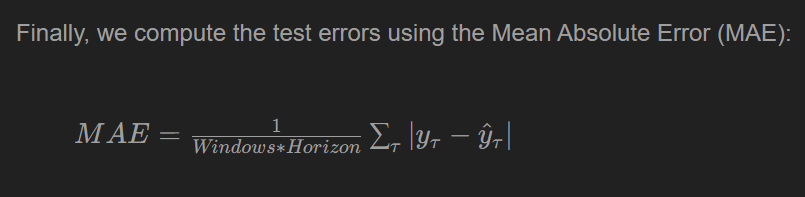

In [ ]:
#Evaluation using Mean Absolute Error
eval_df = evaluate(
    df=cv_df.drop(columns=["cutoff"]),
    metrics=[mae],
    agg_fn="mean"
)

print('Informer: ', eval_df.iloc[0]["Informer"])
print('Autoformer: ', eval_df.iloc[0]["Autoformer"])
print('PatchTST: ', eval_df.iloc[0]["PatchTST"])

## HYBRID FORECASTING MODEL

###Volatility CLustering and Garch+ARCH on variance prediction

## LLM for time series analysis and prediction